In [1]:
import pandas as pd
from pathlib import Path

# Load experiment 1 datasets
exp_dir = Path('../data/gold/experiment_1')
processes = [p for p in exp_dir.iterdir() if p.is_dir()]

results = []
for p in processes:

    print(p)
    dataset_dir = p / 'datasets'
    if not dataset_dir.exists():
        continue
    
    df_exp_path = dataset_dir / 'df_expanded.parquet'
    if not df_exp_path.exists():
        continue
        
    df = pd.read_parquet(df_exp_path)
    
    # Energy variables (contain 'energy' but NOT 'ef')
    energy_vars = [col for col in df.columns if 'to_model' in col.lower()]

    print(energy_vars)

    num_cols_energy = len(energy_vars) - 1

    
    
    # Number of cases
    case_col = 'case_id' if 'case_id' in df.columns else df.columns[0]
    num_cases = df[case_col].nunique() if case_col in df.columns else None
    
    # Number of activities
    activity_col = 'activity_log'
    num_activities = df[activity_col].nunique() if activity_col in df.columns else None

    # Max and min date, complete duration
    time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
    time_col = time_cols[0] if time_cols else None
    if 'timestamp' in df.columns:
        time_col = 'timestamp'
    elif 'time:timestamp' in df.columns:
        time_col = 'time:timestamp'
        
    if time_col:
        # Try converting to datetime if not already
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        min_date = df[time_col].min()
        max_date = df[time_col].max()
        complete_date = max_date - min_date
        # Convert timedelta to total hours (rounded to 2 decimal places for readability)
        hours = round(complete_date.total_seconds() / 3600, 2) if pd.notnull(complete_date) else None
    else:
        min_date, max_date, hours = None, None, None
        
    # Number of rows in expanded
    num_rows = len(df)
    
    results.append({
        'dataset': p.name,
        'number of cases': num_cases,
        'number of activities': num_activities,
        'number of time series': num_cols_energy,
        'hours': int(round(hours)) if hours is not None else None,
        #'observations': num_rows
    })

# Sort and display the DataFrame
df_info = pd.DataFrame(results).sort_values(by='dataset')
display(df_info)

# Output a single LaTeX table for all datasets
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Dataset Information Overview}")
print(df_info.to_latex(index=False).replace('_', '\\_'))
print("\\end{table}")


../data/gold/experiment_1/process_4_2
['(10)_abluft_temp_c_energy_to_model', 'f10_speise_den_kg/m3_energy_to_model', '(12)_mpt_fb(mpt?)_kg/h_energy_to_model', 'f11_speise_mas_kg/h_energy_to_model', 'f11_speise_vol_l/h_energy_to_model', '(6)_nach_recu_reg_temp_c_energy_to_model', 'dampf_nassmischbereich_energy_to_model', '(3)_zuluft_nach_entfeuchter_kon_g/kg_energy_to_model', 'f10_speise_vol_l/h_energy_to_model', '(9)_abluft_kon_g/kg_energy_to_model', '(16)_konditionierung_mas_kg/h_energy_to_model', '(14)_filter_mas_kg/h_energy_to_model', 'f10_speise_mas_kg/h_energy_to_model', '(5)_vor_vent_hauptzuluft_temp_c_energy_to_model', '(7)_zuluft_turm_temp_c_energy_to_model', '(2)_zuluft_vor_entfeuchter_kon_g/kg_energy_to_model', '(13)_lanzen_mas_kg/h_energy_to_model', '(8)_abluft_vol_m3/h_energy_to_model', '(17)_leistung_turmF_luftentfeuchter_kw_energy_to_model', '(8)_abluft_mas_kg/h_energy_to_model', '(21)_zuluft_turm_mas_kg/h_energy_to_model', '(33)_q_lufterwearmung_dampgemessen_und_berechne

,dataset,number of cases,number of activities,number of time series,hours
1,process_1,36978,22,6,1198
4,process_2,368493,12,4,512
5,process_3,368493,12,4,512
2,process_4_1,160,5,22,5082
0,process_4_2,156,5,22,4917
3,process_5,53,19,27,705


\begin{table}[h]
\centering
\caption{Dataset Information Overview}
\begin{tabular}{lrrrr}
\toprule
dataset & number of cases & number of activities & number of time series & hours \\
\midrule
process\_1 & 36978 & 22 & 6 & 1198 \\
process\_2 & 368493 & 12 & 4 & 512 \\
process\_3 & 368493 & 12 & 4 & 512 \\
process\_4\_1 & 160 & 5 & 22 & 5082 \\
process\_4\_2 & 156 & 5 & 22 & 4917 \\
process\_5 & 53 & 19 & 27 & 705 \\
\bottomrule
\end{tabular}

\end{table}


In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
# Set the experiment number to load (picks the latest run automatically)
EXPERIMENT = 935
# Which evaluation split to display: 'train' or 'test'
# Both live in the same row — train_* vs test_* column prefixes.
SPLIT = 'test'

In [3]:
import pandas as pd
from pathlib import Path

results_root = Path('..') / 'results'

# Find the latest run folder for the given experiment
prefix = f'experiment_{EXPERIMENT}_'
runs = sorted([d for d in results_root.iterdir() if d.is_dir() and d.name.startswith(prefix)])
assert runs, f'No runs found for experiment {EXPERIMENT}'
run_dir = runs[-1]
print(f'Loading: {run_dir.name}')

df = pd.read_parquet(run_dir / 'process_eval_results.parquet')
# The 'split' column marks the training set used (always 'TRAIN' or 'ALL DATA').
# Train vs test evaluation results are distinguished by column prefix: train_* vs test_*.
# Check the requested prefix exists.
split_prefix = SPLIT.lower() + '_'
available_prefixes = set()
for c in df.columns:
    for p in ('train_', 'test_'):
        if c.startswith(p):
            available_prefixes.add(p.rstrip('_'))
print(f'Available column prefixes: {sorted(available_prefixes)}')
assert split_prefix.rstrip('_') in available_prefixes, \
    f'No columns with prefix "{split_prefix}" found. Available: {sorted(available_prefixes)}'

print(f'Split prefix: {split_prefix} | {len(df)} rows | processes: {sorted(df["process"].unique())}')

Loading: experiment_929_20260715_173217
Available column prefixes: ['test', 'train']
Split prefix: test_ | 78 rows | processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']


In [4]:
# ── Mode display labels (mirrors modelling.py _display_mode) ─────────────────
def display_mode(m):
    m = str(m)
    if not m.startswith('petri_net_'):
        return m
    rest = m[len('petri_net_'):]
    if rest.endswith('_ml_plus_global'):
        return rest[:-len('_ml_plus_global')] + ' / ml_global'
    if rest.endswith('_ml_plus_per_act'):
        return rest[:-len('_ml_plus_per_act')] + ' / ml_local'
    return rest + ' / baseline'

df['mode_label'] = df['mode'].map(display_mode)

In [5]:
# ── Metrics for the results table ────────────────────────────────────────────
# activity_duration_mae:  MAE of per-activity mean durations in minutes
# activity_duration_wape: weighted abs % error of per-activity mean durations (0 = perfect)
# activity_duration_rmse: RMSE of per-activity mean durations in minutes
# edge_f1_score:          control-flow edge F1 on directly-follows graph (1 = perfect)
# fitness / precision:    conformance values via token replay (1 = perfect)

split_prefix = SPLIT.lower() + '_'

# Duration metrics: prefer MAE/WAPE/RMSE (new pipeline), fall back to MAPE for old parquets
_has_wape = (split_prefix + 'duration_metrics_activity_duration_wape') in df.columns

if _has_wape:
    _dur_cols = [
        split_prefix + 'duration_metrics_activity_duration_mae',
        split_prefix + 'duration_metrics_activity_duration_wape',
        split_prefix + 'duration_metrics_activity_duration_rmse',
    ]
    _dur_labels = {
        split_prefix + 'duration_metrics_activity_duration_mae':  r'\makecell{Duration\\MAE (min)}',
        split_prefix + 'duration_metrics_activity_duration_wape': r'\makecell{Duration\\WAPE}',
        split_prefix + 'duration_metrics_activity_duration_rmse': r'\makecell{Duration\\RMSE (min)}',
    }
else:
    _dur_cols = [split_prefix + 'duration_metrics_activity_duration_error']
    _dur_labels = {split_prefix + 'duration_metrics_activity_duration_error': r'\makecell{Duration\\MAPE}'}

METRIC_BASES_ORDERED = (
    _dur_cols
    + [
        split_prefix + 'control_flow_metrics_edge_f1_score',
        split_prefix + 'conformance_metrics_fitness',
        split_prefix + 'conformance_metrics_precision',
    ]
)
metric_cols = [c for c in METRIC_BASES_ORDERED if c in df.columns]

METRIC_LABELS = {
    **_dur_labels,
    split_prefix + 'control_flow_metrics_edge_f1_score': r'\makecell{Edge\\F1 Score}',
    split_prefix + 'conformance_metrics_fitness':        r'\makecell{Fitness}',
    split_prefix + 'conformance_metrics_precision':      r'\makecell{Precision}',
}

processes = sorted(df['process'].unique())
print(f'Duration cols: {_dur_cols}')
print(f'All metrics: {metric_cols}')
print(f'Processes: {processes}')
print(f'Modes: {df["mode_label"].unique().tolist()}')

Duration cols: ['test_duration_metrics_activity_duration_mae', 'test_duration_metrics_activity_duration_wape', 'test_duration_metrics_activity_duration_rmse']
All metrics: ['test_duration_metrics_activity_duration_mae', 'test_duration_metrics_activity_duration_wape', 'test_duration_metrics_activity_duration_rmse', 'test_control_flow_metrics_edge_f1_score', 'test_conformance_metrics_fitness', 'test_conformance_metrics_precision']
Processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']
Modes: ['alpha / baseline', 'heuristic / baseline', 'inductive / baseline', 'wip_aware / baseline', 'wip_branching_aware / baseline', 'alpha / ml_global', 'alpha / ml_local', 'heuristic / ml_global', 'heuristic / ml_local', 'inductive / ml_global', 'inductive / ml_local', 'wip_aware / ml_global', 'wip_aware / ml_local']


In [ ]:
# ── Build table: rows=(process, process model, duration pred), cols=metrics ───

ALGO_FAMILIES = ['heuristic', 'inductive', 'wip_aware', 'wip_branching_aware']

# Toggle: False (default) shows alpha + the single best-scoring petri-net algo
# per process (as picked by pick_best_algo below) -- the compact table used in
# the paper. True shows every process-model family side by side instead
# (heuristic, inductive, wip_aware, wip_branching_aware, alpha). Note the
# duplicate-rows caveat further down this notebook: wip_aware/wip_branching_aware
# rows are numerically identical to the heuristic/inductive rows whenever
# MINING_ALGORITHM matches, since wip_aware just reuses that miner's own net --
# don't read those as independent evidence.
SHOW_ALL_PROCESS_MODELS = True

def pick_best_algo(proc_df, split_prefix):
    """Best petri net algo among {heuristic, inductive, ilp} by combined metric score."""
    candidates = ['heuristic', 'inductive', 'ilp']
    base_modes = [f'petri_net_{a}' for a in candidates]
    sub = proc_df[proc_df['mode'].isin(base_modes)]
    if sub.empty:
        return candidates[0]
    _score_cols = [c for c in [
        split_prefix + 'conformance_metrics_fitness',
        split_prefix + 'conformance_metrics_precision',
        split_prefix + 'control_flow_metrics_edge_f1_score',
    ] if c in sub.columns]
    scores = pd.Series(0.0, index=sub.index)
    for c in _score_cols:
        scores = scores + sub[c].fillna(0)
    best_mode = sub.loc[scores.idxmax(), 'mode']
    return best_mode.replace('petri_net_', '')

def make_mode_label(mode, algo):
    pn = f"{algo.replace('_', ' ')} petri net"
    if mode == 'petri_net_alpha':
        return 'alpha petri net / baseline'
    if mode == f'petri_net_{algo}':
        return f'{pn} / baseline'
    if mode == f'petri_net_{algo}_ml_plus_global':
        return f'{pn} / ml_global'
    if mode == f'petri_net_{algo}_ml_plus_per_act':
        return f'{pn} / ml_local'
    return mode

def split_mode(label):
    if ' / ' in label:
        left, right = label.split(' / ', 1)
        return left.strip(), right.strip()
    return label, '—'

def _algo_for_mode(mode):
    """Inverse of make_mode_label's pattern match: which algo family a mode belongs to."""
    m = mode.replace('petri_net_', '')
    for algo in ALGO_FAMILIES:
        if m == algo or m.startswith(algo + '_ml_plus'):
            return algo
    return None

frames = []
for proc in processes:
    sub = df[df['process'] == proc].copy()
    best_algo = pick_best_algo(sub, split_prefix)
    print(f'{proc}: best_algo = {best_algo}')

    if SHOW_ALL_PROCESS_MODELS:
        modes_to_show = ['petri_net_alpha']
        for algo in ALGO_FAMILIES:
            modes_to_show += [f'petri_net_{algo}', f'petri_net_{algo}_ml_plus_global', f'petri_net_{algo}_ml_plus_per_act']
        sub = sub[sub['mode'].isin(modes_to_show)].copy()
        sub['mode_label'] = sub['mode'].apply(
            lambda m: make_mode_label(m, 'alpha' if m.startswith('petri_net_alpha') else _algo_for_mode(m))
        )
        row_order = []
        for algo in ALGO_FAMILIES:
            pn = f"{algo.replace('_', ' ')} petri net"
            row_order += [f'{pn} / ml_local', f'{pn} / ml_global', f'{pn} / baseline']
        row_order.append('alpha petri net / baseline')
    else:
        modes_to_show = [
            'petri_net_alpha',
            f'petri_net_{best_algo}',
            f'petri_net_{best_algo}_ml_plus_global',
            f'petri_net_{best_algo}_ml_plus_per_act',
        ]
        sub = sub[sub['mode'].isin(modes_to_show)].copy()
        sub['mode_label'] = sub['mode'].apply(lambda m: make_mode_label(m, best_algo))
        pn = f'{best_algo} petri net'
        row_order = [f'{pn} / ml_local', f'{pn} / ml_global', f'{pn} / baseline', 'alpha petri net / baseline']

    sub = sub.set_index('mode_label')[metric_cols]
    sub = sub.reindex([r for r in row_order if r in sub.index])
    sub.columns = [METRIC_LABELS.get(c, c) for c in sub.columns]
    pmodel, dpred = zip(*[split_mode(m) for m in sub.index])
    sub.index = pd.MultiIndex.from_arrays(
        [[proc] * len(sub), list(pmodel), list(dpred)],
        names=['Process', 'Process Model', 'Duration Pred.']
    )
    frames.append(sub)

table = pd.concat(frames)
table


In [7]:
# ── LaTeX output ──────────────────────────────────────────────────────────────
# Requires \usepackage{makecell}, \usepackage{booktabs}, \usepackage{multirow} in preamble.
import re

def _is_higher_better(col_label):
    return any(kw in col_label for kw in ['F1 Score', 'Fitness', 'Precision'])

# ── Bold best value per metric per process ────────────────────────────────────
str_table = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)
for proc in processes:
    proc_mask = table.index.get_level_values('Process') == proc
    proc_rows = table[proc_mask]
    for col in table.columns:
        vals = proc_rows[col].dropna()
        if vals.empty:
            for idx in proc_rows.index:
                str_table.loc[idx, col] = ''
            continue
        best_val = vals.max() if _is_higher_better(col) else vals.min()
        for idx in proc_rows.index:
            val = table.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

# ── Column format: vertical lines between metrics ─────────────────────────────
n_metrics = len(table.columns)
col_format = 'lll|' + '|'.join(['c'] * n_metrics)

# ── Generate LaTeX ─────────────────────────────────────────────────────────────
latex = str_table.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    escape=False,
    column_format=col_format,
    caption=(
        f'Results for experiment {EXPERIMENT} ({SPLIT} evaluation). '
        r'Rows: alpha = alpha miner (baseline); best petri net = best of heuristic/inductive per process. '
        r'Activity JS Div.\ and Duration WAPE/MAE/RMSE: lower is better. '
        r'Edge F1 Score, Fitness, Precision: higher is better (1 = best). '
        r'\textbf{Bold} = best value per process per metric.'
    ),
    label=f'tab:exp{EXPERIMENT}_{SPLIT}',
    position='H',
)

# Remove \cline lines (generated by pandas for MultiIndex, replaced by \midrule below)
latex = re.sub(r'\s*\\cline\{[^}]+\}', '', latex)

# Insert \midrule between process groups (detect first row of each group via \multirow + process_)
latex_lines = latex.split('\n')
new_lines = []
proc_count = 0
for line in latex_lines:
    if re.search(r'\\multirow.*\{process_', line):
        if proc_count > 0:
            new_lines.append(r'\midrule')
        proc_count += 1
    new_lines.append(line)
latex = '\n'.join(new_lines)

print(latex.replace('_', r'\_'))

\begin{table}[H]
\caption{Results for experiment 929 (test evaluation). Rows: alpha = alpha miner (baseline); best petri net = best of heuristic/inductive per process. Activity JS Div.\ and Duration WAPE/MAE/RMSE: lower is better. Edge F1 Score, Fitness, Precision: higher is better (1 = best). \textbf{Bold} = best value per process per metric.}
\label{tab:exp929\_test}
\begin{tabular}{lll|c|c|c|c|c|c}
\toprule
 &  &  & \makecell{Duration\\MAE (min)} & \makecell{Duration\\WAPE} & \makecell{Duration\\RMSE (min)} & \makecell{Edge\\F1 Score} & \makecell{Fitness} & \makecell{Precision} \\
Process & Process Model & Duration Pred. &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{process\_1} & \multirow[t]{3}{*}{heuristic petri net} & ml\_local & \textbf{0.316} & \textbf{5.644} & \textbf{0.709} & \textbf{0.667} & \textbf{0.997} & 0.994 \\
 &  & ml\_global & 0.736 & 14.036 & 1.785 & \textbf{0.667} & \textbf{0.997} & 0.994 \\
 &  & baseline & 1.199 & 24.144 & 2.811 & \textbf{0.667} & \textbf{0.9

# Evaluation energy

In [8]:
df_energy_results = pd.read_parquet(run_dir / 'summary_by_approach.parquet')

df_energy_results = df_energy_results[['Approach', 'MAE_TEST', 'RMSE_TEST', 'WAPE_TEST']]

df_energy_results

,Approach,MAE_TEST,RMSE_TEST,WAPE_TEST
0,Baseline,46.9278,52.3458,14.9494
1,DTW + Ext. Factors + Prev Act,23.3633,28.0229,6.6993
2,DTW + Ext. Factors + Prev Act (autoreg),12.0136,13.9349,9.7506
3,DTW + Seq2Seq,33.5489,40.6491,12.2758
4,DTW + Seq2Seq + Ext. Factors + Prev Act,32.5332,39.8695,9.0107
5,DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg),10.9413,11.7588,10.8197
6,DTW + pos,26.5544,32.2732,10.6105
7,ML DTW + Linear Decode,33.6790,41.6115,11.8559
8,ML Linear (no DTW),33.9701,42.4585,11.6654
9,Seq2Seq DTW + Linear Decode,41.7471,47.3830,13.4422


In [9]:
import pandas as pd

# Load data
df_energy_results = pd.read_parquet(run_dir / "summary_train_test.parquet")

# Group by Process and Approach, then take median of the selected metrics
df_grouped = (
    df_energy_results
    .groupby(["Process", "Approach"])[["MAE_TEST", "RMSE_TEST", "WAPE_TEST"]]
    .median()
    .reset_index()
)

df_grouped

,Process,Approach,MAE_TEST,RMSE_TEST,WAPE_TEST
0,process_1,Baseline,0.52230,0.52230,39.55180
1,process_1,DTW + Ext. Factors + Prev Act,0.00000,0.00000,8.37040
2,process_1,DTW + Ext. Factors + Prev Act (autoreg),0.00000,0.00000,9.02255
3,process_1,DTW + Seq2Seq,0.00360,0.00400,7.81145
4,process_1,DTW + Seq2Seq + Ext. Factors + Prev Act,0.00000,0.00000,7.49955
...,...,...,...,...,...
61,process_5,DTW + pos,2.85390,2.85420,11.67270
62,process_5,ML DTW + Linear Decode,2.87790,2.88685,12.72230
63,process_5,ML Linear (no DTW),2.75275,2.79590,12.96255
64,process_5,Seq2Seq DTW + Linear Decode,3.26595,3.42865,13.47320


In [10]:
import pandas as pd
import re

# Load data
df_energy_results = pd.read_parquet(run_dir / "summary_train_test.parquet")

# Group by Process and Approach, then take median
table = (
    df_energy_results
    .groupby(["Process", "Approach"])[["MAE_TEST", "RMSE_TEST", "WAPE_TEST"]]
    .median()
    .sort_index()
)

processes = table.index.get_level_values("Process").unique()

# Lower is better for all these metrics
def _is_higher_better(col_label):
    return False

# ── Bold best value per metric per process ────────────────────────────────────
str_table = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)

for proc in processes:
    proc_mask = table.index.get_level_values("Process") == proc
    proc_rows = table[proc_mask]
    
    for col in table.columns:
        vals = proc_rows[col].dropna()
        if vals.empty:
            for idx in proc_rows.index:
                str_table.loc[idx, col] = ""
            continue
        
        best_val = vals.max() if _is_higher_better(col) else vals.min()
        
        for idx in proc_rows.index:
            val = table.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ""
                continue
            
            fmt = f"{val:.3f}"
            str_table.loc[idx, col] = (
                r"\textbf{" + fmt + r"}"
                if abs(val - best_val) < 1e-6
                else fmt
            )

# ── Column format ─────────────────────────────────────────────────────────────
n_metrics = len(table.columns)
col_format = "ll|" + "|".join(["c"] * n_metrics)

# ── Generate LaTeX ────────────────────────────────────────────────────────────
latex = str_table.to_latex(
    multicolumn=True,
    multicolumn_format="c",
    multirow=True,
    escape=False,
    column_format=col_format,
    caption=(
        r"Median test results grouped by Process and Approach. "
        r"Metrics shown: MAE\_TEST, RMSE\_TEST, and WAPE\_TEST. "
        r"Lower values are better. "
        r"\textbf{Bold} indicates the best value per process and metric."
    ),
    label="tab:energy_results_median",
    position="H",
)

# Remove \cline lines
latex = re.sub(r"\s*\\cline\{[^}]+\}", "", latex)

# Insert \midrule between process groups
latex_lines = latex.split("\n")
new_lines = []
proc_count = 0

for line in latex_lines:
    if re.search(r"\\multirow", line):
        if proc_count > 0:
            new_lines.append(r"\midrule")
        proc_count += 1
    new_lines.append(line)

latex = "\n".join(new_lines)

print(latex.replace("_", r"\_"))

\begin{table}[H]
\caption{Median test results grouped by Process and Approach. Metrics shown: MAE\\_TEST, RMSE\\_TEST, and WAPE\\_TEST. Lower values are better. \textbf{Bold} indicates the best value per process and metric.}
\label{tab:energy\_results\_median}
\begin{tabular}{ll|c|c|c}
\toprule
 &  & MAE\_TEST & RMSE\_TEST & WAPE\_TEST \\
Process & Approach &  &  &  \\
\midrule
\multirow[t]{11}{*}{process\_1} & Baseline & 0.522 & 0.522 & 39.552 \\
 & DTW + Ext. Factors + Prev Act & \textbf{0.000} & \textbf{0.000} & 8.370 \\
 & DTW + Ext. Factors + Prev Act (autoreg) & \textbf{0.000} & \textbf{0.000} & 9.023 \\
 & DTW + Seq2Seq & 0.004 & 0.004 & 7.811 \\
 & DTW + Seq2Seq + Ext. Factors + Prev Act & \textbf{0.000} & \textbf{0.000} & 7.500 \\
 & DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg) & \textbf{0.000} & \textbf{0.000} & 7.974 \\
 & DTW + pos & \textbf{0.000} & \textbf{0.000} & \textbf{7.273} \\
 & ML DTW + Linear Decode & \textbf{0.000} & \textbf{0.000} & 10.692 \\
 & ML Linear 

In [11]:
# -- Same as above, but aggregated across ALL processes (one row per Approach) --
# Flat median: every (process, sensor) result pooled together and weighted
# equally, regardless of which process it came from (so a process with more
# sensors contributes more rows to the median -- that's fine here since we
# only care about overall approach performance, not per-process fairness).
# Uses sMAE/sRMSE (scale-normalized, comparable across sensors) instead of
# raw MAE/RMSE -- pooling raw MAE/RMSE across sensors with different units
# has the same problem as pooling raw totals did earlier.
APPROACH_LABELS = {
    'DTW + Ext. Factors + Prev Act': 'DTW + ML + Ext. Factors',
    'DTW + Ext. Factors + Prev Act (autoreg)': 'DTW + ML + Ext. Factors (autoreg)',
    'DTW + pos': 'DTW + ML',
    'DTW + Seq2Seq': 'DTW + Seq2Seq',
    'Seq2Seq only (no DTW)': 'Seq2Seq (no DTW)',
    'DTW + Seq2Seq + Ext. Factors + Prev Act': 'DTW + Seq2Seq + Ext. Factors',
    'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)': 'DTW + Seq2Seq + Ext. Factors (autoreg)',
}

# Drop the linear-decode ablation variants (both ML and Seq2Seq) -- not needed
EXCLUDE_APPROACHES = ['ML DTW + Linear Decode', 'Seq2Seq DTW + Linear Decode']

table_agg = (
    df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)]
    .groupby('Approach')[['sMAE_TEST', 'sRMSE_TEST', 'WAPE_TEST']]
    .median()
    .rename(index=APPROACH_LABELS)
    .rename(columns={'sMAE_TEST': 'sMAE', 'sRMSE_TEST': 'sRMSE', 'WAPE_TEST': 'WAPE'})
    .sort_values('sMAE')  # best-to-worst by sMAE (lower = better)
)

str_table_agg = pd.DataFrame(index=table_agg.index, columns=table_agg.columns, dtype=object)
for col in table_agg.columns:
    vals = table_agg[col].dropna()
    if vals.empty:
        str_table_agg[col] = ''
        continue
    best_val = vals.min()  # lower is better for sMAE/sRMSE/WAPE
    for idx in table_agg.index:
        val = table_agg.loc[idx, col]
        if pd.isna(val):
            str_table_agg.loc[idx, col] = ''
            continue
        fmt = f'{val:.3f}'
        str_table_agg.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

n_metrics_agg = len(table_agg.columns)
col_format_agg = 'l|' + '|'.join(['c'] * n_metrics_agg)
latex_agg = str_table_agg.to_latex(
    escape=False, column_format=col_format_agg,
    caption=(
        r'Median test results per Approach, aggregated across ALL processes '
        r'(every process/sensor result pooled and weighted equally). '
        r'Metrics shown: sMAE, sRMSE, and WAPE. '
        r'Lower values are better. Rows sorted best-to-worst by sMAE. '
        r'\textbf{Bold} indicates the best value per metric.'
    ),
    label='tab:energy_results_median_overall',
    position='H',
)
print(latex_agg.replace('_', r'\_'))
display(table_agg.round(3))

\begin{table}[H]
\caption{Median test results per Approach, aggregated across ALL processes (every process/sensor result pooled and weighted equally). Metrics shown: sMAE, sRMSE, and WAPE. Lower values are better. Rows sorted best-to-worst by sMAE. \textbf{Bold} indicates the best value per metric.}
\label{tab:energy\_results\_median\_overall}
\begin{tabular}{l|c|c|c}
\toprule
 & sMAE & sRMSE & WAPE \\
Approach &  &  &  \\
\midrule
DTW + ML + Ext. Factors & \textbf{1.240} & \textbf{1.504} & \textbf{9.410} \\
DTW + Seq2Seq + Ext. Factors & 1.768 & 2.021 & 12.901 \\
DTW + ML & 2.026 & 2.305 & 16.259 \\
Baseline & 2.196 & 2.374 & 22.141 \\
ML Linear (no DTW) & 2.225 & 2.454 & 17.956 \\
DTW + Seq2Seq & 2.251 & 2.421 & 17.875 \\
Seq2Seq (no DTW) & 2.292 & 2.524 & 16.912 \\
DTW + ML + Ext. Factors (autoreg) & 4.162 & 4.338 & 13.700 \\
DTW + Seq2Seq + Ext. Factors (autoreg) & 4.812 & 5.094 & 14.228 \\
\bottomrule
\end{tabular}
\end{table}



,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.240,1.504,9.410
DTW + Seq2Seq + Ext. Factors,1.768,2.021,12.901
DTW + ML,2.026,2.306,16.259
Baseline,2.196,2.374,22.141
ML Linear (no DTW),2.225,2.454,17.956
DTW + Seq2Seq,2.251,2.421,17.875
Seq2Seq (no DTW),2.292,2.524,16.912
DTW + ML + Ext. Factors (autoreg),4.162,4.338,13.700
DTW + Seq2Seq + Ext. Factors (autoreg),4.812,5.094,14.228


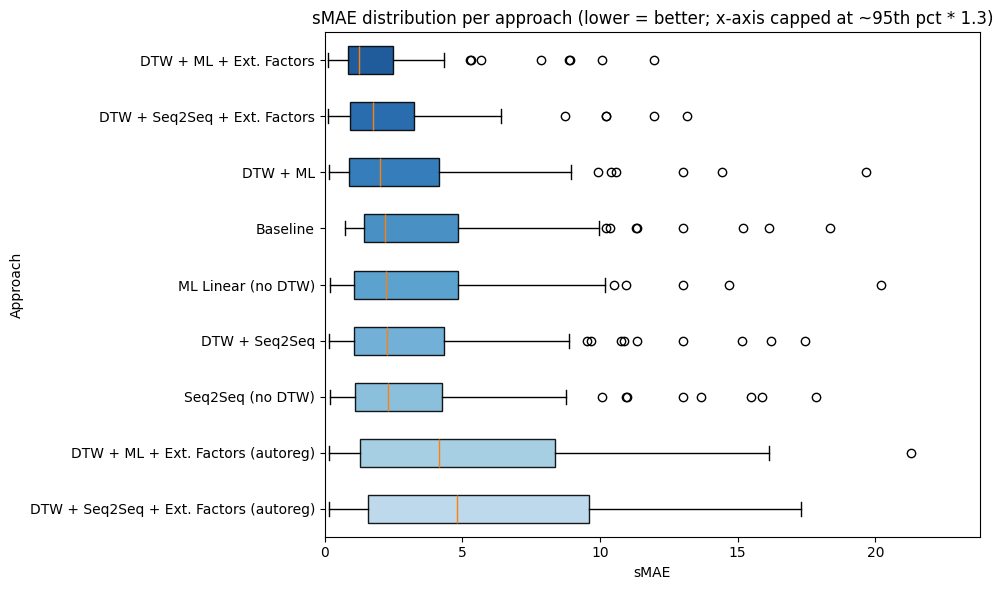

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
# Matplotlib horizontal boxplots build from bottom to top, 
# so making the lowest median last puts it at the very top of the chart.
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'
fig, ax = plt.subplots(figsize=(10, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

# vert=False makes it horizontal (labels on left, values on x-axis)
# patch_artist=True allows us to fill the boxes with color
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False, patch_artist=True)

# Add different scales of blue using the 'Blues' colormap
# We start at 0.3 so the lightest blue isn't completely white/invisible
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(data)))
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black') # Added black edges so the boxes stand out better
    patch.set_alpha(0.9)

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update titles and labels
ax.set_title(f'{metric} distribution per approach (lower = better; x-axis capped at ~95th pct * 1.3)')
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_approach_sMAE_boxplot.png', dpi=130)
plt.show()

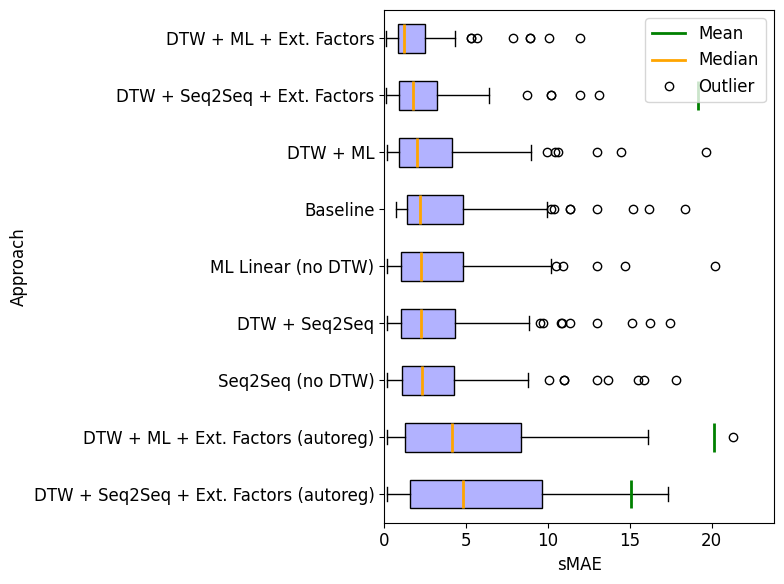

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Set global font size to 12 so all text is bigger
plt.rcParams.update({'font.size': 12})

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'
# Reduced width from 10 to 8 to make it less wide
fig, ax = plt.subplots(figsize=(8, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

# meanline=True turns the mean marker into a line across the box
# meanprops allows us to customize the color/style of that mean line
bplot = ax.boxplot(
    data, 
    tick_labels=box_order, 
    showfliers=True, 
    showmeans=True, 
    meanline=True, 
    vert=False, 
    patch_artist=True,
    meanprops=dict(color='green', linewidth=2, linestyle='-'),
    medianprops=dict(color='orange', linewidth=2)
)

# Apply the requested blue with alpha=0.1
# We apply alpha only to the facecolor so the black edges remain solid and visible
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)

for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba)
    patch.set_edgecolor('black')

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update labels
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

# Create custom legend for Mean, Median, and Outlier
legend_elements = [
    Line2D([0], [0], color='green', lw=2, linestyle='-', label='Mean'),
    Line2D([0], [0], color='orange', lw=2, label='Median'),
    Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor='none', markersize=6, label='Outlier')
]
ax.legend(handles=legend_elements, loc='upper right')


fig.tight_layout()
fig.savefig('visuals/energy_approach_sMAE_boxplot.pdf', dpi=1300)
plt.show()

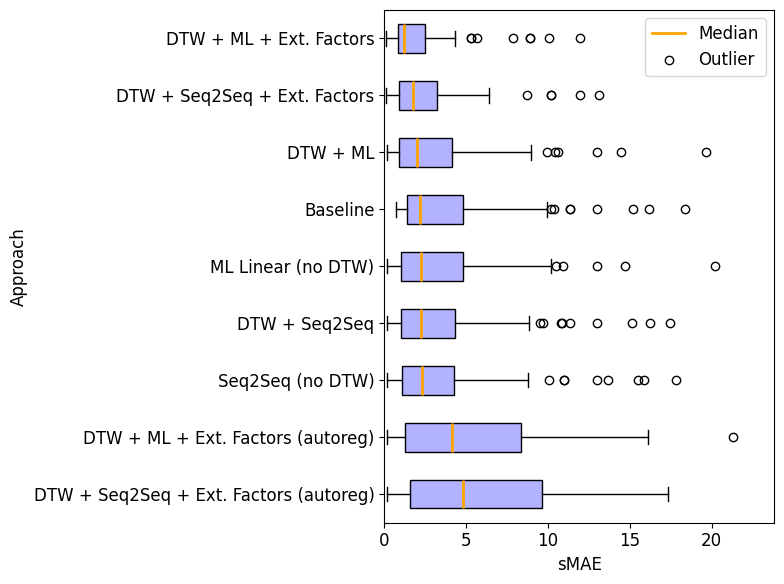

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Set global font size to 12 so all text is bigger
plt.rcParams.update({'font.size': 12})

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'

fig, ax = plt.subplots(figsize=(8, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

bplot = ax.boxplot(
    data, 
    tick_labels=box_order, 
    showfliers=True, 
    showmeans=False, 
    vert=False, 
    patch_artist=True,
    medianprops=dict(color='orange', linewidth=2)
)

# Apply the requested blue with alpha=0.3
# We apply alpha only to the facecolor so the black edges remain solid and visible
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)

for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba)
    patch.set_edgecolor('black')

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update labels
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

# Create custom legend for Median and Outlier
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Median'),
    Line2D([0], [0], marker='o', color='w',
           markeredgecolor='black', markerfacecolor='none',
           markersize=6, label='Outlier')
]
ax.legend(handles=legend_elements, loc='upper right')

fig.tight_layout()
fig.savefig('visuals/energy_approach_sMAE_boxplot.pdf', dpi=1300)
plt.show()

In [15]:
df_energy_results = pd.read_parquet(run_dir / 'summary_train_test.parquet')

#df_energy_results = df_energy_results[['Approach', 'MAE_TEST', 'RMSE_TEST', 'WAPE_TEST']]

df_energy_results

,Process,Sensor,Approach,MAE_TRAIN,RMSE_TRAIN,WAPE_TRAIN,sMAE_TRAIN,sRMSE_TRAIN,MAE_TEST,RMSE_TEST,WAPE_TEST,sMAE_TEST,sRMSE_TEST
0,process_1,autoclave_cooling_water_demand_kW_energy_to_model,Baseline,3.8946,3.8946,62.3951,0.8844,1.0110,3.8946,3.8946,62.9509,0.8835,1.0138
1,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Ext. Factors + Prev Act,0.4877,2.0378,7.2851,0.1036,0.1413,1.6019,4.0080,9.9447,0.1396,0.2031
2,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Ext. Factors + Prev Act (autoreg),0.5882,2.5217,7.6732,0.1098,0.1496,2.3231,5.1446,10.8966,0.1512,0.2458
3,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Seq2Seq,1.9022,2.4445,9.7628,0.1387,0.2093,2.1177,2.5548,10.8486,0.1538,0.2357
4,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Seq2Seq + Ext. Factors + Prev Act,1.6627,2.2606,8.5411,0.1212,0.1629,1.9327,2.9796,9.8081,0.1382,0.1928
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,DTW + pos,0.3368,0.4084,0.5726,0.5329,0.7124,1.2263,1.3968,2.0681,1.6793,1.8666
997,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,ML DTW + Linear Decode,0.5153,0.6125,0.8689,0.8846,1.0995,1.6117,1.7219,2.7863,1.8281,2.0454
998,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,ML Linear (no DTW),0.3026,0.3678,0.5122,0.4358,0.5249,1.6501,1.8215,2.8475,2.1560,2.3498
999,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,Seq2Seq DTW + Linear Decode,0.6048,0.6952,1.0219,0.8798,1.1211,1.5634,1.6968,2.6889,1.8788,2.1507


In [16]:
df_energy_results['Approach'].unique()

array(['Baseline', 'DTW + Ext. Factors + Prev Act',
       'DTW + Ext. Factors + Prev Act (autoreg)', 'DTW + Seq2Seq',
       'DTW + Seq2Seq + Ext. Factors + Prev Act',
       'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)', 'DTW + pos',
       'ML DTW + Linear Decode', 'ML Linear (no DTW)',
       'Seq2Seq DTW + Linear Decode', 'Seq2Seq only (no DTW)'],
      dtype=object)

In [17]:
df_energy_results['Process'].value_counts()

Process
process_5      308
process_4_1    253
process_4_2    253
process_1       77
process_2       55
process_3       55
Name: count, dtype: int64

# Joint Duration + Profile Evaluation

Three tables:
1. **All together** — median sMAE / sRMSE / WAPE per curve approach, aggregated over all processes (best SimMode per process used for durations).
2. **Per simulation mode** — rows = simulation mode sorted by duration WAPE, cols = curve metrics; one table per process × curve approach (requires `curve_joint_duration_eval_per_mode.parquet` from a fresh pipeline run).
3. **Combined** — the process-results table from above extended with curve columns for Baseline and best curve approach; shows that curve quality degrades together with duration quality.

In [18]:
import re as _re

# ── Joint eval ALL TOGETHER — median by Approach across all processes ─────────
_jall_path = run_dir / 'curve_joint_duration_eval_results.parquet'
if not _jall_path.exists():
    print(f'Not found: {_jall_path}  (run the pipeline first)')
else:
    _jall = pd.read_parquet(_jall_path)
    _jm = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jall.columns]

    # Median per Approach (across all processes, sensors, activities)
    _jall_agg = _jall.groupby('Approach')[_jm].median().round(4)
    _sort_col  = 'WAPE' if 'WAPE' in _jall_agg.columns else _jm[0]
    _jall_agg  = _jall_agg.sort_values(_sort_col)
    display(_jall_agg)

    # Bold the best (lowest) per column
    _jall_str = pd.DataFrame(index=_jall_agg.index, columns=_jall_agg.columns, dtype=object)
    for _c in _jall_agg.columns:
        _best = _jall_agg[_c].dropna().min()
        for _idx in _jall_agg.index:
            _v = _jall_agg.loc[_idx, _c]
            if pd.isna(_v):
                _jall_str.loc[_idx, _c] = ''
            else:
                _fmt = f'{_v:.3f}'
                _jall_str.loc[_idx, _c] = (r'\textbf{' + _fmt + r'}') if abs(_v - _best) < 1e-6 else _fmt

    _jall_str.columns = [
        r'\makecell{sMAE}' if c == 'sMAE' else
        r'\makecell{sRMSE}' if c == 'sRMSE' else
        r'\makecell{WAPE (\%)}' for c in _jall_str.columns
    ]
    _jall_latex = _jall_str.to_latex(
        escape=False,
        column_format='l|' + '|'.join(['c'] * len(_jm)),
        caption=(
            r'Joint duration + profile evaluation: median sMAE / sRMSE / WAPE per curve approach, '
            r'aggregated over all processes and sensors. '
            r'Simulated durations come from the best process model per process (lowest test duration WAPE). '
            r'Lower is better. \textbf{Bold} = best approach.'
        ),
        label=f'tab:joint_eval_all_{EXPERIMENT}',
        position='H',
    )
    print(_jall_latex.replace('_', r'\_'))

Not found: ../results/experiment_929_20260715_173217/curve_joint_duration_eval_results.parquet  (run the pipeline first)


In [19]:
# ── Joint eval PER SIMULATION MODE ───────────────────────────────────────────
# Rows = simulation mode sorted by duration WAPE (best first).
# Columns = sMAE / sRMSE / WAPE for Baseline and best curve approach per process.
# Requires curve_joint_duration_eval_per_mode.parquet (generated by the new pipeline block).

_jpm_path = run_dir / 'curve_joint_duration_eval_per_mode.parquet'
if not _jpm_path.exists():
    print(f'Per-mode joint eval not found at:\n  {_jpm_path}\n'
          'Re-run the pipeline after the modelling.py update to generate this file.')
else:
    _jpm = pd.read_parquet(_jpm_path)
    _jpm_metrics = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jpm.columns]

    # Duration WAPE per (process, mode) for row ordering
    _pe2 = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _wc2 = next((c for c in ['test_duration_metrics_activity_duration_wape',
                              'test_duration_metrics_activity_duration_mae']
                 if c in _pe2.columns), None)
    _mwape = {}
    if _wc2:
        for (_pp, _pm), _gg in _pe2.groupby(['process', 'mode']):
            _vv = _gg[_wc2].dropna()
            if not _vv.empty:
                _mwape[(_pp, _pm)] = float(_vv.min())

    # Best curve approach per process (lowest median WAPE_TEST)
    _stp = run_dir / 'summary_train_test.parquet'
    _best_appr_pm = {}
    if _stp.exists():
        _stdf = pd.read_parquet(_stp)
        for _pr, _sg in _stdf.groupby('Process'):
            _pa = _sg.groupby('Approach')['WAPE_TEST'].median()
            if not _pa.empty:
                _best_appr_pm[_pr] = _pa.idxmin()

    def _fmt_sim_mode(m):
        m = str(m)
        if not m.startswith('petri_net_'):
            return m.replace('_', r'\_')
        rest = m[len('petri_net_'):]
        if rest.endswith('_ml_plus_per_act'):
            return rest[:-len('_ml_plus_per_act')].replace('_', r'\_') + r' / ml\_local'
        if rest.endswith('_ml_plus_global'):
            return rest[:-len('_ml_plus_global')].replace('_', r'\_') + r' / ml\_global'
        return rest.replace('_', r'\_') + r' / baseline'

    _pm_latex_parts = []

    for _proc in processes:
        _psub = _jpm[_jpm['Process'] == _proc]
        if _psub.empty:
            continue
        _best_ap = _best_appr_pm.get(_proc, 'Baseline')
        _mode_order = sorted(_psub['SimMode'].unique(),
                             key=lambda m: _mwape.get((_proc, m), 999))

        # One sub-table per approach (Baseline + best)
        for _ap_key, _ap_tag in [('Baseline', 'Baseline'), (_best_ap, 'Best')]:
            _sub_ap = (_psub[_psub['Approach'] == _ap_key]
                       .groupby('SimMode')[_jpm_metrics].median())
            if _sub_ap.empty:
                continue
            _sub_ap = _sub_ap.reindex(_mode_order).round(4)
            _sub_ap.index = [_fmt_sim_mode(m) for m in _sub_ap.index]

            # Bold best (lowest) per column
            _sub_str = pd.DataFrame(index=_sub_ap.index, columns=_sub_ap.columns, dtype=object)
            for _c in _sub_ap.columns:
                _best = _sub_ap[_c].dropna().min()
                for _idx in _sub_ap.index:
                    _v = _sub_ap.loc[_idx, _c]
                    if pd.isna(_v):
                        _sub_str.loc[_idx, _c] = ''
                    else:
                        _fmt2 = f'{_v:.3f}'
                        _sub_str.loc[_idx, _c] = (r'\textbf{' + _fmt2 + r'}') if abs(_v - _best) < 1e-6 else _fmt2

            _proc_ltx = _proc.replace("_", r"\_")
            _ap_key_ltx = _ap_key.replace("_", r"\_")  # if you want LaTeX-escaped underscores

            _sub_str.columns = [
                r'\makecell{sMAE}' if c == 'sMAE' else
                r'\makecell{sRMSE}' if c == 'sRMSE' else
                r'\makecell{WAPE (\%)}' for c in _sub_str.columns
            ]

            _col_fmt = 'l|' + '|'.join(['c'] * len(_jpm_metrics))

            _ltx = _sub_str.to_latex(
                escape=False,
                column_format=_col_fmt,
                caption=(
                    f'Joint eval per simulation mode — {_proc_ltx}, '
                    f'curve approach: {_ap_tag} ({_ap_key_ltx}). '
                    r'Rows sorted by test duration WAPE (best mode first). '
                    r'Lower is better. \textbf{Bold} = best simulation mode.'
                ),
                label=f'tab:joint_pm_{EXPERIMENT}_{_proc}_{_ap_tag.lower()}',
                position='H',
            )

            print(_ltx)
            _pm_latex_parts.append(_ltx)

Per-mode joint eval not found at:
  ../results/experiment_929_20260715_173217/curve_joint_duration_eval_per_mode.parquet
Re-run the pipeline after the modelling.py update to generate this file.


In [20]:
# ── COMBINED TABLE: process metrics + energy curve columns ────────────────────
# Same row structure as the main process-results table above.
# Three extra column groups added for Baseline and best curve approach:
#   sMAE | sRMSE | WAPE (energy)
# Source: curve_joint_duration_eval_per_mode.parquet (per-mode) if available,
#         falling back to curve_joint_duration_eval_results.parquet (best mode only).

_jpm_path  = run_dir / 'curve_joint_duration_eval_per_mode.parquet'
_jall_path = run_dir / 'curve_joint_duration_eval_results.parquet'

if _jpm_path.exists():
    _jsrc_comb = pd.read_parquet(_jpm_path)
    print(f'Using per-mode joint eval ({len(_jsrc_comb)} rows)')
elif _jall_path.exists():
    _jsrc_comb = pd.read_parquet(_jall_path)
    if 'BestMode' in _jsrc_comb.columns and 'SimMode' not in _jsrc_comb.columns:
        _jsrc_comb = _jsrc_comb.rename(columns={'BestMode': 'SimMode'})
    print(f'Per-mode file absent — using best-mode joint eval ({len(_jsrc_comb)} rows). '
          'Rows for non-best modes will show NaN in curve columns.')
else:
    _jsrc_comb = None
    print('No joint eval data found; run the pipeline first.')

if _jsrc_comb is not None:
    _comb_metrics = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jsrc_comb.columns]

    # Pre-aggregate lookup: (Process, SimMode, Approach) → median curve metrics
    _jlkp = (
        _jsrc_comb
        .groupby(['Process', 'SimMode', 'Approach'])[_comb_metrics]
        .median()
    )

    # Best curve approach per process
    _stp2 = run_dir / 'summary_train_test.parquet'
    _best_ap_comb = {}
    if _stp2.exists():
        _stdf2 = pd.read_parquet(_stp2)
        for _pr2, _sg2 in _stdf2.groupby('Process'):
            _pa2 = _sg2.groupby('Approach')['WAPE_TEST'].median()
            if not _pa2.empty:
                _best_ap_comb[_pr2] = _pa2.idxmin()

    # Map (Process, ProcessModelLabel, DurationPredLabel) → raw SimMode string
    _pe_comb = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _ba_comb = {}
    for _pc in processes:
        _ba_comb[_pc] = pick_best_algo(_pe_comb[_pe_comb['process'] == _pc], split_prefix)

    def _label_to_simmode(proc, pmodel_lbl, dpred_lbl):
        ba = _ba_comb.get(proc, 'heuristic')
        if 'alpha' in pmodel_lbl:
            return 'petri_net_alpha'
        if 'ml_local'  in dpred_lbl: return f'petri_net_{ba}_ml_plus_per_act'
        if 'ml_global' in dpred_lbl: return f'petri_net_{ba}_ml_plus_global'
        return f'petri_net_{ba}'

    def _curve_vals(proc, sim_mode, approach):
        try:
            row = _jlkp.loc[(proc, sim_mode, approach)]
            return {m: row[m] for m in _comb_metrics}
        except KeyError:
            return {m: float('nan') for m in _comb_metrics}

    # ── Build extended table ──────────────────────────────────────────────────
    _ext_frames = []
    for proc in processes:
        sub_pe = _pe_comb[_pe_comb['process'] == proc]
        ba = _ba_comb[proc]
        best_ap = _best_ap_comb.get(proc, 'Baseline')
        pn = f'{ba} petri net'

        modes_to_show = ['petri_net_alpha', f'petri_net_{ba}',
                         f'petri_net_{ba}_ml_plus_global', f'petri_net_{ba}_ml_plus_per_act']
        sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
        sub_pe['mode_label'] = sub_pe['mode'].apply(lambda m: make_mode_label(m, ba))

        row_order = [f'{pn} / ml_local', f'{pn} / ml_global',
                     f'{pn} / baseline', 'alpha petri net / baseline']
        sub_pe = sub_pe.set_index('mode_label')[metric_cols]
        sub_pe = sub_pe.reindex([r for r in row_order if r in sub_pe.index])
        sub_pe.columns = [METRIC_LABELS.get(c, c) for c in sub_pe.columns]

        # Append curve metric columns for Baseline and best approach
        for _ck, _ctag in [('Baseline', 'Baseline'), (best_ap, 'Best')]:
            for _m in _comb_metrics:
                sub_pe[f'{_m} ({_ctag})'] = float('nan')

        for row_lbl in sub_pe.index:
            _pml, _dpl = split_mode(row_lbl)
            _sm = _label_to_simmode(proc, _pml, _dpl)
            for _ck, _ctag in [('Baseline', 'Baseline'), (best_ap, 'Best')]:
                _cv = _curve_vals(proc, _sm, _ck)
                for _m, _v in _cv.items():
                    sub_pe.loc[row_lbl, f'{_m} ({_ctag})'] = _v

        _pml_arr, _dpl_arr = zip(*[split_mode(r) for r in sub_pe.index])
        sub_pe.index = pd.MultiIndex.from_arrays(
            [[proc] * len(sub_pe), list(_pml_arr), list(_dpl_arr)],
            names=['Process', 'Process Model', 'Duration Pred.']
        )
        _ext_frames.append(sub_pe)

    ext_table = pd.concat(_ext_frames)
    display(ext_table)

    # ── LaTeX ─────────────────────────────────────────────────────────────────
    _higher_better_keys = {'F1 Score', 'Fitness', 'Precision'}

    def _is_hb_ext(col_label):
        return any(kw in col_label for kw in _higher_better_keys)

    _ext_str = pd.DataFrame(index=ext_table.index, columns=ext_table.columns, dtype=object)
    for proc in processes:
        _pmask = ext_table.index.get_level_values('Process') == proc
        _prows = ext_table[_pmask]
        for col in ext_table.columns:
            _vals = _prows[col].dropna()
            if _vals.empty:
                for idx in _prows.index: _ext_str.loc[idx, col] = ''
                continue
            _best_v = _vals.max() if _is_hb_ext(col) else _vals.min()
            for idx in _prows.index:
                _v2 = ext_table.loc[idx, col]
                if pd.isna(_v2):
                    _ext_str.loc[idx, col] = ''
                else:
                    _f2 = f'{_v2:.3f}'
                    _ext_str.loc[idx, col] = (r'\textbf{' + _f2 + r'}') if abs(_v2 - _best_v) < 1e-6 else _f2

    # Column format: process cols | baseline energy | best energy
    _n_proc   = len(metric_cols)
    _n_curve  = len(_comb_metrics)
    _col_fmt  = 'lll|' + '|'.join(['c'] * _n_proc) + '||' + '|'.join(['c'] * _n_curve) + '||' + '|'.join(['c'] * _n_curve)

    # Column header labels
    def _curve_col_label(m, tag):
        _nm = {'sMAE': r'sMAE', 'sRMSE': r'sRMSE', 'WAPE': r'WAPE\,(\%)'}
        return r'\makecell{' + _nm.get(m, m) + r'\\' + tag + r'}'

    _ext_str.columns = (
        [METRIC_LABELS.get(c, c) for c in metric_cols]
        + [_curve_col_label(m, 'Baseline') for m in _comb_metrics]
        + [_curve_col_label(m, 'Best')     for m in _comb_metrics]
    )

    _best_ap_label = ', '.join(sorted(set(_best_ap_comb.values())))
    _ext_latex = _ext_str.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        multirow=True,
        escape=False,
        column_format=_col_fmt,
        caption=(
            f'Combined process and energy-curve results for experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Left block: process model quality metrics (duration error, control-flow, conformance). '
            r'Middle block: energy curve quality using Baseline approach (mean barycenter, no DTW). '
            r'Right block: energy curve quality using the best curve approach per process '
            f'({_best_ap_label.replace("_", r"_")}). '
            r'Curve metrics are evaluated with simulated durations from each row\'s simulation mode '
            r'(shows how curve quality co-degrades with duration quality). '
            r'sMAE / sRMSE standardised by per-sensor std; WAPE is scale-free. '
            r'Lower is better for all metrics except Edge F1 Score, Fitness, Precision (higher = better). '
            r'\textbf{Bold} = best value per process per metric.'
        ),
        label=f'tab:combined_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    # Clean clines; insert midrules between processes
    _ext_latex = _re.sub(r'\s*\\cline\{[^}]+\}', '', _ext_latex)
    _ext_lines, _ext_new, _ext_cnt = _ext_latex.split('\n'), [], 0
    for _ln in _ext_lines:
        if _re.search(r'\\multirow.*\{process_', _ln):
            if _ext_cnt > 0: _ext_new.append(r'\midrule')
            _ext_cnt += 1
        _ext_new.append(_ln)
    _ext_latex = '\n'.join(_ext_new)
    print(_ext_latex.replace('_', r'\_'))

No joint eval data found; run the pipeline first.


# Energy Distribution Evaluation (case/activity/sensor and case/sensor)

No curve/instance matching -- compares the *distribution* of per-instance energy summary stats (mean/total per activity instance) between the real test set and the simulated log, via Wasserstein (Earth Mover) distance. Lower = simulated distribution closer to real. Reads `energy_distribution_results/<process>/<mode>/*.csv` from the run folder (populated only when `run_energy_modelling=True` for that run).

In [21]:
# -- Load energy-distribution results (case/sensor granularity, total_value) --
energy_dist_dir = run_dir / 'energy_distribution_results'
if not energy_dist_dir.exists():
    print(f'Not found: {energy_dist_dir}\n(run the pipeline with run_energy_modelling=True to generate it)')
    df_energy_dist = pd.DataFrame()
else:
    rows = []
    for proc_dir in sorted(energy_dist_dir.iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            if not mode_dir.is_dir():
                continue
            csv_path = mode_dir / 'per_case_sensor_total.csv'
            core_path = mode_dir / 'core_metrics.csv'
            if not csv_path.exists():
                continue
            sensor_df = pd.read_csv(csv_path)
            # Recover the real mode string (not the filesystem-safe folder name) from core_metrics.csv
            mode_name = mode_dir.name
            if core_path.exists():
                core_df = pd.read_csv(core_path)
                if 'mode' in core_df.columns and len(core_df) > 0:
                    mode_name = core_df['mode'].iloc[0]
            for _, r in sensor_df.iterrows():
                rows.append({
                    'process': proc_dir.name,
                    'mode': mode_name,
                    'sensor': r['sensor'],
                    'wasserstein': r['wasserstein'],
                    'real_median': r.get('real_median'),
                    'sim_median': r.get('sim_median'),
                })
    df_energy_dist = pd.DataFrame(rows)

print(f'{len(df_energy_dist)} (process, mode, sensor) rows loaded')
df_energy_dist.head(20)

1105 (process, mode, sensor) rows loaded


,process,mode,sensor,wasserstein,real_median,sim_median
0,process_1,petri_net_alpha,bottling_power_kW_energy_to_model,19.330675,21.569120,0.211349
1,process_1,petri_net_alpha,destillation_cooling_demand_kW_energy_to_model,32682.011823,36663.213307,3655.896174
2,process_1,petri_net_alpha,destillation_steam_demand_kW_energy_to_model,31726.443597,34904.981856,2947.491301
3,process_1,petri_net_alpha,individual_packaging_power_kW_energy_to_model,178.464930,140.610836,0.089104
4,process_1,petri_net_alpha_ml_plus_global,bottling_power_kW_energy_to_model,19.330675,21.569120,0.211349
5,process_1,petri_net_alpha_ml_plus_global,destillation_cooling_demand_kW_energy_to_model,32829.167347,36663.213307,3605.882370
6,process_1,petri_net_alpha_ml_plus_global,destillation_steam_demand_kW_energy_to_model,31872.676718,34904.981856,2945.218518
7,process_1,petri_net_alpha_ml_plus_global,individual_packaging_power_kW_energy_to_model,178.464930,140.610836,0.089104
8,process_1,petri_net_alpha_ml_plus_per_act,bottling_power_kW_energy_to_model,19.330675,21.569120,0.211349
9,process_1,petri_net_alpha_ml_plus_per_act,destillation_cooling_demand_kW_energy_to_model,32671.033024,36663.213307,3611.216985


In [22]:
# -- One table per process: rows = sensor, columns = mode (Wasserstein distance) --
# Sensor-as-rows keeps each table narrow (num. modes) regardless of how many
# sensors a process has, instead of one giant sparse table across all processes.
def shorten_sensor(name, max_len=40):
    name = str(name).replace('_energy_to_model', '').replace('_to_model', '')
    return name if len(name) <= max_len else name[:max_len - 1] + '…'

if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    df_energy_dist['mode_label'] = df_energy_dist['mode'].map(display_mode)

    for proc in sorted(df_energy_dist['process'].unique()):
        sub = df_energy_dist[df_energy_dist['process'] == proc].copy()
        sub['sensor_short'] = sub['sensor'].map(shorten_sensor)
        pivot = sub.pivot_table(index='sensor_short', columns='mode_label', values='wasserstein', aggfunc='first')

        # Bold the best (lowest) Wasserstein distance per sensor (row)
        str_table = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=object)
        for idx in pivot.index:
            vals = pivot.loc[idx].dropna()
            if vals.empty:
                str_table.loc[idx] = ''
                continue
            best_val = vals.min()
            for col in pivot.columns:
                val = pivot.loc[idx, col]
                if pd.isna(val):
                    str_table.loc[idx, col] = ''
                    continue
                fmt = f'{val:.2f}'
                str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

        n_modes = len(pivot.columns)
        col_format = 'l|' + '|'.join(['c'] * n_modes)
        latex = str_table.to_latex(
            escape=False,
            column_format=col_format,
            caption=(
                f'Energy-distribution evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
                r'Wasserstein (Earth Mover) distance between the per-case total energy distribution '
                r'(real vs.\ simulated), per sensor --- no curve/instance matching. '
                r'Lower is better. \textbf{Bold} = best mode per sensor.'
            ),
            label=f'tab:energy_dist_{EXPERIMENT}_{SPLIT}_{proc}',
            position='H',
        )
        print(f'% === {proc}: {pivot.shape[0]} sensors x {pivot.shape[1]} modes ===')
        print(latex.replace('_', r'\_'))
        print()

    display(df_energy_dist.pivot_table(index=['process', 'sensor'], columns='mode_label', values='wasserstein', aggfunc='first').round(2))

% === process_1: 7 sensors x 13 modes ===
\begin{table}[H]
\caption{Energy-distribution evaluation for process\_1, experiment 929 (test evaluation). Wasserstein (Earth Mover) distance between the per-case total energy distribution (real vs.\ simulated), per sensor --- no curve/instance matching. Lower is better. \textbf{Bold} = best mode per sensor.}
\label{tab:energy\_dist\_929\_test\_process\_1}
\begin{tabular}{l|c|c|c|c|c|c|c|c|c|c|c|c|c}
\toprule
mode\_label & alpha / baseline & alpha / ml\_global & alpha / ml\_local & heuristic / baseline & heuristic / ml\_global & heuristic / ml\_local & inductive / baseline & inductive / ml\_global & inductive / ml\_local & wip\_aware / baseline & wip\_aware / ml\_global & wip\_aware / ml\_local & wip\_branching\_aware / baseline \\
sensor\_short &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
autoclave\_cooling\_water\_demand\_kW &  &  &  & 25251.19 & 25251.19 & 25251.19 & 25509.72 & 25509.73 & 25509.73 & 25251.19 & 25251.19 & 25251.19 & \te

mode_label                                                    alpha / baseline  \
process   sensor                                                                 
process_1 autoclave_cooling_water_demand_kW_energy_to_model                NaN   
          autoclave_steam_demand_kW_energy_to_model                        NaN   
          bottling_power_kW_energy_to_model                              19.33   
          destillation_cooling_demand_kW_energy_to_model              32682.01   
          destillation_steam_demand_kW_energy_to_model                31726.44   
...                                                                        ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...           7849.70   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...          36679.37   
          temp_nach_WR2_(WT2)_5s_energy_to_model                       8193.40   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                24146.87   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                     24194.89   

mode_label                                                    alpha / ml_global  \
process   sensor                                                                  
process_1 autoclave_cooling_water_demand_kW_energy_to_model                 NaN   
          autoclave_steam_demand_kW_energy_to_model                         NaN   
          bottling_power_kW_energy_to_model                               19.33   
          destillation_cooling_demand_kW_energy_to_model               32829.17   
          destillation_steam_demand_kW_energy_to_model                 31872.68   
...                                                                         ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...            7861.50   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...           36730.36   
          temp_nach_WR2_(WT2)_5s_energy_to_model                        8205.10   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                 24181.70   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                      24229.51   

mode_label                                                    alpha / ml_local  \
process   sensor                                                                 
process_1 autoclave_cooling_water_demand_kW_energy_to_model                NaN   
          autoclave_steam_demand_kW_energy_to_model                        NaN   
          bottling_power_kW_energy_to_model                              19.33   
          destillation_cooling_demand_kW_energy_to_model              32671.03   
          destillation_steam_demand_kW_energy_to_model                31719.09   
...                                                                        ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...           7861.50   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...          36730.36   
          temp_nach_WR2_(WT2)_5s_energy_to_model                       8205.10   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                24181.70   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                     24229.51   

mode_label                                                    heuristic / baseline  \
process   sensor                                                                     
process_1 autoclave_cooling_water_demand_kW_energy_to_model               25251.19   
          autoclave_steam_demand_kW_energy_to_model                       52003.95   
          bottling_power_kW_energy_to_model                                  19.33   
          destillation_cooling_demand_kW_energy_to_model                  32659.13   
          destillation_steam_demand_kW_energy_to_model                    31704.14   
...                                                                            ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...               6708.33   
          te

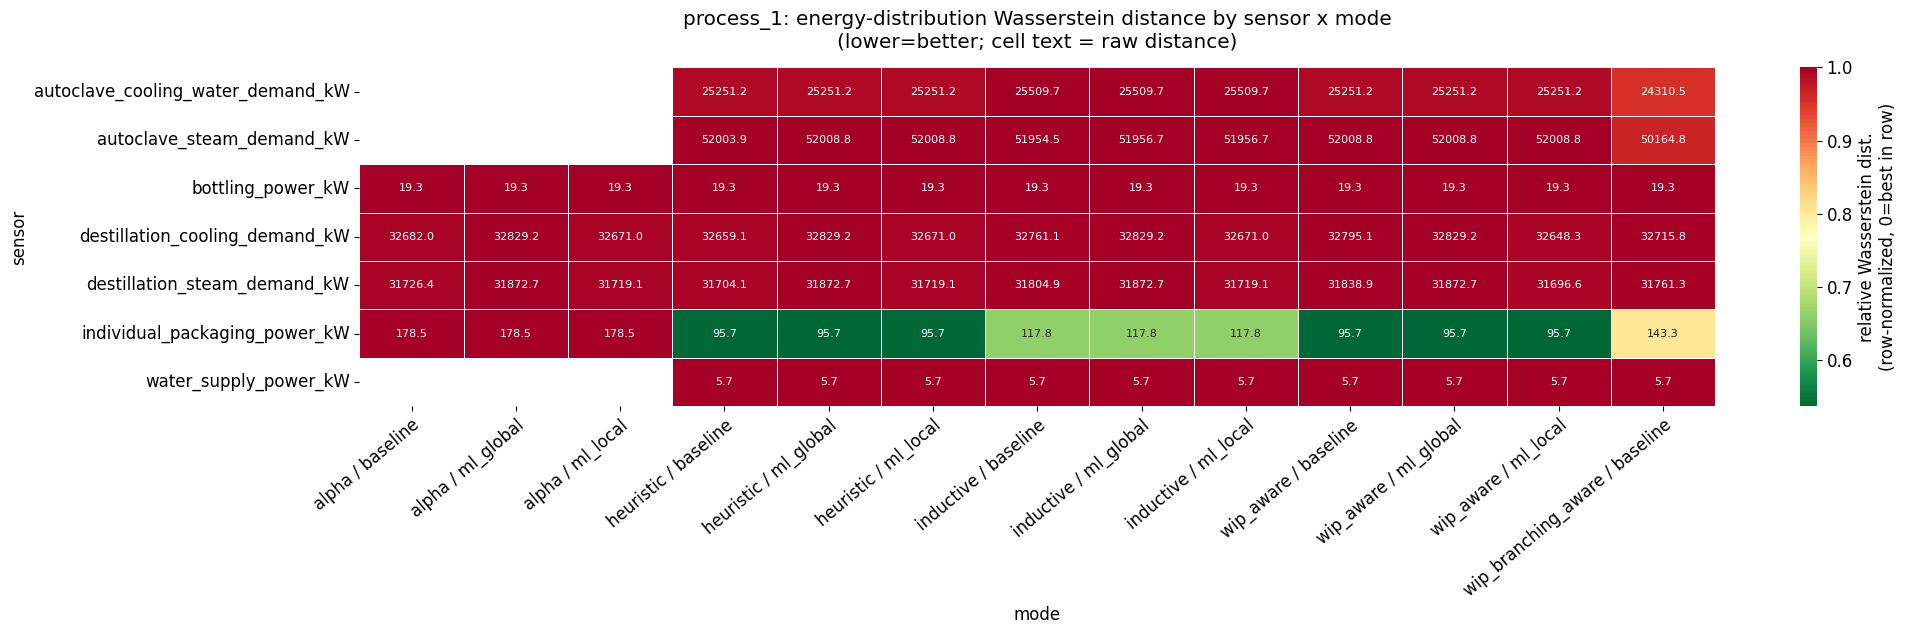

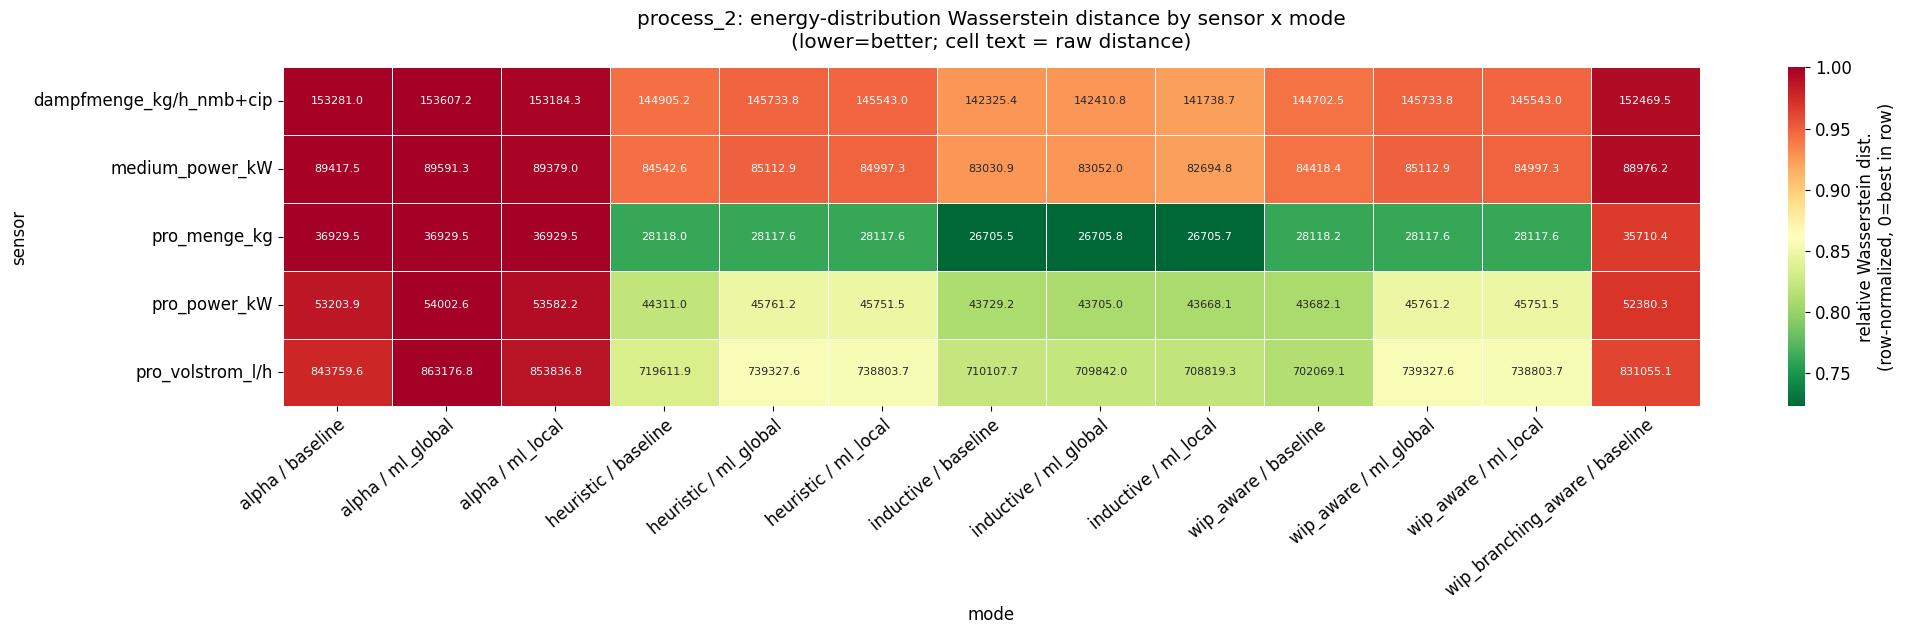

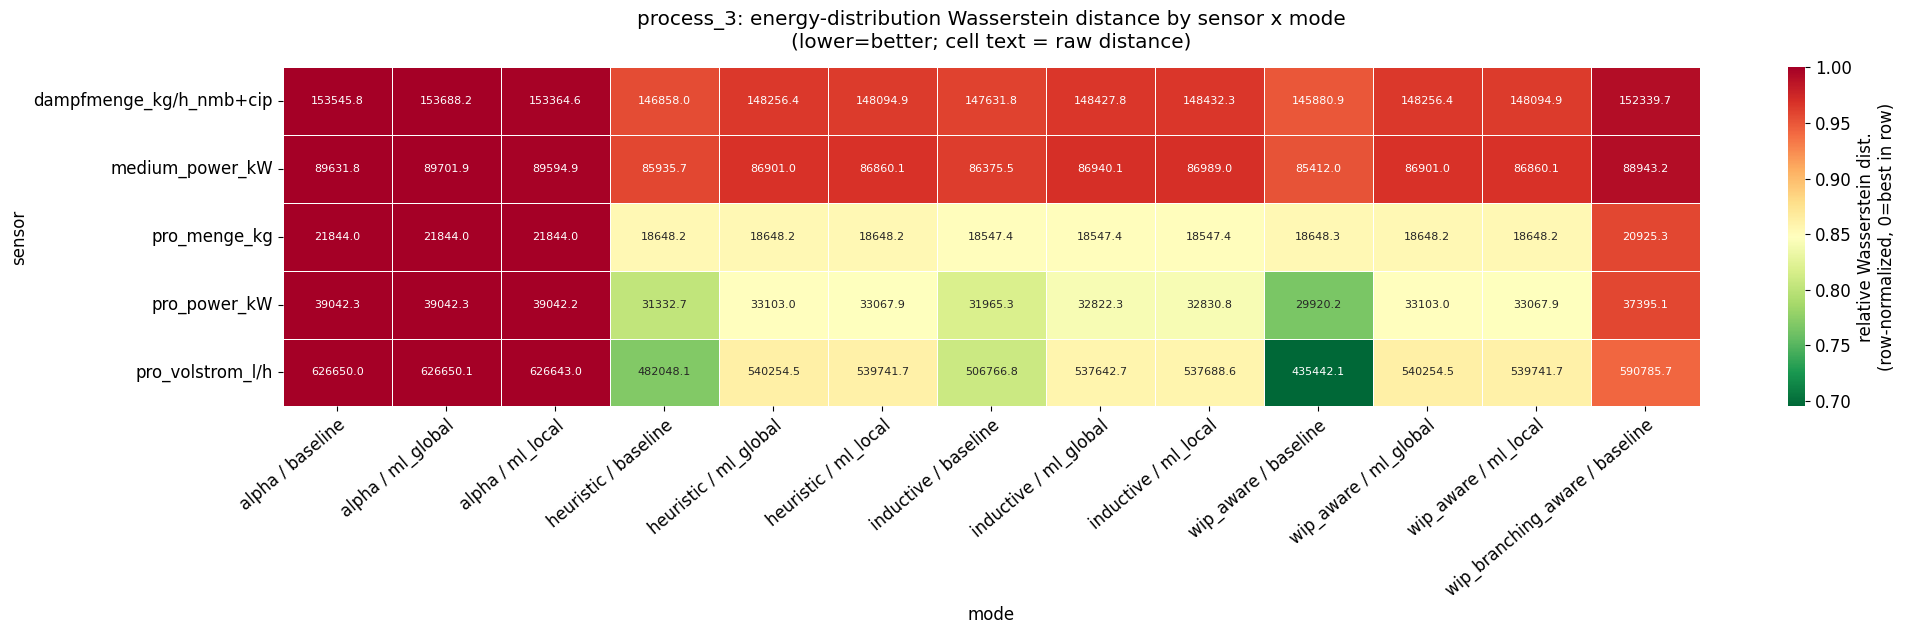

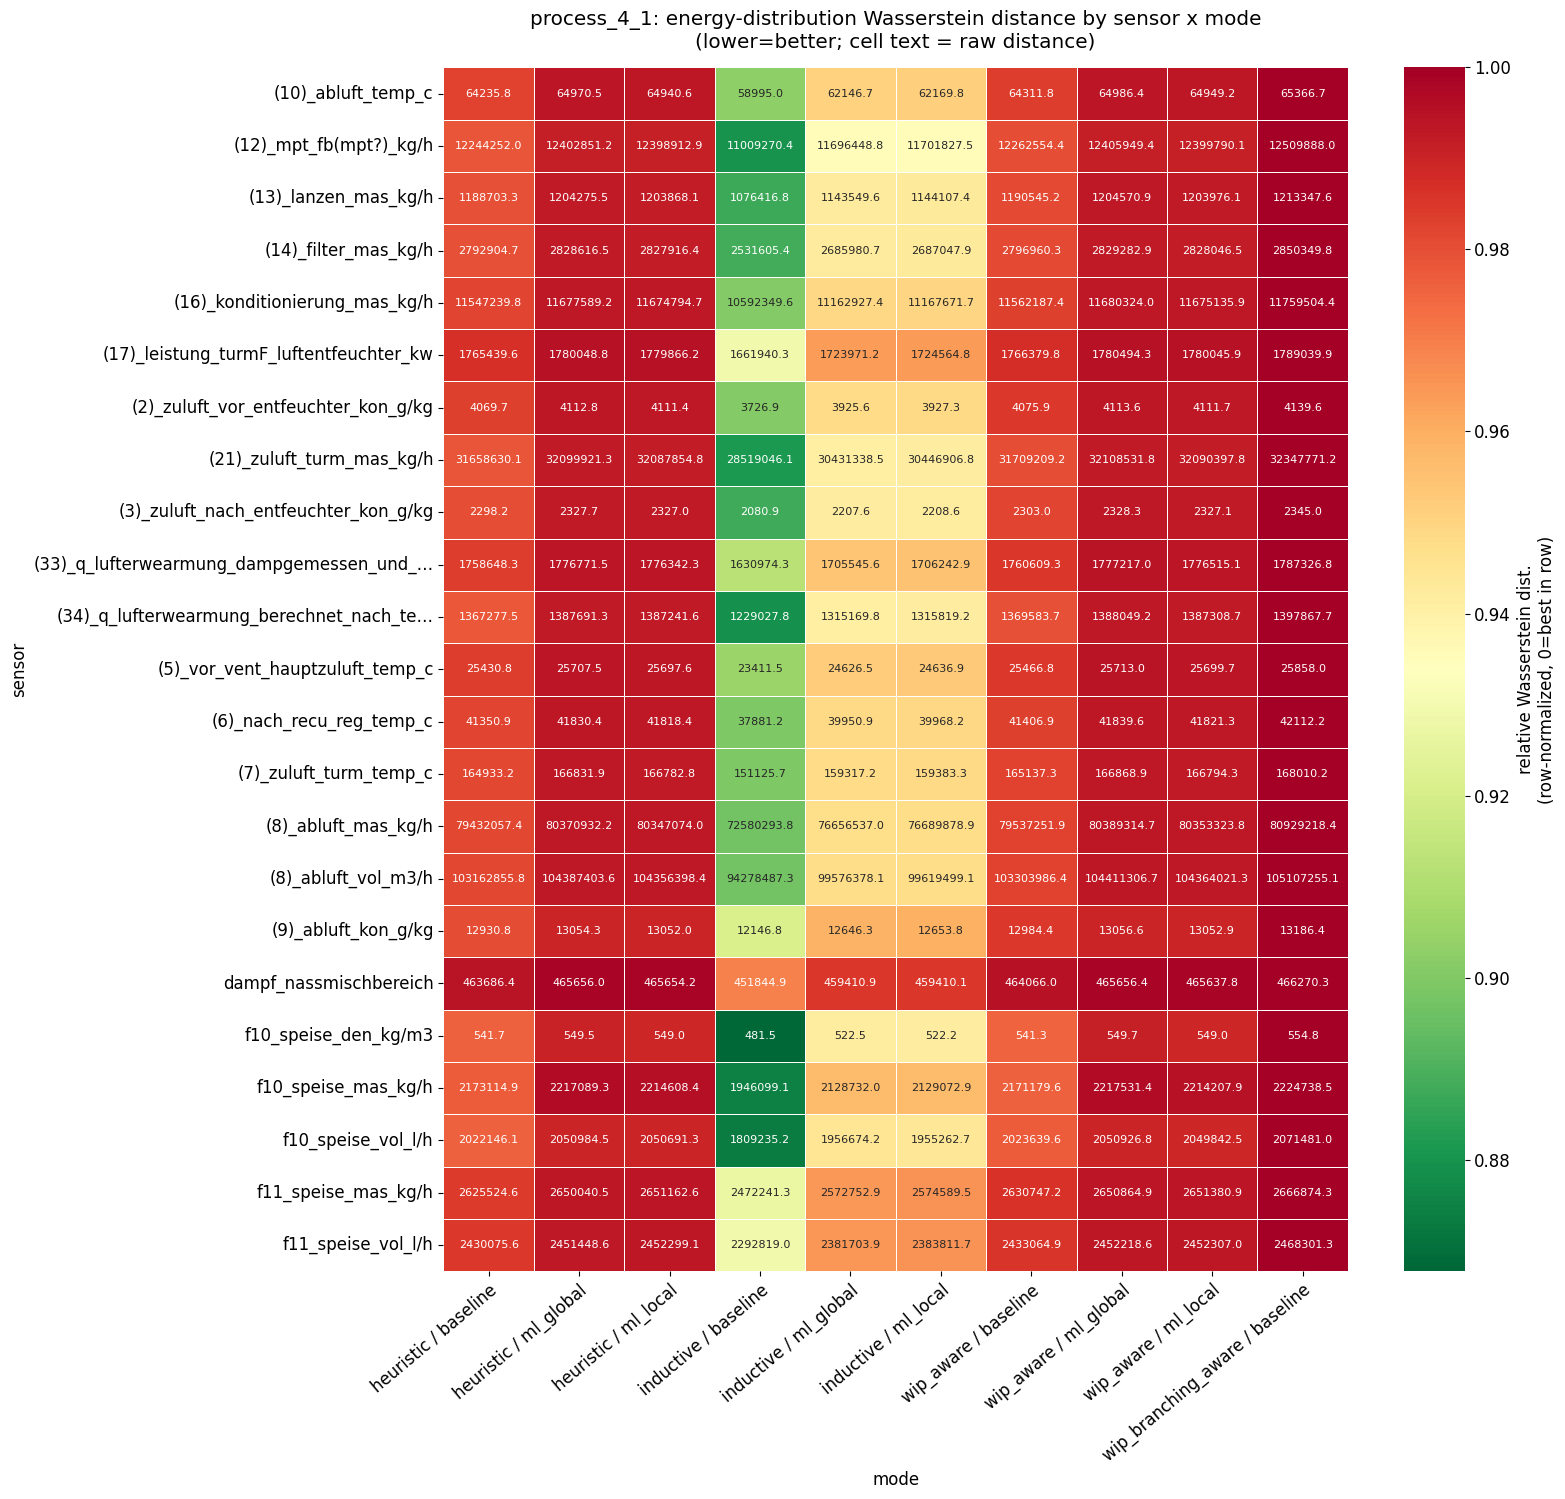

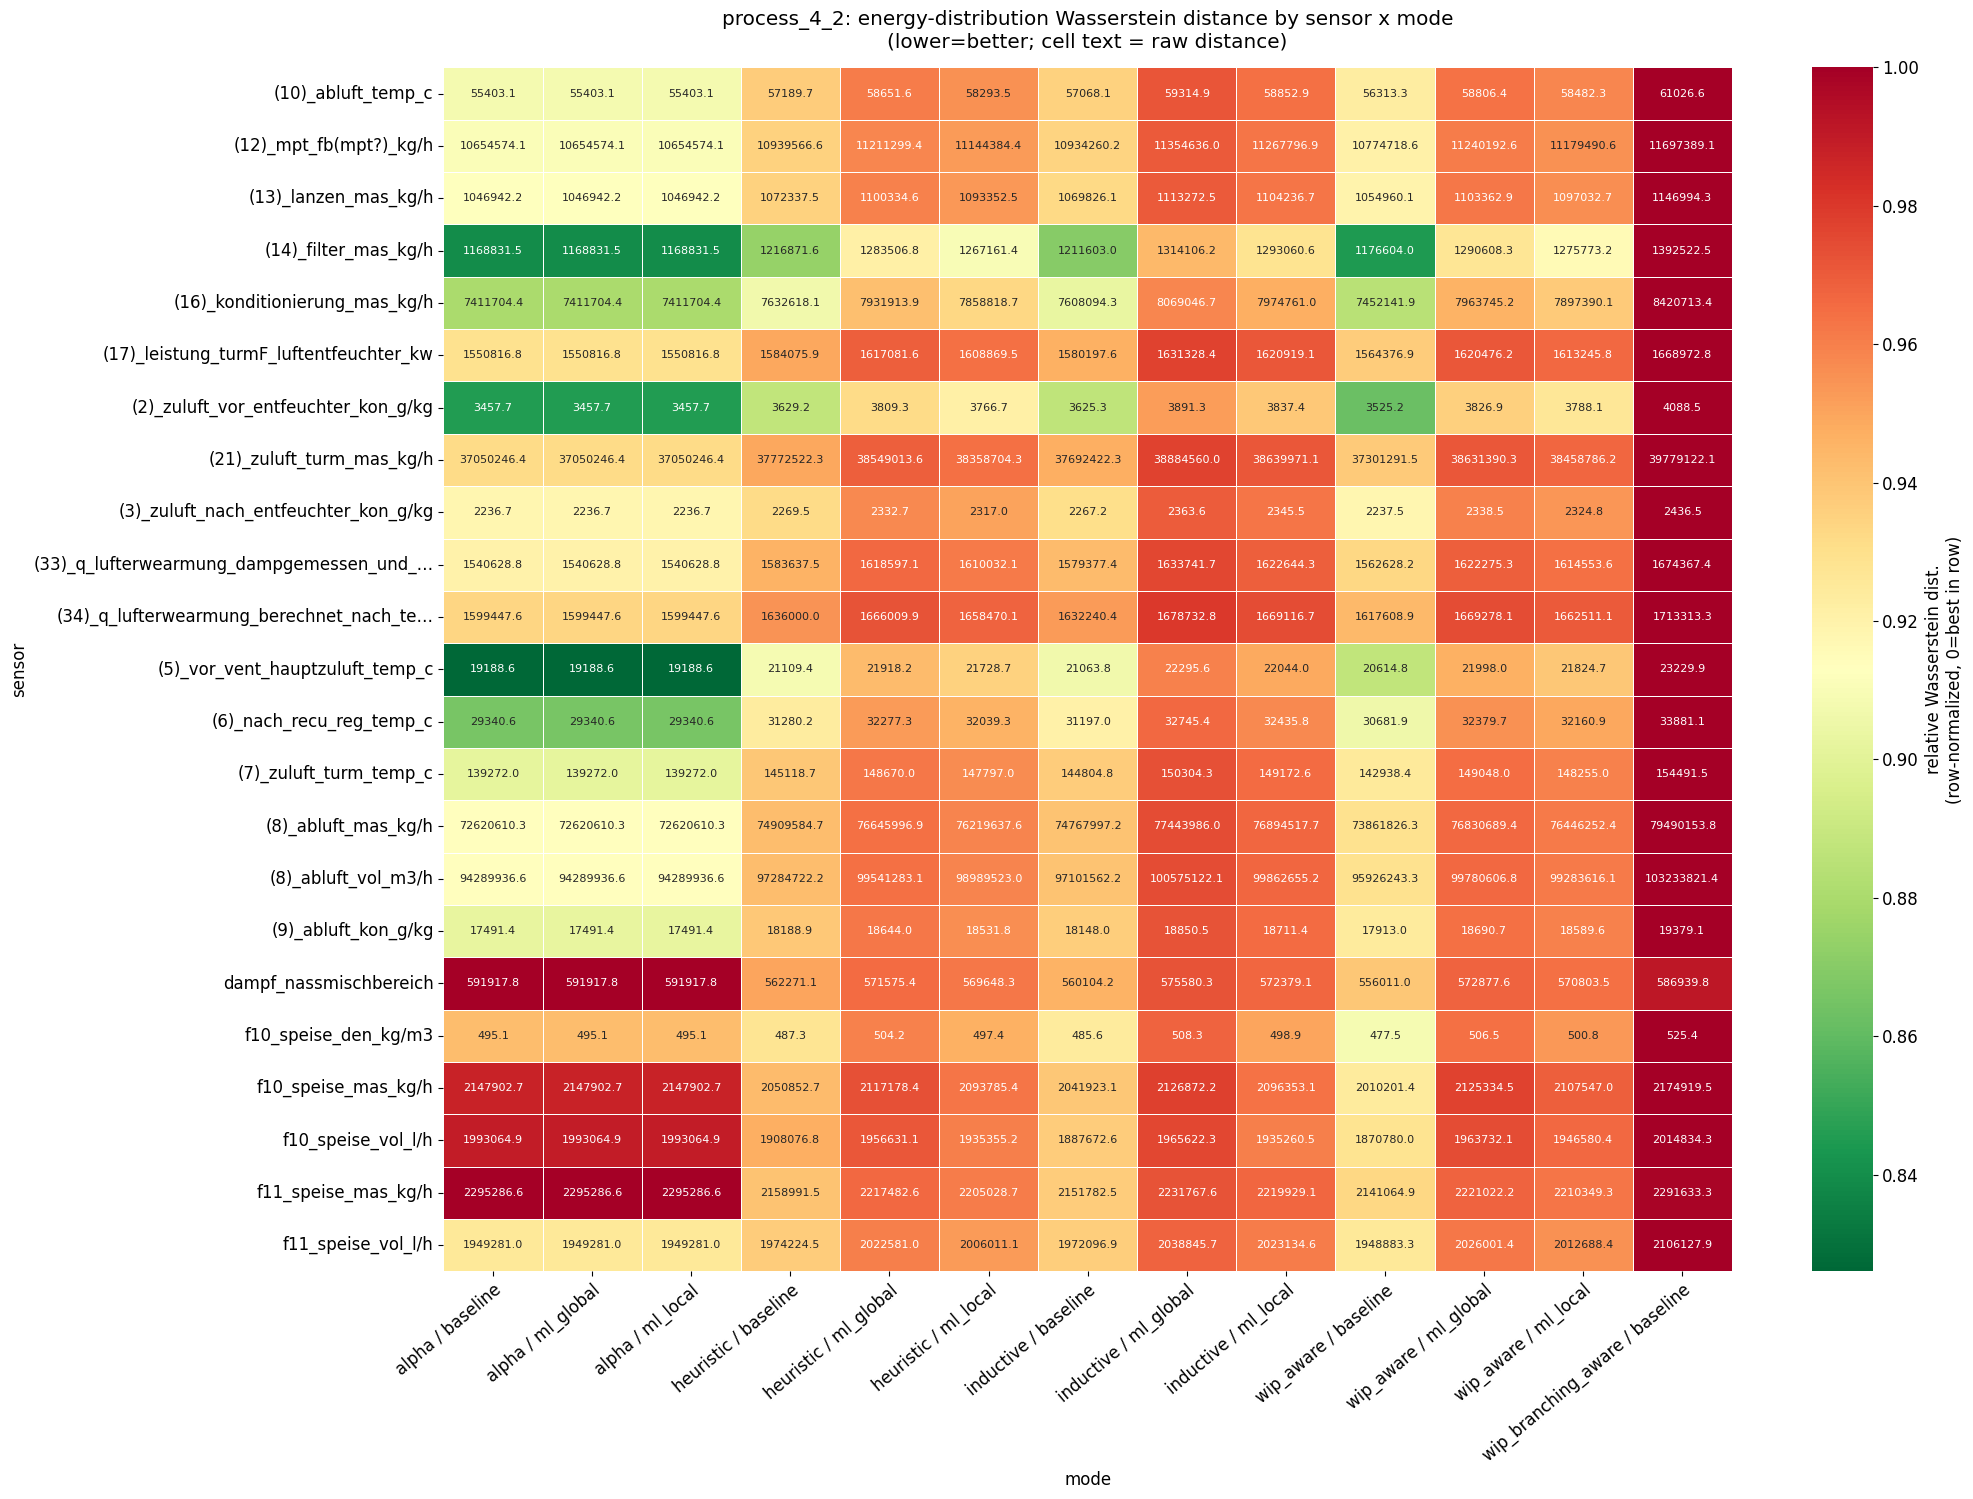

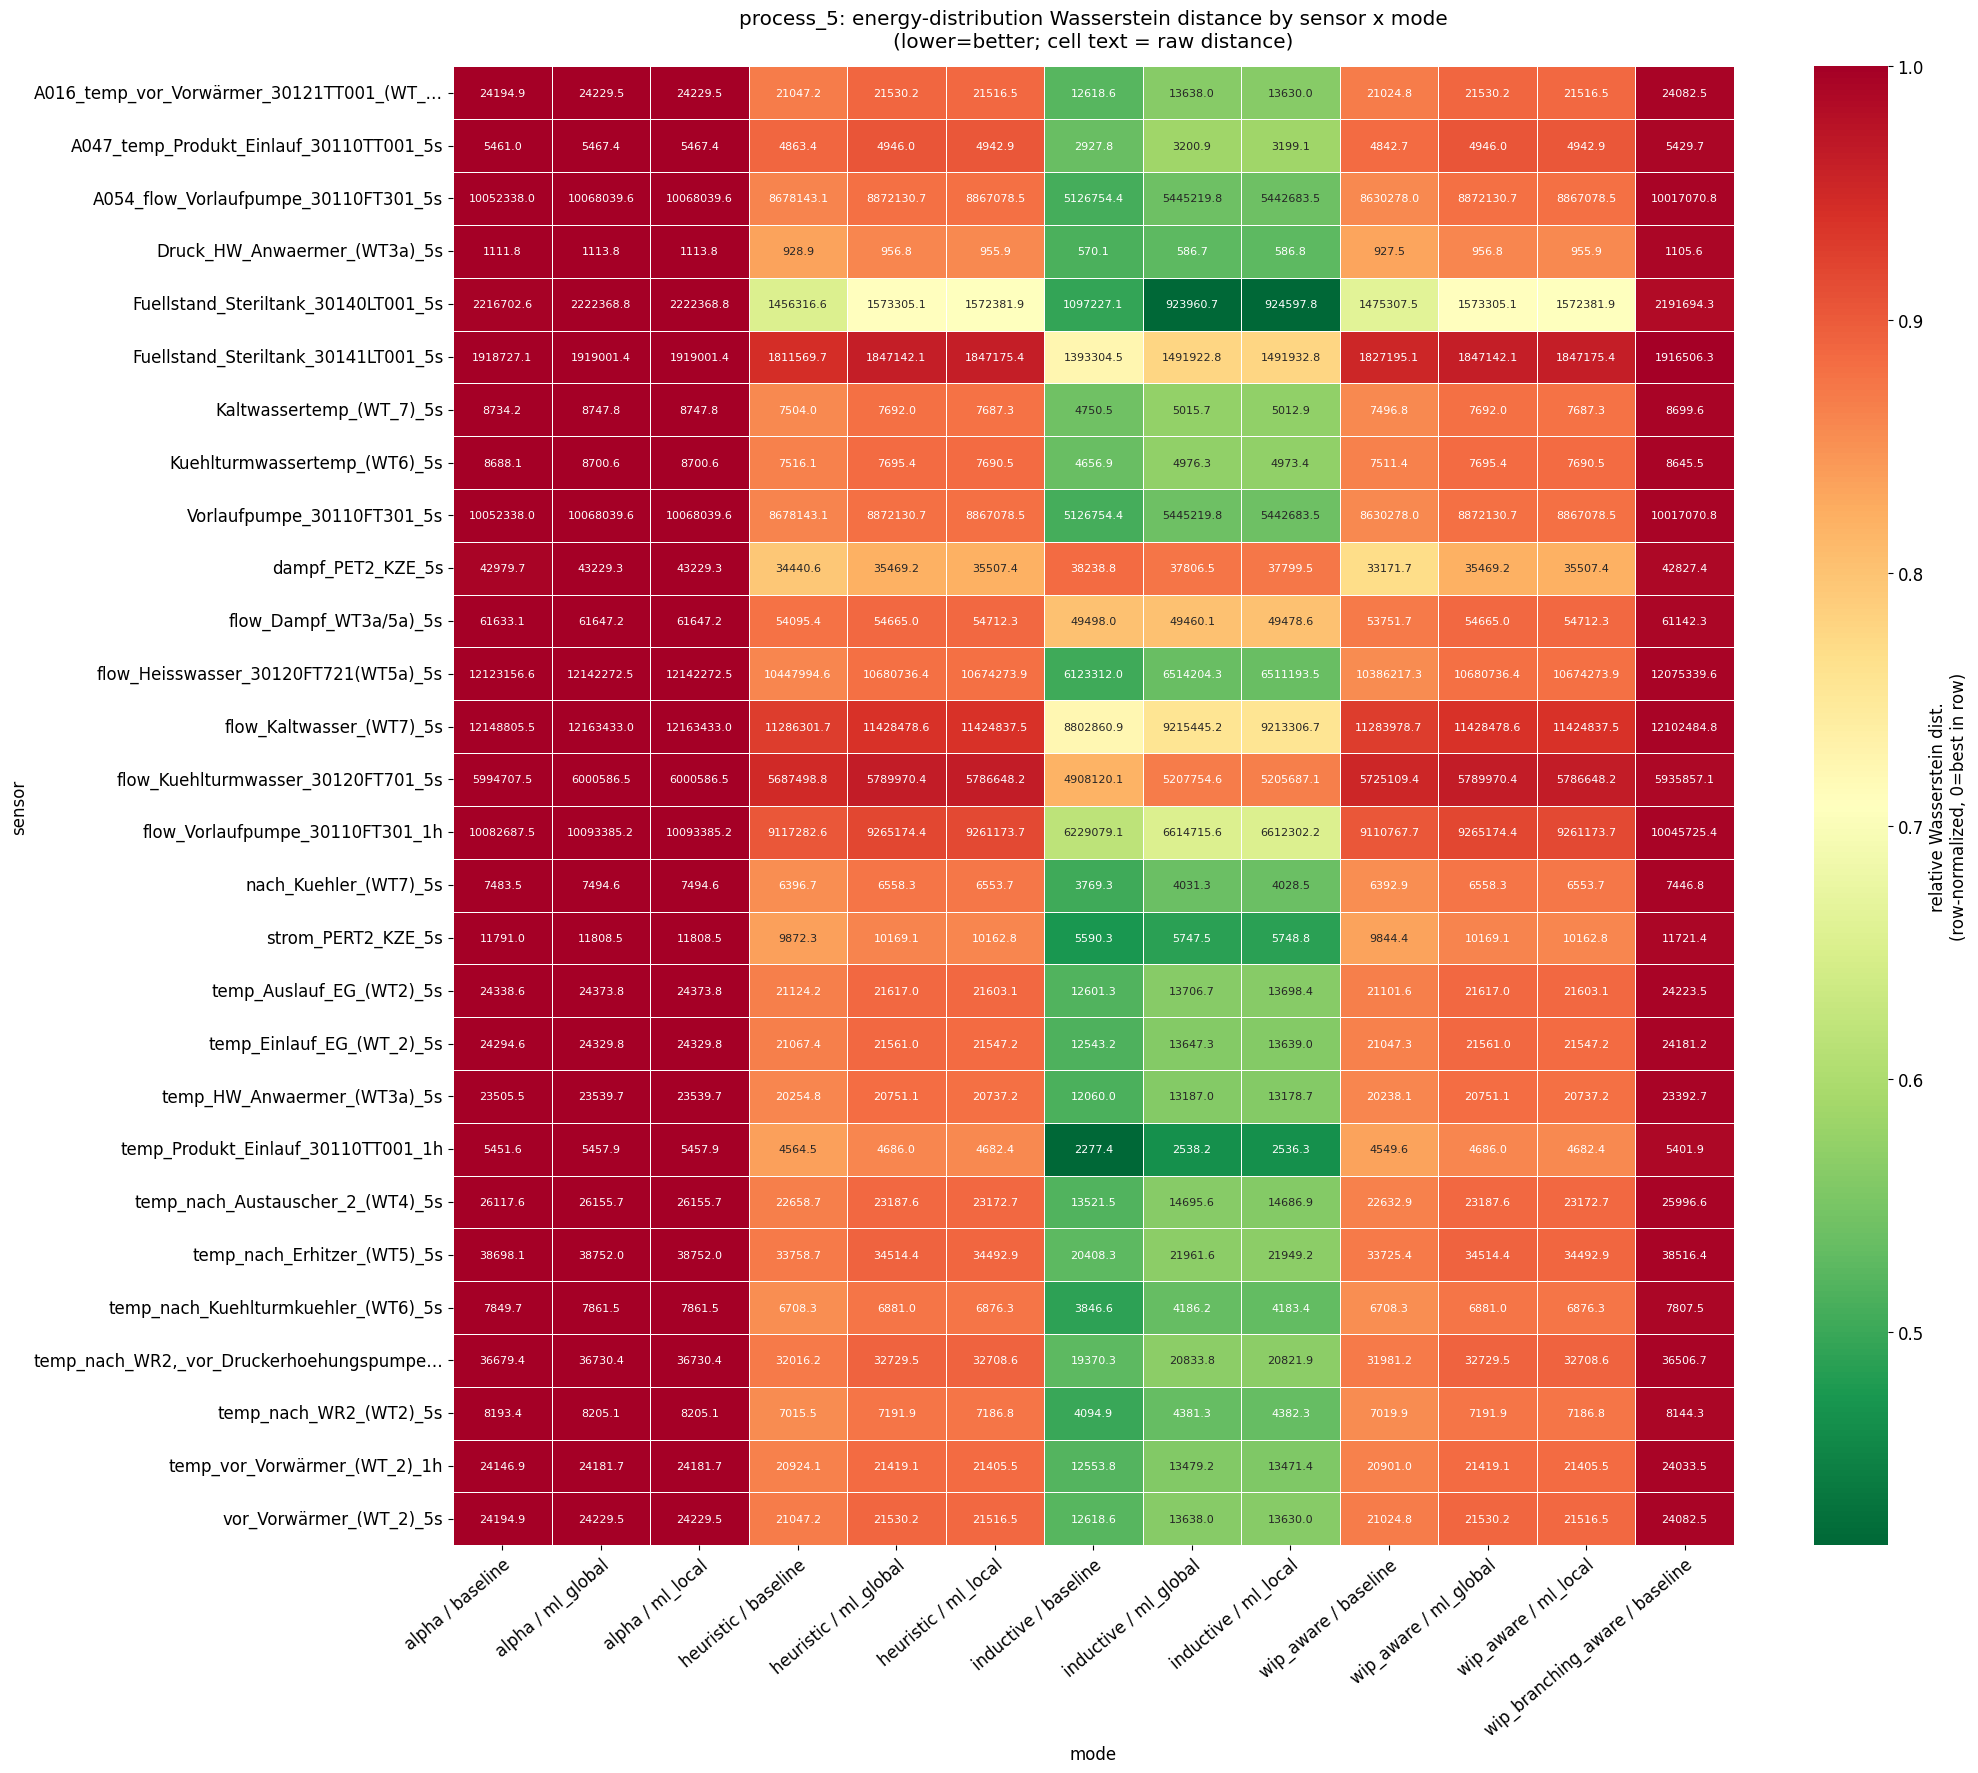

In [23]:
# -- Heatmap: sensor x mode, one per process (same data as the tables above) --
import matplotlib.pyplot as plt
import seaborn as sns

if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    heatmap_dir = run_dir / 'plots'
    heatmap_dir.mkdir(exist_ok=True)

    for proc in sorted(df_energy_dist['process'].unique()):
        sub = df_energy_dist[df_energy_dist['process'] == proc].copy()
        sub['sensor_short'] = sub['sensor'].map(shorten_sensor)
        pivot = sub.pivot_table(index='sensor_short', columns='mode_label', values='wasserstein', aggfunc='first')
        # Row-normalize for color (compares modes within a sensor); raw values shown as annotations.
        pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

        n_rows, n_cols = pivot.shape
        fig_w = max(9, 1.6 * n_cols)
        fig_h = max(4, 0.55 * n_rows) + 2.5   # headroom for title + rotated xticklabels
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        sns.heatmap(
            pivot_norm, annot=pivot.round(1), fmt='', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'relative Wasserstein dist.\n(row-normalized, 0=best in row)'},
            annot_kws={'size': 8}, ax=ax,
        )
        ax.set_title(f'{proc}: energy-distribution Wasserstein distance by sensor x mode\n'
                     '(lower=better; cell text = raw distance)', pad=14)
        ax.set_xlabel('mode'); ax.set_ylabel('sensor')
        plt.setp(ax.get_xticklabels(), rotation=40, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0)
        fig.tight_layout()
        fig.savefig(heatmap_dir / f'energy_dist_heatmap_{proc}.png', dpi=130)
        plt.show()

## Aggregated ranking (one number per process x method)

Rolls the per-sensor Wasserstein distances up to a single **scale-free** number per (process, mode): `relative_wasserstein = wasserstein / real_median`, so a kg/h sensor and a °C sensor can be averaged fairly. Median over sensors per process, then median over processes for `Overall`. Rows sorted best-to-worst.

In [24]:
# -- Aggregate: one relative-Wasserstein number per (process, mode) ----------
if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    df_energy_dist['relative_wasserstein'] = (
        df_energy_dist['wasserstein'] / df_energy_dist['real_median'].abs().replace(0, float('nan'))
    )
    rank_agg = df_energy_dist.groupby(['process', 'mode_label'])['relative_wasserstein'].median().reset_index()
    rank_pivot = rank_agg.pivot(index='mode_label', columns='process', values='relative_wasserstein')
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated energy-distribution ranking, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Median relative Wasserstein distance (Wasserstein / real median) over sensors per process, '
            r'then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best mode per column.'
        ),
        label=f'tab:energy_dist_ranking_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))

\begin{table}[H]
\caption{Aggregated energy-distribution ranking, experiment 929 (test evaluation). Median relative Wasserstein distance (Wasserstein / real median) over sensors per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best mode per column.}
\label{tab:energy\_dist\_ranking\_929\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
mode\_label &  &  &  &  &  &  &  \\
\midrule
inductive / baseline & 0.911 & 0.886 & 1.915 & \textbf{0.827} & 0.881 & \textbf{0.858} & \textbf{0.883} \\
wip\_aware / baseline & 0.912 & \textbf{0.876} & \textbf{1.892} & 0.892 & 0.873 & 1.409 & 0.902 \\
heuristic / baseline & 0.908 & 0.897 & 1.905 & 0.890 & 0.884 & 1.410 & 0.903 \\
inductive / ml\_local & 0.909 & 0.884 & 1.925 & 0.872 & 0.905 & 0.920 & 0.907 \\
inductive / ml\_global & 0.913 & 0.885 & 1.925 & 0.871 & 0.912 & 0.920 

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
mode_label,,,,,,,
inductive / baseline,0.911,0.886,1.915,0.827,0.881,0.858,0.883
wip_aware / baseline,0.912,0.876,1.892,0.892,0.873,1.409,0.902
heuristic / baseline,0.908,0.897,1.905,0.890,0.884,1.410,0.903
inductive / ml_local,0.909,0.884,1.925,0.872,0.905,0.920,0.907
inductive / ml_global,0.913,0.885,1.925,0.871,0.912,0.920,0.913
wip_aware / ml_local,0.908,0.921,1.921,0.899,0.900,1.442,0.915
heuristic / ml_local,0.909,0.921,1.921,0.899,0.897,1.442,0.915
heuristic / ml_global,0.913,0.922,1.923,0.899,0.902,1.443,0.918
wip_aware / ml_global,0.913,0.922,1.923,0.899,0.905,1.443,0.918


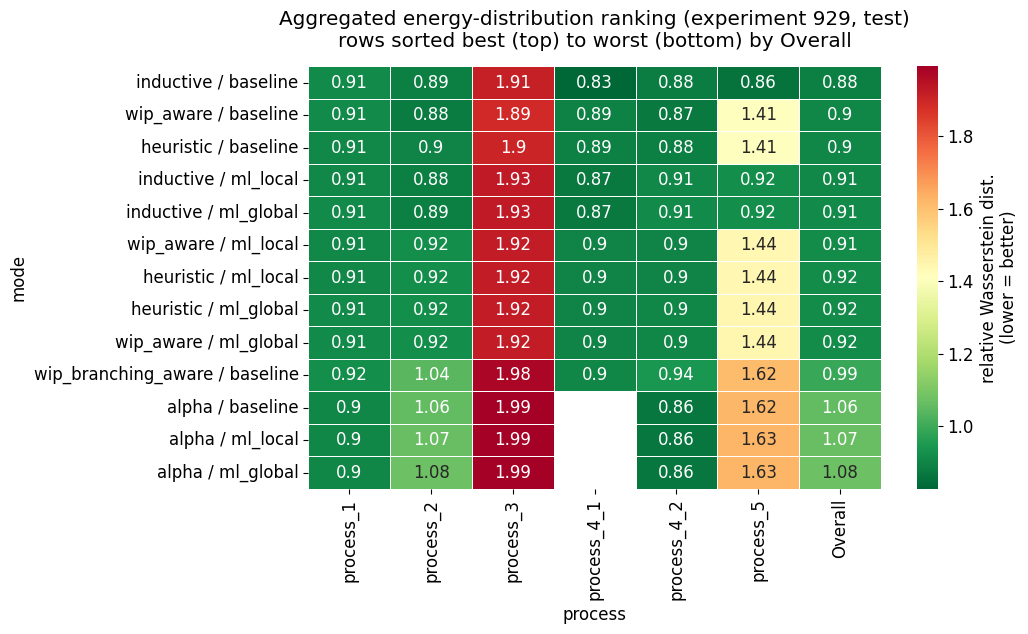

In [25]:
# -- Ranking heatmap: mode (rows, sorted best-to-worst) x process ------------
if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(rank_pivot.columns)), max(3, 0.5 * len(rank_pivot))))
    sns.heatmap(
        rank_pivot, annot=rank_pivot.round(2), fmt='', cmap='RdYlGn_r',
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'relative Wasserstein dist.\n(lower = better)'},
        ax=ax,
    )
    ax.set_title(f'Aggregated energy-distribution ranking (experiment {EXPERIMENT}, {SPLIT})\n'
                 'rows sorted best (top) to worst (bottom) by Overall', pad=14)
    ax.set_xlabel('process'); ax.set_ylabel('mode')
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    fig.savefig(run_dir / 'plots' / 'energy_dist_ranking_heatmap.png', dpi=130)
    plt.show()

## Does process-model quality predict energy-profile quality?

Merges the existing process-fidelity metric (`test_overall_error`, from `process_eval_results.parquet`) with the energy-distribution ranking built above, one point per (process, mode).

**Important caveat, not swept under the rug**: several (process, mode) pairs produce a *numerically identical* simulated schedule as another mode in the same process -- e.g. `wip_aware_ml_plus_global` and `heuristic_ml_plus_global` are mathematically guaranteed to collapse to the same result whenever `MINING_ALGORITHM='heuristic'`, since ML+ duration prediction doesn't use wip/ro at all, and `wip_aware` reuses `MINING_ALGORITHM`'s own net. Including duplicate, non-independent observations inflates the sample size without adding real information, and pulls the correlation toward zero. The cell below detects these duplicates (by comparing each mode's predicted `sim_median` signature per process) and reports the correlation **with and without them** -- report the 'clean' number, not the naive one.

All 75 pairs (naive):        rho=+0.368  p=0.0011
Clean 56 pairs (duplicates removed): rho=+0.490  p=0.0001

19 of 75 pairs flagged as duplicate schedules.


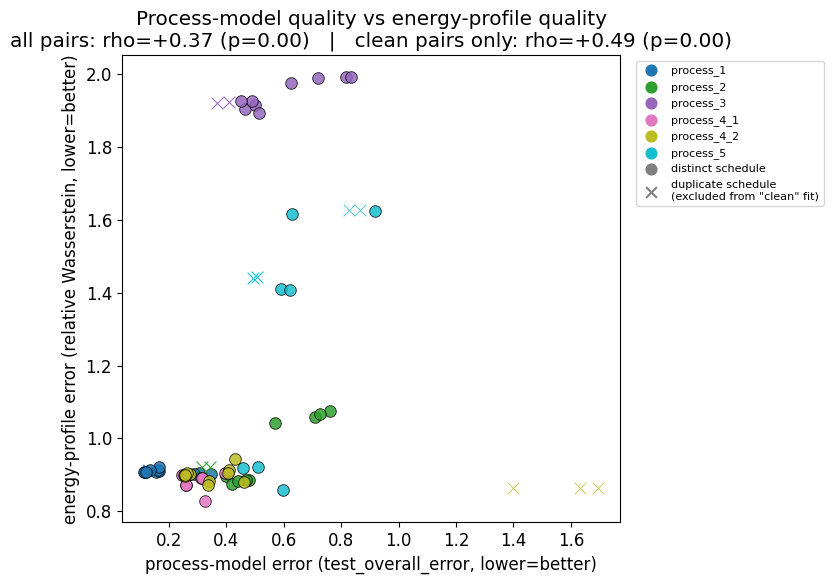

In [26]:
from scipy.stats import spearmanr

# -- process-model quality (already computed earlier as `df`) ---------------
proc_quality = df[['process', 'mode_label', 'test_overall_error']].dropna()

# -- detect duplicate-schedule (process, mode) pairs --------------------------
sig_rows = []
for proc_dir in sorted(energy_dist_dir.iterdir()):
    if not proc_dir.is_dir():
        continue
    for mode_dir in sorted(proc_dir.iterdir()):
        if not mode_dir.is_dir():
            continue
        csv_path = mode_dir / 'per_case_sensor_total.csv'
        core_path = mode_dir / 'core_metrics.csv'
        if not csv_path.exists():
            continue
        sensor_df = pd.read_csv(csv_path)
        mode_name = mode_dir.name
        if core_path.exists():
            core_df = pd.read_csv(core_path)
            if 'mode' in core_df.columns and len(core_df) > 0:
                mode_name = core_df['mode'].iloc[0]
        sig_rows.append({
            'process': proc_dir.name, 'mode': mode_name,
            'sig': tuple(sensor_df.sort_values('sensor')['sim_median'].round(3)),
        })
sig_df = pd.DataFrame(sig_rows)
sig_df['is_duplicate'] = sig_df.duplicated(subset=['process', 'sig'], keep=False)
sig_df['mode_label'] = sig_df['mode'].map(display_mode)

# -- energy-profile quality (reuse from the aggregated-ranking cell) ---------
corr_merged = proc_quality.merge(rank_agg, on=['process', 'mode_label'], how='inner')
corr_merged = corr_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
clean = corr_merged[~corr_merged['is_duplicate']]

rho_all, p_all = spearmanr(corr_merged['test_overall_error'], corr_merged['relative_wasserstein'])
rho_clean, p_clean = spearmanr(clean['test_overall_error'], clean['relative_wasserstein'])
print(f'All {len(corr_merged)} pairs (naive):        rho={rho_all:+.3f}  p={p_all:.4f}')
print(f'Clean {len(clean)} pairs (duplicates removed): rho={rho_clean:+.3f}  p={p_clean:.4f}')
print(f'\n{corr_merged["is_duplicate"].sum()} of {len(corr_merged)} pairs flagged as duplicate schedules.')

# -- scatter plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
processes_c = sorted(corr_merged['process'].unique())
colors_c = plt.cm.tab10(np.linspace(0, 1, len(processes_c)))
proc_color = dict(zip(processes_c, colors_c))
for _, r in corr_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color[r['process']], marker=marker, s=70,
               edgecolors=('black' if not r['is_duplicate'] else None), linewidths=0.6, alpha=0.85)
for proc in processes_c:
    ax.scatter([], [], color=proc_color[proc], label=proc, s=60)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=60)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule\n(excluded from "clean" fit)', s=60)
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality\n'
             f'all pairs: rho={rho_all:+.2f} (p={p_all:.2f})   |   '
             f'clean pairs only: rho={rho_clean:+.2f} (p={p_clean:.2f})')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter.png', dpi=130)
plt.show()

### The raw check, side by side

Full table behind the correlation above: one row per (process, mode), process-quality score, energy-quality score, and whether that row's simulated schedule is a duplicate of another mode's in the same process (both scores lower = better). Look at `process_1`: six rows share the exact same `energy_error` (0.9516...) despite different `process_error` values -- that's six "different modes" that produced the literal same simulated schedule, which is why they're excluded from the clean check.

In [27]:
# -- Full side-by-side table + both checks -----------------------------------
display_table = corr_merged.rename(
    columns={'test_overall_error': 'process_error', 'relative_wasserstein': 'energy_error'}
).sort_values(['process', 'energy_error'])[
    ['process', 'mode_label', 'process_error', 'energy_error', 'is_duplicate']
]
print('=== FULL TABLE: every (process, mode) pair used in the check ===')
display(display_table)

print(f'\n=== CHECK 1: naive, all {len(corr_merged)} pairs (duplicates included) ===')
print(f'rho={rho_all:+.3f}  p={p_all:.4f}   -> {"significant" if p_all < 0.05 else "NOT significant"}')

print(f'\n=== CHECK 2: clean, {len(clean)} pairs ({corr_merged["is_duplicate"].sum()} duplicates removed) ===')
print(f'rho={rho_clean:+.3f}  p={p_clean:.4f}   -> {"significant" if p_clean < 0.05 else "NOT significant"}')

print(f'\n=== The {corr_merged["is_duplicate"].sum()} duplicate rows removed for Check 2 ===')
display(
    corr_merged[corr_merged['is_duplicate']]
    .rename(columns={'test_overall_error': 'process_error', 'relative_wasserstein': 'energy_error'})
    .sort_values(['process', 'mode_label'])[['process', 'mode_label', 'process_error', 'energy_error']]
)

=== FULL TABLE: every (process, mode) pair used in the check ===


,process,mode_label,process_error,energy_error,is_duplicate
6,process_1,alpha / ml_local,0.285431,0.902473,False
0,process_1,alpha / baseline,0.347532,0.902579,False
5,process_1,alpha / ml_global,0.305265,0.904673,False
12,process_1,wip_aware / ml_local,0.118852,0.908082,False
1,process_1,heuristic / baseline,0.153555,0.908298,False
...,...,...,...,...,...
73,process_5,wip_aware / ml_global,0.508048,1.442539,True
66,process_5,wip_branching_aware / baseline,0.627151,1.615236,False
62,process_5,alpha / baseline,0.915887,1.623409,False
67,process_5,alpha / ml_global,0.864163,1.625799,True



=== CHECK 1: naive, all 75 pairs (duplicates included) ===
rho=+0.368  p=0.0011   -> significant

=== CHECK 2: clean, 56 pairs (19 duplicates removed) ===
rho=+0.490  p=0.0001   -> significant

=== The 19 duplicate rows removed for Check 2 ===


,process,mode_label,process_error,energy_error
7,process_1,heuristic / ml_global,0.131822,0.913127
11,process_1,wip_aware / ml_global,0.125918,0.913127
20,process_2,heuristic / ml_global,0.343896,0.921984
21,process_2,heuristic / ml_local,0.314426,0.921331
24,process_2,wip_aware / ml_global,0.344382,0.921984
25,process_2,wip_aware / ml_local,0.314911,0.921331
33,process_3,heuristic / ml_global,0.408108,1.922863
34,process_3,heuristic / ml_local,0.365789,1.920769
37,process_3,wip_aware / ml_global,0.407967,1.922863
38,process_3,wip_aware / ml_local,0.365448,1.920769


## Same check, but per (process, mode, sensor) -- not aggregated per process

The scatter above collapsed every sensor within a (process, mode) down to one median point (40 dots, 26 after removing duplicates). This version keeps every sensor as its own point instead -- ~536 dots across all processes together, plotted on one shared scatter (log scale on the y-axis, since relative Wasserstein distance spans several orders of magnitude across sensors). Same duplicate-schedule exclusion as before, same process_error x-axis. More points, more noise visible, but also much higher statistical power -- the correlation holds (and is stronger) even without removing duplicates.

All (process, mode, sensor) points: n=1105  rho=+0.381  p=1.362e-39
Clean (non-duplicate) points:       n=814  rho=+0.424  p=7.951e-37


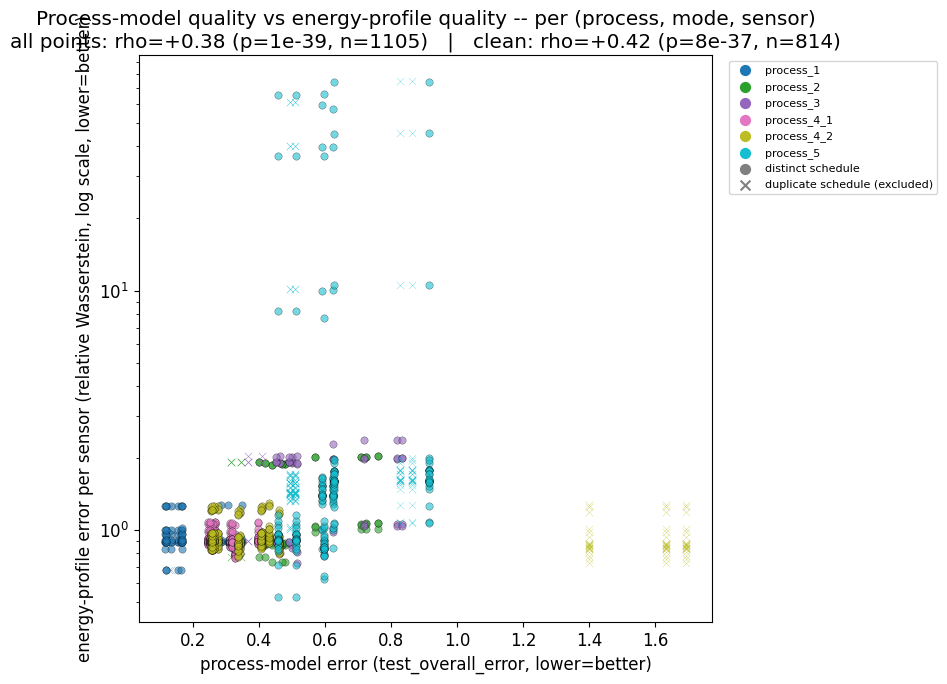

In [28]:
# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])
instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))
for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), linewidths=0.3, alpha=0.6)
for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)
ax.set_yscale('log')
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, log scale, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()

All (process, mode, sensor) points: n=1105  rho=+0.381  p=1.362e-39
Clean (non-duplicate) points:       n=814  rho=+0.424  p=7.951e-37


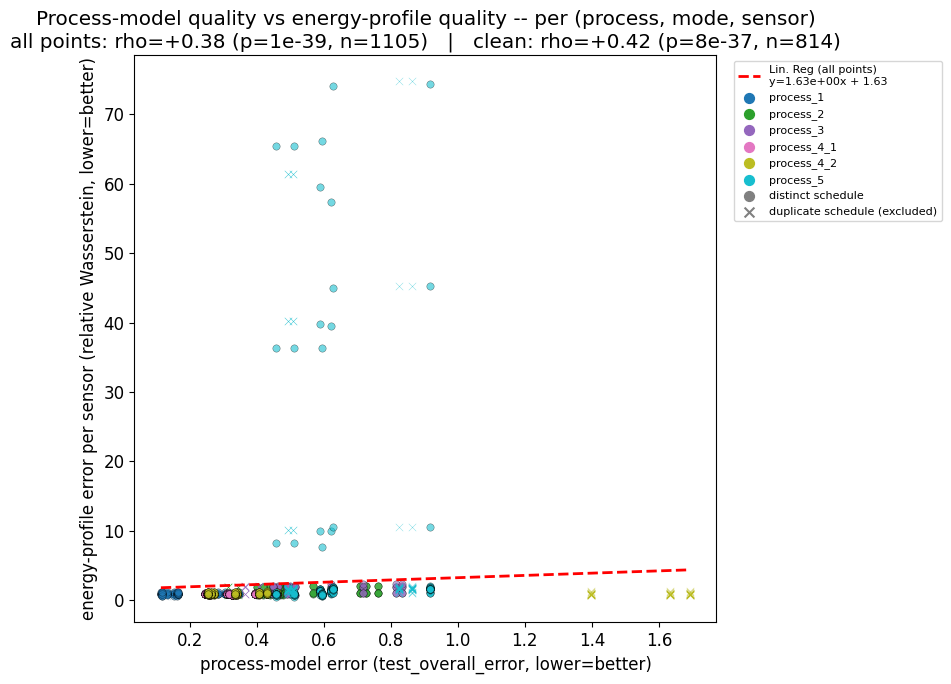

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])
instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

# --- Calculate Linear Regression over ALL points ---
x_all = instance_merged['test_overall_error']
y_all = instance_merged['relative_wasserstein']
slope, intercept, r_value, p_value, std_err = linregress(x_all, y_all)

# Generate points for the regression line
x_line = np.linspace(x_all.min(), x_all.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))

for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), 
               linewidths=0.3, alpha=0.6, zorder=2)

# --- Plot the Linear Regression Line ---
ax.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, zorder=10, 
        label=f'Lin. Reg (all points)\ny={slope:.2e}x + {intercept:.2f}')

for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)

# Log scale removed entirely
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')

ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()

All (process, mode, sensor) points: n=1079  rho=+0.364  p=3.342e-35
Clean (non-duplicate) points:       n=800  rho=+0.402  p=2.346e-32


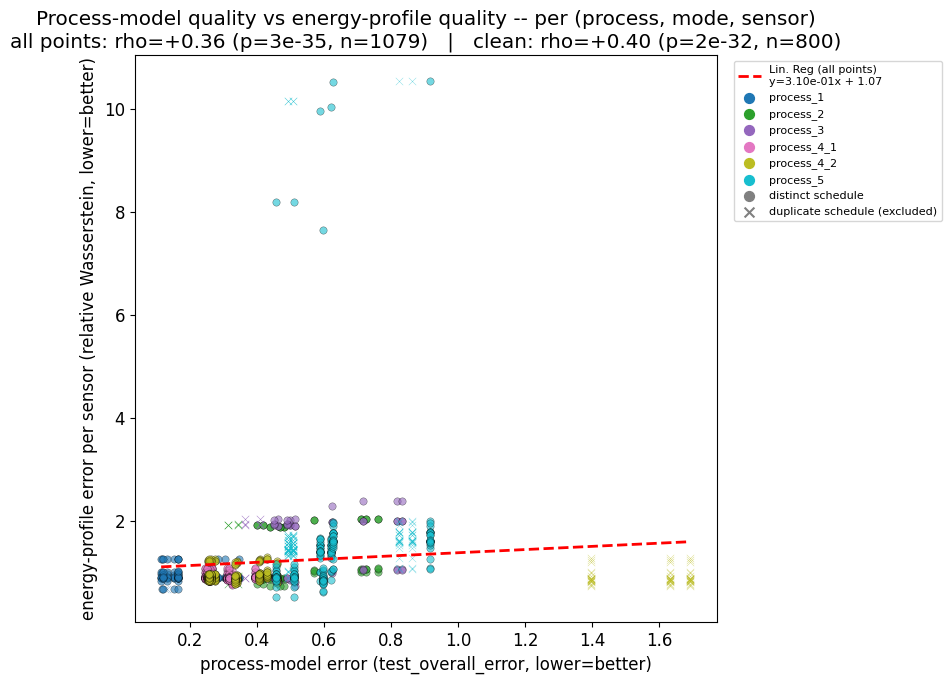

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])

# --- FILTER: Remove points above 20 for both axes ---
instance_merged = instance_merged[
    (instance_merged['test_overall_error'] <= 20) & 
    (instance_merged['relative_wasserstein'] <= 20)
]

instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

# --- Calculate Linear Regression over ALL points ---
x_all = instance_merged['test_overall_error']
y_all = instance_merged['relative_wasserstein']
slope, intercept, r_value, p_value, std_err = linregress(x_all, y_all)

# Generate points for the regression line
x_line = np.linspace(x_all.min(), x_all.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))

for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), 
               linewidths=0.3, alpha=0.6, zorder=2)

# --- Plot the Linear Regression Line ---
ax.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, zorder=10, 
        label=f'Lin. Reg (all points)\ny={slope:.2e}x + {intercept:.2f}')

for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)

# Log scale removed entirely
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')

ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()

# Complete-Curve Evaluation (per-case, shift-tolerant Wasserstein)

New, additional evaluation -- does not replace anything above. For every real test case, matched to its same-`case_id` counterpart in each simulated log, this:

1. Concatenates the case's real per-activity sensor curves (in real time order) into one complete real profile.
2. Predicts each of that case's activities' curves with the trained `baseline` (median/barycenter per activity) and `exog_prev_activity` ("DTW + Ext. Factors + Prev Act", the strongest curve-fitting approach) pipelines, using the simulated log's own activities/durations, and concatenates them into one complete simulated profile for the same case.
3. Compares the two complete profiles with two Wasserstein (Earth Mover's) distances along orthogonal axes, instead of a single mean/total summary stat (which a trivial "predict the mean everywhere" model could win without getting anything useful right):
   - **W1 (time)** -- curve values as weights, case-relative time as the transport axis. Answers "is the timing/shape right." Order-sensitive; blind to overall magnitude (a right-shaped-but-30%-too-high curve still scores well here, since W1 normalises each curve to the same total mass before comparing).
   - **W1 (value)** -- raw curve values as the transport axis, unweighted. Answers "is the distribution of magnitudes right" -- catches scale *and* spread/variance errors. Order-blind (doesn't know *when* a value occurred), so it's exactly complementary to W1 (time). Works uniformly for intensive sensors (temperature, concentration) and extensive ones (power, flow), since nothing is summed or averaged before comparing.

A model can't fool both at once: winning W1 (value) by predicting a flat mean loses badly on W1 (time), since all its mass then sits in the wrong place in time.

Source: `complete_curve_eval_results/<process>/<mode>/complete_curve_summary[_exog_prev_activity].csv`, populated per (process, mode, approach) when the pipeline runs with `run_energy_modelling=True`. If it's missing, re-run the pipeline after this modelling.py update.


In [31]:
# -- Load complete-curve evaluation results (per-case, shift-tolerant Wasserstein) --
# Discovers every approach that has a complete_curve_summary*.csv in a mode folder
# (complete-curve eval runs against every trained non-seq2seq approach, not just
# baseline + exog_prev_activity -- see modelling.py's COMPLETE-CURVE EVAL block),
# rather than assuming a fixed pair.
#
# Two Wasserstein distances along two orthogonal axes, not a mean/total summary
# stat: wasserstein_time (values as weights, time as the transport axis -- is the
# timing/shape right) and wasserstein_value (raw values as the transport axis,
# unweighted -- is the distribution of magnitudes right). Neither can be gamed by
# a trivial "predict the mean everywhere" model: that scores badly on
# wasserstein_time (all its mass sits in the wrong place in time) and on
# wasserstein_value (zero variance vs. the real curve's actual spread). Works
# uniformly for intensive (temperature) and extensive (power, flow) sensors alike,
# since nothing is summed or averaged before comparing.
complete_curve_dir = run_dir / 'complete_curve_eval_results'

if not complete_curve_dir.exists():
    print(f'Not found: {complete_curve_dir}\n(run the pipeline with run_energy_modelling=True to generate it)')
    df_complete_curve = pd.DataFrame()
else:
    rows = []
    for proc_dir in sorted(complete_curve_dir.iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            if not mode_dir.is_dir():
                continue
            for summary_path in sorted(mode_dir.glob('complete_curve_summary*.csv')):
                # 'complete_curve_summary.csv' -> baseline; '..._<approach>.csv' -> <approach>
                _stem = summary_path.stem  # 'complete_curve_summary' or 'complete_curve_summary_<approach>'
                _suffix = _stem[len('complete_curve_summary'):]
                approach = _suffix[1:] if _suffix.startswith('_') else 'baseline'

                summ = pd.read_csv(summary_path)
                if summ.empty:
                    continue
                mode_name = summ['mode'].iloc[0] if 'mode' in summ.columns else mode_dir.name
                for _, r in summ.iterrows():
                    rows.append({
                        'process':                   proc_dir.name,
                        'mode':                      mode_name,
                        'approach':                  approach,
                        'sensor':                    r['sensor'],
                        'wasserstein_time_median':   r['wasserstein_time_median'],
                        'wasserstein_value_median':  r.get('wasserstein_value_median'),
                        'n_cases':                   r['n_cases'],
                    })
    df_complete_curve = pd.DataFrame(rows)

print(f'{len(df_complete_curve)} (process, mode, approach, sensor) rows loaded')
if not df_complete_curve.empty:
    print(f'Approaches found: {sorted(df_complete_curve["approach"].unique())}')
df_complete_curve.head(20)


3282 (process, mode, approach, sensor) rows loaded
Approaches found: ['baseline', 'exog_prev_activity', 'ml_dtw_linear_decode']


,process,mode,approach,sensor,wasserstein_time_median,wasserstein_value_median,n_cases
0,process_1,petri_net_alpha,baseline,bottling_power_kW_energy_to_model,8.267801,0.183619,120
1,process_1,petri_net_alpha,baseline,destillation_cooling_demand_kW_energy_to_model,4.719544,805.157732,120
2,process_1,petri_net_alpha,baseline,destillation_steam_demand_kW_energy_to_model,4.310248,789.885895,120
3,process_1,petri_net_alpha,baseline,individual_packaging_power_kW_energy_to_model,108.998945,1.443084,106
4,process_1,petri_net_alpha,exog_prev_activity,bottling_power_kW_energy_to_model,8.153732,0.216983,120
5,process_1,petri_net_alpha,exog_prev_activity,destillation_cooling_demand_kW_energy_to_model,4.622957,822.569324,120
6,process_1,petri_net_alpha,exog_prev_activity,destillation_steam_demand_kW_energy_to_model,4.344353,805.204439,120
7,process_1,petri_net_alpha,exog_prev_activity,individual_packaging_power_kW_energy_to_model,108.202139,1.298836,106
8,process_1,petri_net_alpha,ml_dtw_linear_decode,bottling_power_kW_energy_to_model,8.267801,0.192677,120
9,process_1,petri_net_alpha,ml_dtw_linear_decode,destillation_cooling_demand_kW_energy_to_model,4.667574,805.257227,120


In [32]:
# -- Scale-free versions of the two complete-curve Wasserstein metrics --
# wasserstein_time_median is in minutes and wasserstein_value_median is in the
# sensor's own raw units -- neither is comparable across sensors of different
# scale (a kg/h sensor vs. a kW sensor, a short-cycle process vs. a long one),
# so aggregating them across sensors (as the combined table below does) lets
# whichever sensor has the largest units/duration dominate the median. Fix,
# mirroring the relative_wasserstein trick used for the pooled energy-
# distribution metric above: divide each by a real, model-independent scale
# reference for that (process, sensor) --
#   relative_wasserstein_time  = wasserstein_time_median  / real median case duration (minutes)
#   relative_wasserstein_value = wasserstein_value_median / real per-case-mean median (same raw units)
# Note: the pooled *instantaneous* value median (per_sensor_pooled_values.csv)
# is often exactly 0 for intermittent sensors (idle most of the time), which
# would blow up the ratio -- per_case_sensor_mean.csv's real_median (median of
# each case's own mean value) stays a well-behaved nonzero denominator.
if not df_complete_curve.empty:
    case_duration_min = {}
    for proc in df_complete_curve['process'].unique():
        log_path = run_dir / 'predicted_logs' / f'{proc}_test_set.parquet'
        if not log_path.exists():
            continue
        log_df = pd.read_parquet(log_path, columns=['case_id', 'timestamp_start', 'timestamp_end'])
        case_ends = log_df.groupby('case_id')['timestamp_end'].max()
        case_starts = log_df.groupby('case_id')['timestamp_start'].min()
        durations = (case_ends - case_starts).dt.total_seconds() / 60.0
        case_duration_min[proc] = durations.median()

    real_val_median = {}
    for proc_dir in sorted((run_dir / 'energy_distribution_results').iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            csv_path = mode_dir / 'per_case_sensor_mean.csv'
            if not csv_path.exists():
                continue
            pooled_df = pd.read_csv(csv_path)
            for _, r in pooled_df.iterrows():
                real_val_median.setdefault((proc_dir.name, r['sensor']), r['real_median'])

    df_complete_curve['case_duration_median_min'] = df_complete_curve['process'].map(case_duration_min)
    df_complete_curve['real_value_median'] = df_complete_curve.apply(
        lambda r: real_val_median.get((r['process'], r['sensor'])), axis=1
    )
    df_complete_curve['relative_wasserstein_time'] = (
        df_complete_curve['wasserstein_time_median']
        / df_complete_curve['case_duration_median_min'].replace(0, float('nan'))
    )
    df_complete_curve['relative_wasserstein_value'] = (
        df_complete_curve['wasserstein_value_median']
        / df_complete_curve['real_value_median'].abs().replace(0, float('nan'))
    )

    print('Relative (scale-free) complete-curve metrics added.')
    display(df_complete_curve[['process', 'mode', 'approach', 'sensor',
                               'wasserstein_time_median', 'relative_wasserstein_time',
                               'wasserstein_value_median', 'relative_wasserstein_value']].head(20))
else:
    print('Nothing to show -- df_complete_curve is empty.')

Relative (scale-free) complete-curve metrics added.


,process,mode,approach,sensor,wasserstein_time_median,relative_wasserstein_time,wasserstein_value_median,relative_wasserstein_value
0,process_1,petri_net_alpha,baseline,bottling_power_kW_energy_to_model,8.267801,0.064755,0.183619,0.105793
1,process_1,petri_net_alpha,baseline,destillation_cooling_demand_kW_energy_to_model,4.719544,0.036964,805.157732,4.574539
2,process_1,petri_net_alpha,baseline,destillation_steam_demand_kW_energy_to_model,4.310248,0.033759,789.885895,6.344072
3,process_1,petri_net_alpha,baseline,individual_packaging_power_kW_energy_to_model,108.998945,0.853702,1.443084,0.621952
4,process_1,petri_net_alpha,exog_prev_activity,bottling_power_kW_energy_to_model,8.153732,0.063862,0.216983,0.125015
5,process_1,petri_net_alpha,exog_prev_activity,destillation_cooling_demand_kW_energy_to_model,4.622957,0.036208,822.569324,4.673463
6,process_1,petri_net_alpha,exog_prev_activity,destillation_steam_demand_kW_energy_to_model,4.344353,0.034026,805.204439,6.467105
7,process_1,petri_net_alpha,exog_prev_activity,individual_packaging_power_kW_energy_to_model,108.202139,0.847461,1.298836,0.559783
8,process_1,petri_net_alpha,ml_dtw_linear_decode,bottling_power_kW_energy_to_model,8.267801,0.064755,0.192677,0.111011
9,process_1,petri_net_alpha,ml_dtw_linear_decode,destillation_cooling_demand_kW_energy_to_model,4.667574,0.036557,805.257227,4.575104


In [ ]:
# -- COMBINED TABLE: process metrics + complete-curve columns (Baseline vs DTW+ML+Ext.Factors) --
# Same row structure as the main process-results table: rows = (process, process model, duration pred).
# Two extra column groups per approach: W1 (time), rel. [is the timing/shape right,
# as a fraction of typical case duration] and W1 (value), rel. [is the distribution
# of magnitudes right, as a fraction of the sensor's real typical scale] -- for the
# Baseline and the exog_prev_activity ("DTW + ML + Ext. Factors") approach.
# Uses the scale-free relative_wasserstein_* columns (see the cell above) rather
# than the raw wasserstein_time_median/wasserstein_value_median -- those are in
# minutes / raw sensor units respectively, so a straight median across sensors of
# different units or case-length scales would just be dominated by whichever
# sensor happens to have the largest numbers, not by which mode/approach is best.
# Respects SHOW_ALL_PROCESS_MODELS (set in the process-results table cell above):
# False -> alpha + single best algo per process; True -> every process-model family.

if df_complete_curve.empty:
    print('Nothing to show -- df_complete_curve is empty.')
else:
    _cc_metrics = ['relative_wasserstein_time', 'relative_wasserstein_value']

    _cc_lkp = (
        df_complete_curve
        .groupby(['process', 'mode', 'approach'])[_cc_metrics]
        .median()
    )

    _pe_cc = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _ba_cc = {}
    for _pc in processes:
        _ba_cc[_pc] = pick_best_algo(_pe_cc[_pe_cc['process'] == _pc], split_prefix)

    def _label_to_simmode_cc(pmodel_lbl, dpred_lbl):
        if 'alpha' in pmodel_lbl:
            return 'petri_net_alpha'
        algo = pmodel_lbl.replace(' petri net', '').replace(' ', '_')
        if 'ml_local' in dpred_lbl:
            return f'petri_net_{algo}_ml_plus_per_act'
        if 'ml_global' in dpred_lbl:
            return f'petri_net_{algo}_ml_plus_global'
        return f'petri_net_{algo}'

    def _cc_vals(proc, sim_mode, approach):
        try:
            row = _cc_lkp.loc[(proc, sim_mode, approach)]
            return {m: row[m] for m in _cc_metrics}
        except KeyError:
            return {m: float('nan') for m in _cc_metrics}

    _cc_frames = []
    for proc in processes:
        sub_pe = _pe_cc[_pe_cc['process'] == proc]
        ba = _ba_cc[proc]

        if SHOW_ALL_PROCESS_MODELS:
            modes_to_show = ['petri_net_alpha']
            for algo in ALGO_FAMILIES:
                modes_to_show += [f'petri_net_{algo}', f'petri_net_{algo}_ml_plus_global', f'petri_net_{algo}_ml_plus_per_act']
            sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
            sub_pe['mode_label'] = sub_pe['mode'].apply(
                lambda m: make_mode_label(m, 'alpha' if m.startswith('petri_net_alpha') else _algo_for_mode(m))
            )
            row_order = []
            for algo in ALGO_FAMILIES:
                pn = f"{algo.replace('_', ' ')} petri net"
                row_order += [f'{pn} / ml_local', f'{pn} / ml_global', f'{pn} / baseline']
            row_order.append('alpha petri net / baseline')
        else:
            pn = f'{ba} petri net'
            modes_to_show = ['petri_net_alpha', f'petri_net_{ba}',
                             f'petri_net_{ba}_ml_plus_global', f'petri_net_{ba}_ml_plus_per_act']
            sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
            sub_pe['mode_label'] = sub_pe['mode'].apply(lambda m: make_mode_label(m, ba))
            row_order = [f'{pn} / ml_local', f'{pn} / ml_global',
                         f'{pn} / baseline', 'alpha petri net / baseline']

        sub_pe = sub_pe.set_index('mode_label')[metric_cols]
        sub_pe = sub_pe.reindex([r for r in row_order if r in sub_pe.index])
        sub_pe.columns = [METRIC_LABELS.get(c, c) for c in sub_pe.columns]

        for _ck, _ctag in [('baseline', 'Baseline'), ('exog_prev_activity', 'Best')]:
            for _m in _cc_metrics:
                sub_pe[f'{_m} ({_ctag})'] = float('nan')

        for row_lbl in sub_pe.index:
            _pml, _dpl = split_mode(row_lbl)
            _sm = _label_to_simmode_cc(_pml, _dpl)
            for _ck, _ctag in [('baseline', 'Baseline'), ('exog_prev_activity', 'Best')]:
                _cv = _cc_vals(proc, _sm, _ck)
                for _m, _v in _cv.items():
                    sub_pe.loc[row_lbl, f'{_m} ({_ctag})'] = _v

        _pml_arr, _dpl_arr = zip(*[split_mode(r) for r in sub_pe.index])
        sub_pe.index = pd.MultiIndex.from_arrays(
            [[proc] * len(sub_pe), list(_pml_arr), list(_dpl_arr)],
            names=['Process', 'Process Model', 'Duration Pred.']
        )
        _cc_frames.append(sub_pe)

    cc_table = pd.concat(_cc_frames)
    display(cc_table)


In [34]:
# -- LaTeX output: complete-curve evaluation table --
# Requires \usepackage{array} (for the >{...}p{} column modifiers), plus the
# usual \usepackage{makecell}, \usepackage{booktabs}, \usepackage{multirow}.
import re as _re2

if 'cc_table' not in dir() or cc_table.empty:
    print('Nothing to show -- cc_table is empty (run the loader/build cells above first).')
else:
    _higher_better_keys_cc = {'F1 Score', 'Fitness', 'Precision'}

    def _is_hb_cc(col_label):
        return any(kw in col_label for kw in _higher_better_keys_cc)

    _cc_str = pd.DataFrame(index=cc_table.index, columns=cc_table.columns, dtype=object)
    for proc in processes:
        _pmask = cc_table.index.get_level_values('Process') == proc
        _prows = cc_table[_pmask]
        for col in cc_table.columns:
            _vals = _prows[col].dropna()
            if _vals.empty:
                for idx in _prows.index:
                    _cc_str.loc[idx, col] = ''
                continue
            _best_v = _vals.max() if _is_hb_cc(col) else _vals.min()
            for idx in _prows.index:
                _v2 = cc_table.loc[idx, col]
                if pd.isna(_v2):
                    _cc_str.loc[idx, col] = ''
                else:
                    _f2 = f'{_v2:.2f}'
                    _cc_str.loc[idx, col] = (r'\textbf{' + _f2 + r'}') if abs(_v2 - _best_v) < 1e-6 else _f2

    # Drop "petri net" from the Process Model level -- "heuristic petri net" /
    # "alpha petri net" -> "heuristic" / "alpha" -- to keep that column narrow.
    _cc_str.index = _cc_str.index.set_levels(
        _cc_str.index.levels[1].str.replace(' petri net', '', regex=False),
        level='Process Model',
    )

    _n_proc_cc  = len(metric_cols)
    _n_curve_cc = 2  # relative_wasserstein_time, relative_wasserstein_value

    # Narrow, fixed-width columns throughout (tiny font) so the table fits in
    # a paper column -- 'l'/'c' alone let LaTeX size columns to their widest
    # cell, which blows up fast with a MultiIndex + this many metric columns.
    _idx_col = lambda w: r'>{\raggedright\arraybackslash\tiny}p{' + w + '}'
    _val_col = lambda w='0.55cm': r'>{\centering\arraybackslash\tiny}p{' + w + '}'
    _col_fmt_cc = (
        _idx_col('0.7cm') + _idx_col('0.75cm') + _idx_col('0.85cm')
        + '|' + '|'.join([_val_col()] * _n_proc_cc)
        + '||' + '|'.join([_val_col()] * _n_curve_cc)
        + '||' + '|'.join([_val_col()] * _n_curve_cc)
    )

    def _cc_col_label(m, tag):
        _nm = {'relative_wasserstein_time': r'W1 (time), rel.',
               'relative_wasserstein_value': r'W1 (value), rel.'}
        return r'\makecell{' + _nm.get(m, m) + r'\\' + tag + r'}'

    cc_metrics_order = ['relative_wasserstein_time', 'relative_wasserstein_value']
    _cc_str.columns = (
        [METRIC_LABELS.get(c, c) for c in metric_cols]
        + [_cc_col_label(m, 'Baseline') for m in cc_metrics_order]
        + [_cc_col_label(m, 'Best') for m in cc_metrics_order]
    )

    cc_latex = _cc_str.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        multirow=True,
        escape=False,
        column_format=_col_fmt_cc,
        caption=(
            f'Complete-curve evaluation for experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Left block: process model quality metrics (duration error, control-flow, conformance). '
            r'Middle block: complete-curve fidelity using the Baseline (median/barycenter per activity) curve approach. '
            r'Right block ("Best"): complete-curve fidelity using the DTW + Ext.\ Factors + Prev.\ Activity approach. '
            r"Two Wasserstein (Earth Mover's) distances per case, matched by case\_id between the real test case "
            r"and its same-case simulated+predicted profile, median over sensors and cases, each made scale-free "
            r"by dividing by a real, model-independent reference: "
            r'W1 (time), rel.\ -- values as weights, case-relative time as the transport axis, divided by the '
            r'real median case duration -- is the timing/shape right, as a fraction of a typical case; '
            r'W1 (value), rel.\ -- raw values as the transport axis, unweighted, divided by the real per-case-mean '
            r"median for that sensor -- is the distribution of magnitudes right, as a fraction of the sensor's "
            r'typical real scale. '
            r'The two are orthogonal: W1 (time) normalises away overall magnitude, W1 (value) is blind to when a '
            r'value occurred, so neither can be gamed by e.g.\ a model that just predicts the mean everywhere. '
            r'The relative scaling also makes them comparable across sensors of different units (kW, kg/h, \ldots) '
            r'and across processes with different typical case lengths. '
            r'Lower is better for all metrics except Edge F1 Score, Fitness, Precision (higher = better). '
            r'\textbf{Bold} = best value per process per metric.'
        ),
        label=f'tab:complete_curve_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    cc_latex = _re2.sub(r'\s*\\cline\{[^}]+\}', '', cc_latex)
    _cc_lines, _cc_new, _cc_cnt = cc_latex.split('\n'), [], 0
    for _ln in _cc_lines:
        if _re2.search(r'\\multirow.*\{process_', _ln):
            if _cc_cnt > 0:
                _cc_new.append(r'\midrule')
            _cc_cnt += 1
        _cc_new.append(_ln)
    cc_latex = '\n'.join(_cc_new)
    print(cc_latex.replace('_', r'\_'))

\begin{table}[H]
\caption{Complete-curve evaluation for experiment 929 (test evaluation). Left block: process model quality metrics (duration error, control-flow, conformance). Middle block: complete-curve fidelity using the Baseline (median/barycenter per activity) curve approach. Right block ("Best"): complete-curve fidelity using the DTW + Ext.\ Factors + Prev.\ Activity approach. Two Wasserstein (Earth Mover's) distances per case, matched by case\\_id between the real test case and its same-case simulated+predicted profile, median over sensors and cases, each made scale-free by dividing by a real, model-independent reference: W1 (time), rel.\ -- values as weights, case-relative time as the transport axis, divided by the real median case duration -- is the timing/shape right, as a fraction of a typical case; W1 (value), rel.\ -- raw values as the transport axis, unweighted, divided by the real per-case-mean median for that sensor -- is the distribution of magnitudes right, as a frac

## Per-sensor breakdown (complete-profile W1 time / W1 shape)

The combined table above already medians `relative_wasserstein_time`/`relative_wasserstein_value`
across sensors before combining with the process-quality columns. This section shows the
same two scale-free metrics **per sensor** instead, mirroring the Energy-Distribution
section's per-sensor tables above -- rows = sensor, columns = mode x curve approach
(Baseline / Best = DTW + Ext. Factors + Prev. Activity). `relative_wasserstein_time`
("W1 timing") is `wasserstein_time_median` divided by the real median case duration;
`relative_wasserstein_value` ("W1 shape") is `wasserstein_value_median` divided by the
real per-case-mean median for that sensor -- both scale-free, so a kg/h sensor and a °C
sensor can be compared fairly. Lower is better for both.


In [35]:
# -- Per-sensor breakdown: complete-profile W1 (time) / W1 (value), relative --
# rows = sensor, columns = mode x approach (Baseline / Best)
_cc_approach_labels = {'baseline': 'Baseline', 'exog_prev_activity': 'Best'}

def _cc_per_sensor_table(metric_col, metric_label, metric_desc):
    if df_complete_curve.empty:
        print('Nothing to show -- df_complete_curve is empty.')
        return
    dfc = df_complete_curve[df_complete_curve['approach'].isin(_cc_approach_labels)].copy()
    dfc['mode_label'] = dfc['mode'].map(display_mode)
    dfc['sensor_short'] = dfc['sensor'].map(shorten_sensor)
    dfc['approach_label'] = dfc['approach'].map(_cc_approach_labels)

    for proc in sorted(dfc['process'].unique()):
        sub = dfc[dfc['process'] == proc]
        pivot = sub.pivot_table(index='sensor_short', columns=['mode_label', 'approach_label'],
                                values=metric_col, aggfunc='first')
        pivot = pivot.reindex(columns=sorted(pivot.columns, key=lambda c: (c[0], c[1] != 'Best')))

        str_table = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=object)
        for idx in pivot.index:
            vals = pivot.loc[idx].dropna()
            if vals.empty:
                str_table.loc[idx] = ''
                continue
            best_val = vals.min()
            for col in pivot.columns:
                val = pivot.loc[idx, col]
                if pd.isna(val):
                    str_table.loc[idx, col] = ''
                    continue
                fmt = f'{val:.3f}'
                str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

        str_table.columns = [f'{m} ({a})' for m, a in str_table.columns]
        n_cols = len(str_table.columns)
        col_format = 'l|' + '|'.join(['c'] * n_cols)
        latex = str_table.to_latex(
            escape=False, column_format=col_format,
            caption=(
                f'Complete-profile evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
                f'{metric_desc} '
                r'Lower is better. \textbf{Bold} = best mode/approach per sensor.'
            ),
            label=f'tab:complete_profile_{metric_col}_{EXPERIMENT}_{SPLIT}_{proc}',
            position='H',
        )
        print(f'% === {proc}: {pivot.shape[0]} sensors x {pivot.shape[1]} mode/approach cols -- {metric_label} ===')
        print(latex.replace('_', r'\_'))
        print()

    display(
        dfc.pivot_table(index=['process', 'sensor_short'], columns=['mode_label', 'approach_label'],
                        values=metric_col, aggfunc='first').round(3)
    )

_cc_per_sensor_table(
    'relative_wasserstein_time', 'W1 (time)',
    r"W1 (time), scale-free (relative to real median case duration) --- is the timing/shape right, "
    r"as a fraction of a typical case."
)


% === process_1: 6 sensors x 26 mode/approach cols -- W1 (time) ===


\begin{table}[H]
\caption{Complete-profile evaluation for process\_1, experiment 929 (test evaluation). W1 (time), scale-free (relative to real median case duration) --- is the timing/shape right, as a fraction of a typical case. Lower is better. \textbf{Bold} = best mode/approach per sensor.}
\label{tab:complete\_profile\_relative\_wasserstein\_time\_929\_test\_process\_1}
\begin{tabular}{l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c}
\toprule
 & alpha / baseline (Best) & alpha / baseline (Baseline) & alpha / ml\_global (Best) & alpha / ml\_global (Baseline) & alpha / ml\_local (Best) & alpha / ml\_local (Baseline) & heuristic / baseline (Best) & heuristic / baseline (Baseline) & heuristic / ml\_global (Best) & heuristic / ml\_global (Baseline) & heuristic / ml\_local (Best) & heuristic / ml\_local (Baseline) & inductive / baseline (Best) & inductive / baseline (Baseline) & inductive / ml\_global (Best) & inductive / ml\_global (Baseline) & inductive / ml\_local (Best) & indu

mode_label                                         alpha / baseline         \
approach_label                                             Baseline   Best   
process   sensor_short                                                       
process_1 autoclave_cooling_water_demand_kW                     NaN    NaN   
          autoclave_steam_demand_kW                             NaN    NaN   
          bottling_power_kW                                   0.065  0.064   
          destillation_cooling_demand_kW                      0.037  0.036   
          destillation_steam_demand_kW                        0.034  0.034   
...                                                             ...    ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s                 0.480  0.480   
          temp_nach_WR2,_vor_Druckerhoehungspumpe…            0.475  0.475   
          temp_nach_WR2_(WT2)_5s                              0.487  0.487   
          temp_vor_Vorwärmer_(WT_2)_1h                        0.477  0.477   
          vor_Vorwärmer_(WT_2)_5s                             0.480  0.480   

mode_label                                         alpha / ml_global         \
approach_label                                              Baseline   Best   
process   sensor_short                                                        
process_1 autoclave_cooling_water_demand_kW                      NaN    NaN   
          autoclave_steam_demand_kW                              NaN    NaN   
          bottling_power_kW                                    0.056  0.052   
          destillation_cooling_demand_kW                       0.032  0.032   
          destillation_steam_demand_kW                         0.030  0.030   
...                                                              ...    ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s                  0.484  0.484   
          temp_nach_WR2,_vor_Druckerhoehungspumpe…             0.480  0.480   
          temp_nach_WR2_(WT2)_5s                               0.490  0.491   
          temp_vor_Vorwärmer_(WT_2)_1h                         0.481  0.481   
          vor_Vorwärmer_(WT_2)_5s                              0.485  0.485   

mode_label                                         alpha / ml_local         \
approach_label                                             Baseline   Best   
process   sensor_short                                                       
process_1 autoclave_cooling_water_demand_kW                     NaN    NaN   
          autoclave_steam_demand_kW                             NaN    NaN   
          bottling_power_kW                                   0.017  0.016   
          destillation_cooling_demand_kW                      0.014  0.012   
          destillation_steam_demand_kW                        0.014  0.014   
...                                                             ...    ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s                 0.468  0.468   
          temp_nach_WR2,_vor_Druckerhoehungspumpe…            0.463  0.463   
          temp_nach_WR2_(WT2)_5s                              0.474  0.475   
          temp_vor_Vorwärmer_(WT_2)_1h                        0.465  0.465   
          vor_Vorwärmer_(WT_2)_5s                             0.468  0.468   

mode_label                                         heuristic / baseline  \
approach_label                                                 Baseline   
process   sensor_short                                                    
process_1 autoclave_cooling_water_demand_kW                       0.136   
          autoclave_steam_demand_kW                               0.117   
          bottling_power_kW                                       0.082   
          destillation_cooling_demand_kW                          0.042   
          destillation_steam_demand_kW                            0.039   
...                                                                 ...   
process_5 temp_nach_Kuehlturmkue

In [36]:
_cc_per_sensor_table(
    'relative_wasserstein_value', 'W1 (value)',
    r"W1 (value), scale-free (relative to the sensor's real per-case-mean median) --- is the "
    r"distribution of magnitudes right, as a fraction of the sensor's typical real scale."
)


% === process_1: 6 sensors x 26 mode/approach cols -- W1 (value) ===
\begin{table}[H]
\caption{Complete-profile evaluation for process\_1, experiment 929 (test evaluation). W1 (value), scale-free (relative to the sensor's real per-case-mean median) --- is the distribution of magnitudes right, as a fraction of the sensor's typical real scale. Lower is better. \textbf{Bold} = best mode/approach per sensor.}
\label{tab:complete\_profile\_relative\_wasserstein\_value\_929\_test\_process\_1}
\begin{tabular}{l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c}
\toprule
 & alpha / baseline (Best) & alpha / baseline (Baseline) & alpha / ml\_global (Best) & alpha / ml\_global (Baseline) & alpha / ml\_local (Best) & alpha / ml\_local (Baseline) & heuristic / baseline (Best) & heuristic / baseline (Baseline) & heuristic / ml\_global (Best) & heuristic / ml\_global (Baseline) & heuristic / ml\_local (Best) & heuristic / ml\_local (Baseline) & inductive / baseline (Best) & inductive / baseline (B

mode_label                                         alpha / baseline         \
approach_label                                             Baseline   Best   
process   sensor_short                                                       
process_1 autoclave_cooling_water_demand_kW                     NaN    NaN   
          autoclave_steam_demand_kW                             NaN    NaN   
          bottling_power_kW                                   0.106  0.125   
          destillation_cooling_demand_kW                      4.575  4.673   
          destillation_steam_demand_kW                        6.344  6.467   
...                                                             ...    ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s                 0.079  0.082   
          temp_nach_WR2,_vor_Druckerhoehungspumpe…            0.014  0.010   
          temp_nach_WR2_(WT2)_5s                              0.078  0.079   
          temp_vor_Vorwärmer_(WT_2)_1h                        0.032  0.025   
          vor_Vorwärmer_(WT_2)_5s                             0.031  0.033   

mode_label                                         alpha / ml_global         \
approach_label                                              Baseline   Best   
process   sensor_short                                                        
process_1 autoclave_cooling_water_demand_kW                      NaN    NaN   
          autoclave_steam_demand_kW                              NaN    NaN   
          bottling_power_kW                                    0.101  0.126   
          destillation_cooling_demand_kW                       4.793  4.794   
          destillation_steam_demand_kW                         6.430  6.548   
...                                                              ...    ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s                  0.076  0.082   
          temp_nach_WR2,_vor_Druckerhoehungspumpe…             0.013  0.012   
          temp_nach_WR2_(WT2)_5s                               0.074  0.077   
          temp_vor_Vorwärmer_(WT_2)_1h                         0.035  0.024   
          vor_Vorwärmer_(WT_2)_5s                              0.027  0.029   

mode_label                                         alpha / ml_local         \
approach_label                                             Baseline   Best   
process   sensor_short                                                       
process_1 autoclave_cooling_water_demand_kW                     NaN    NaN   
          autoclave_steam_demand_kW                             NaN    NaN   
          bottling_power_kW                                   0.101  0.131   
          destillation_cooling_demand_kW                      4.695  4.711   
          destillation_steam_demand_kW                        6.390  6.512   
...                                                             ...    ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s                 0.080  0.079   
          temp_nach_WR2,_vor_Druckerhoehungspumpe…            0.013  0.012   
          temp_nach_WR2_(WT2)_5s                              0.078  0.077   
          temp_vor_Vorwärmer_(WT_2)_1h                        0.035  0.023   
          vor_Vorwärmer_(WT_2)_5s                             0.029  0.031   

mode_label                                         heuristic / baseline  \
approach_label                                                 Baseline   
process   sensor_short                                                    
process_1 autoclave_cooling_water_demand_kW                       0.963   
          autoclave_steam_demand_kW                               1.241   
          bottling_power_kW                                       0.107   
          destillation_cooling_demand_kW                          2.925   
          destillation_steam_demand_kW                            4.069   
...                                                                 ...   
process_5 temp_nach_Kuehlturmkue

### Aggregated ranking (complete-profile, one number per process x method)

Same rollup as the Energy-Distribution ranking above, applied to the complete-profile
metrics: median over sensors per process, then median over processes for `Overall`.
Each row is one (mode, curve approach) combination. Rows sorted best-to-worst.


In [37]:
# -- Aggregated ranking: complete-profile W1 (time) / W1 (value), relative --
def _cc_ranking_table(metric_col, metric_label):
    if df_complete_curve.empty:
        print('Nothing to show -- df_complete_curve is empty.')
        return None
    dfc = df_complete_curve[df_complete_curve['approach'].isin(_cc_approach_labels)].copy()
    dfc['mode_label'] = dfc['mode'].map(display_mode)
    dfc['approach_label'] = dfc['approach'].map(_cc_approach_labels)
    dfc['method_label'] = dfc['mode_label'] + ' (' + dfc['approach_label'] + ')'

    rank_agg = dfc.groupby(['process', 'method_label'])[metric_col].median().reset_index()
    rank_pivot = rank_agg.pivot(index='method_label', columns='process', values=metric_col)
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated complete-profile ranking, experiment {EXPERIMENT} ({SPLIT} evaluation), {metric_label}. '
            r'Median relative distance over sensors per process, then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:complete_profile_ranking_{metric_col}_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))
    return rank_pivot

_cc_time_rank = _cc_ranking_table('relative_wasserstein_time', 'W1 (time)')


\begin{table}[H]
\caption{Aggregated complete-profile ranking, experiment 929 (test evaluation), W1 (time). Median relative distance over sensors per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.}
\label{tab:complete\_profile\_ranking\_relative\_wasserstein\_time\_929\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
method\_label &  &  &  &  &  &  &  \\
\midrule
inductive / ml\_local (Baseline) & 0.024 & 0.249 & 0.321 & 0.158 & 0.182 & \textbf{0.187} & \textbf{0.184} \\
inductive / ml\_local (Best) & 0.024 & 0.252 & 0.318 & 0.157 & 0.182 & 0.190 & 0.186 \\
wip\_aware / ml\_global (Baseline) & 0.086 & \textbf{0.231} & 0.304 & 0.244 & 0.211 & 0.500 & 0.237 \\
wip\_aware / ml\_global (Best) & 0.082 & 0.233 & 0.306 & 0.245 & 0.215 & 0.500 & 0.239 \\
wip\_aware / ml\_local (Best) & 0.028 & 0

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
method_label,,,,,,,
inductive / ml_local (Baseline),0.024,0.249,0.321,0.158,0.182,0.187,0.184
inductive / ml_local (Best),0.024,0.252,0.318,0.157,0.182,0.190,0.186
wip_aware / ml_global (Baseline),0.086,0.231,0.304,0.244,0.211,0.500,0.237
wip_aware / ml_global (Best),0.082,0.233,0.306,0.245,0.215,0.500,0.239
wip_aware / ml_local (Best),0.028,0.242,0.349,0.241,0.182,0.450,0.241
wip_aware / ml_local (Baseline),0.027,0.244,0.328,0.242,0.183,0.450,0.243
inductive / ml_global (Baseline),0.063,0.297,0.311,0.154,0.211,0.285,0.248
inductive / ml_global (Best),0.061,0.287,0.312,0.152,0.211,0.287,0.249
heuristic / ml_local (Best),0.026,0.242,0.348,0.269,0.173,0.450,0.256


In [38]:
_cc_value_rank = _cc_ranking_table('relative_wasserstein_value', 'W1 (value)')


\begin{table}[H]
\caption{Aggregated complete-profile ranking, experiment 929 (test evaluation), W1 (value). Median relative distance over sensors per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.}
\label{tab:complete\_profile\_ranking\_relative\_wasserstein\_value\_929\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
method\_label &  &  &  &  &  &  &  \\
\midrule
heuristic / baseline (Baseline) & \textbf{1.102} & 0.169 & 0.124 & 0.141 & 0.269 & 0.158 & \textbf{0.163} \\
heuristic / ml\_local (Baseline) & 1.171 & 0.152 & 0.122 & 0.141 & 0.270 & 0.176 & 0.164 \\
wip\_aware / ml\_local (Baseline) & 1.168 & 0.152 & 0.122 & 0.143 & 0.271 & 0.176 & 0.164 \\
heuristic / ml\_global (Baseline) & 1.202 & \textbf{0.152} & \textbf{0.114} & 0.144 & 0.269 & 0.178 & 0.165 \\
wip\_aware / ml\_global (

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
method_label,,,,,,,
heuristic / baseline (Baseline),1.102,0.169,0.124,0.141,0.269,0.158,0.163
heuristic / ml_local (Baseline),1.171,0.152,0.122,0.141,0.270,0.176,0.164
wip_aware / ml_local (Baseline),1.168,0.152,0.122,0.143,0.271,0.176,0.164
heuristic / ml_global (Baseline),1.202,0.152,0.114,0.144,0.269,0.178,0.165
wip_aware / ml_global (Baseline),1.206,0.152,0.114,0.144,0.269,0.178,0.165
inductive / ml_local (Baseline),1.153,0.188,0.138,0.136,0.272,0.174,0.181
heuristic / ml_local (Best),1.202,0.152,0.143,0.258,0.223,0.136,0.187
wip_aware / ml_local (Best),1.201,0.152,0.143,0.258,0.223,0.136,0.188
inductive / baseline (Baseline),1.157,0.194,0.188,0.149,0.272,0.176,0.191


### Combined ranking (W1 time + W1 shape pooled into one score)

The two rankings above keep timing and magnitude separate. This one pools both into a
**single** median per method -- valid only because both are already the scale-free
`relative_wasserstein_*` versions (unitless: divided by real median case duration / real
per-case-mean median respectively), never the raw `wasserstein_time_median` (minutes) /
`wasserstein_value_median` (raw sensor units), which live on completely different scales
and could never be pooled directly. Median over (sensor x metric) per process, then
median over processes for `Overall`. Rows sorted best-to-worst.


In [39]:
# -- Combined complete-profile ranking: W1 (time) + W1 (value), pooled into one score --
def _cc_combined_ranking_table():
    if df_complete_curve.empty:
        print('Nothing to show -- df_complete_curve is empty.')
        return None
    dfc = df_complete_curve[df_complete_curve['approach'].isin(_cc_approach_labels)].copy()
    dfc['mode_label'] = dfc['mode'].map(display_mode)
    dfc['approach_label'] = dfc['approach'].map(_cc_approach_labels)
    dfc['method_label'] = dfc['mode_label'] + ' (' + dfc['approach_label'] + ')'

    # Stack both scale-free metrics into one pooled column -- each row becomes
    # two rows (one per metric), then a single median combines "is timing
    # right" and "is magnitude right" into one standardized score.
    _long = pd.concat([
        dfc[['process', 'method_label', 'relative_wasserstein_time']]
            .rename(columns={'relative_wasserstein_time': 'value'}),
        dfc[['process', 'method_label', 'relative_wasserstein_value']]
            .rename(columns={'relative_wasserstein_value': 'value'}),
    ], ignore_index=True)

    rank_agg = _long.groupby(['process', 'method_label'])['value'].median().reset_index()
    rank_pivot = rank_agg.pivot(index='method_label', columns='process', values='value')
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated complete-profile ranking, experiment {EXPERIMENT} ({SPLIT} evaluation), '
            r'W1 (time) and W1 (value) pooled into one standardized score. '
            r'Median relative distance over sensors and both metrics per process, '
            r'then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:complete_profile_ranking_combined_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))
    return rank_pivot

_cc_combined_rank = _cc_combined_ranking_table()


\begin{table}[H]
\caption{Aggregated complete-profile ranking, experiment 929 (test evaluation), W1 (time) and W1 (value) pooled into one standardized score. Median relative distance over sensors and both metrics per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.}
\label{tab:complete\_profile\_ranking\_combined\_929\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
method\_label &  &  &  &  &  &  &  \\
\midrule
inductive / ml\_local (Baseline) & \textbf{0.122} & 0.243 & 0.319 & 0.158 & 0.182 & \textbf{0.186} & \textbf{0.184} \\
inductive / ml\_local (Best) & 0.142 & 0.244 & 0.293 & 0.157 & 0.184 & 0.188 & 0.186 \\
wip\_aware / ml\_global (Baseline) & 0.164 & \textbf{0.231} & 0.285 & 0.240 & 0.214 & 0.498 & 0.235 \\
wip\_aware / ml\_global (Best) & 0.173 & 0.233 & 0.291 & 0.246 & 0.215 & 0

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
method_label,,,,,,,
inductive / ml_local (Baseline),0.122,0.243,0.319,0.158,0.182,0.186,0.184
inductive / ml_local (Best),0.142,0.244,0.293,0.157,0.184,0.188,0.186
wip_aware / ml_global (Baseline),0.164,0.231,0.285,0.240,0.214,0.498,0.235
wip_aware / ml_global (Best),0.173,0.233,0.291,0.246,0.215,0.498,0.239
wip_aware / ml_local (Baseline),0.129,0.244,0.300,0.237,0.183,0.448,0.240
wip_aware / ml_local (Best),0.160,0.242,0.306,0.242,0.183,0.447,0.242
inductive / ml_global (Baseline),0.139,0.325,0.308,0.153,0.211,0.283,0.247
inductive / ml_global (Best),0.154,0.317,0.311,0.152,0.212,0.284,0.248
heuristic / ml_global (Baseline),0.147,0.232,0.285,0.269,0.195,0.498,0.251


## Process quality vs energy quality -- per instance (Best model)

Direct evidence for "process modelling quality propagates to energy-profile quality": one point per real test case (per instance), x = that case's process-model fidelity (`test_overall_error`, same value for every case simulated under a given (process, mode)), y = that case's complete-curve energy error (median across sensors of `wasserstein_time` / `wasserstein_value`, using the **Best** curve approach, `exog_prev_activity`). Correlated with Spearman's rho, since the relationship is expected to be monotonic, not necessarily linear.


In [40]:
# -- Per-instance (per real test case) process-quality vs energy-quality, Best model --
import glob

_inst_rows = []
for f in glob.glob(str(complete_curve_dir) + '/*/*/per_case_complete_curve_exog_prev_activity.csv'):
    d = pd.read_csv(f)
    if d.empty:
        continue
    # process / mode from the folder path: .../complete_curve_eval_results/<process>/<safe_mode>/...
    parts = f.split('/')
    proc_name, safe_mode = parts[-3], parts[-2]
    per_case = (
        d.groupby('case_id')[['wasserstein_time', 'wasserstein_value']]
        .median()
        .reset_index()
    )
    per_case['process'] = proc_name
    per_case['safe_mode'] = safe_mode
    _inst_rows.append(per_case)

df_instance_curve = pd.concat(_inst_rows, ignore_index=True) if _inst_rows else pd.DataFrame()
print(f'{len(df_instance_curve)} per-instance (case) rows loaded, Best model (exog_prev_activity)')
df_instance_curve.head()


3821 per-instance (case) rows loaded, Best model (exog_prev_activity)


,case_id,wasserstein_time,wasserstein_value,process,safe_mode
0,2025-09-20,248.590370,80.489434,process_4_2,petri_net_heuristic
1,2025-09-22,590.907471,131.329110,process_4_2,petri_net_heuristic
2,2025-09-23,477.023130,174.831056,process_4_2,petri_net_heuristic
3,2025-09-24,345.078587,256.479885,process_4_2,petri_net_heuristic
4,2025-09-25,421.264120,171.438446,process_4_2,petri_net_heuristic


Process-model variants present in this run: ['petri_net_alpha', 'petri_net_alpha_ml_plus_global', 'petri_net_alpha_ml_plus_per_act', 'petri_net_heuristic', 'petri_net_heuristic_ml_plus_global', 'petri_net_heuristic_ml_plus_per_act', 'petri_net_inductive', 'petri_net_inductive_ml_plus_global', 'petri_net_inductive_ml_plus_per_act', 'petri_net_wip_aware', 'petri_net_wip_aware_ml_plus_global', 'petri_net_wip_aware_ml_plus_per_act', 'petri_net_wip_branching_aware']
3821 matched (case, mode) rows across 6 processes
OVERALL  W1 (time)  vs process error:  rho=+0.576  p=0  n=3821
OVERALL  W1 (value) vs process error:  rho=-0.143  p=5.022e-19  n=3821


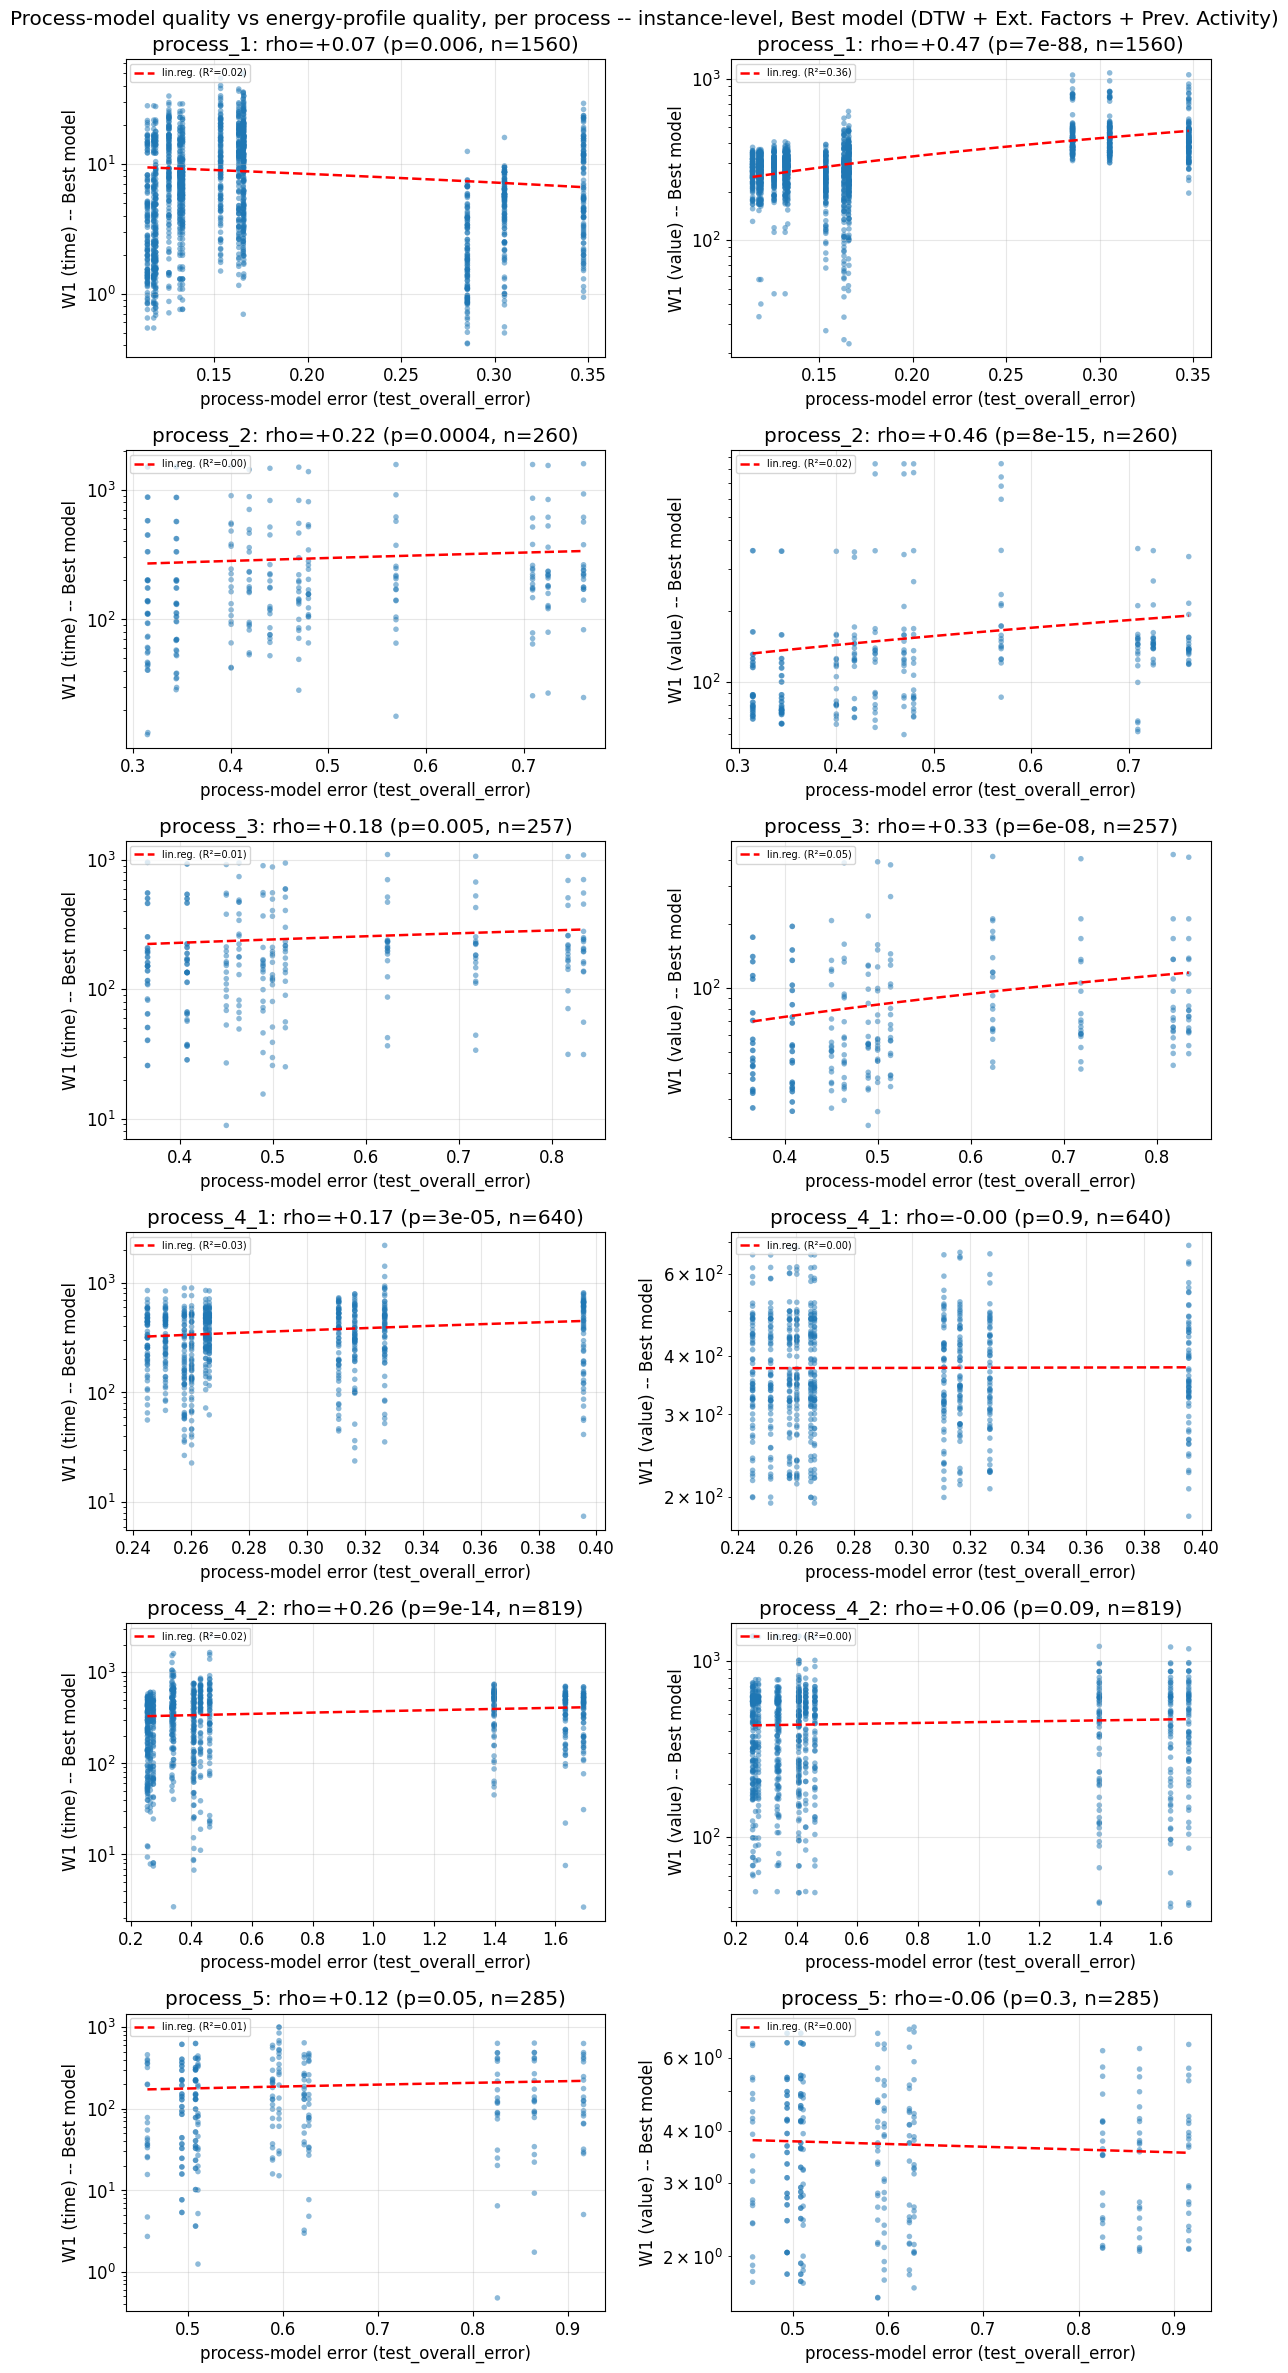

In [41]:
# -- Merge with process-quality (test_overall_error), match safe_mode -> raw mode --
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt
import numpy as np

_pe_inst = pd.read_parquet(run_dir / 'process_eval_results.parquet')
_pe_inst['safe_mode'] = _pe_inst['mode'].astype(str).str.replace(' ', '_').str.replace('/', '_')
_proc_quality_inst = _pe_inst[['process', 'safe_mode', 'test_overall_error']].dropna()

# Sanity check: which process-model algorithms are actually present in this run
# (e.g. is Inductive Miner included, or only Alpha/Heuristic-derived modes?)
_algos_present = sorted({
    m.replace('petri_net_', '').split('_ml_plus_')[0].replace('_wip_aware', '').replace('_wip_branching_aware', '')
    for m in _pe_inst['mode'].unique() if m.startswith('petri_net_') or m == 'statistical'
})
print(f'Process-model variants present in this run: {sorted(_pe_inst["mode"].unique())}')

instance_merged = df_instance_curve.merge(_proc_quality_inst, on=['process', 'safe_mode'], how='inner')
instance_merged = instance_merged.dropna(subset=['test_overall_error', 'wasserstein_time', 'wasserstein_value'])

print(f'{len(instance_merged)} matched (case, mode) rows across {instance_merged["process"].nunique()} processes')

rho_t, p_t = spearmanr(instance_merged['test_overall_error'], instance_merged['wasserstein_time'])
rho_v, p_v = spearmanr(instance_merged['test_overall_error'], instance_merged['wasserstein_value'])
print(f'OVERALL  W1 (time)  vs process error:  rho={rho_t:+.3f}  p={p_t:.4g}  n={len(instance_merged)}')
print(f'OVERALL  W1 (value) vs process error:  rho={rho_v:+.3f}  p={p_v:.4g}  n={len(instance_merged)}')

processes_i = sorted(instance_merged['process'].unique())

# -- One row per process, two columns (W1 time, W1 value), each with its own regression line --
fig, axes = plt.subplots(len(processes_i), 2, figsize=(12, 4 * len(processes_i)), squeeze=False)
for row, proc in enumerate(processes_i):
    sub = instance_merged[instance_merged['process'] == proc]
    for col, (ycol, ylabel) in enumerate([
        ('wasserstein_time',  'W1 (time)'),
        ('wasserstein_value', 'W1 (value)'),
    ]):
        ax = axes[row, col]
        x = sub['test_overall_error'].values
        y = sub[ycol].values
        ax.scatter(x, y, s=16, alpha=0.5, color='tab:blue', edgecolors='none')

        rho_p, p_p = spearmanr(x, y)
        if len(x) >= 2 and np.ptp(x) > 0:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='red', linestyle='--', linewidth=1.8,
                    label=f'lin.reg. (R\u00b2={r_value**2:.2f})')
            ax.legend(fontsize=7, loc='upper left')

        ax.set_yscale('log')
        ax.set_xlabel('process-model error (test_overall_error)')
        ax.set_ylabel(f'{ylabel} -- Best model')
        ax.set_title(f'{proc}: rho={rho_p:+.2f} (p={p_p:.1g}, n={len(sub)})')
        ax.grid(True, alpha=0.3)

fig.suptitle('Process-model quality vs energy-profile quality, per process -- instance-level, Best model (DTW + Ext. Factors + Prev. Activity)',
             y=1.0 - 0.002 * len(processes_i))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'instance_process_vs_energy_correlation_per_process.png', dpi=130, bbox_inches='tight')
plt.show()


# Schedule Profile Evaluation -- Direct Method vs. Proposed (Process-Simulation) Approach

Per process: compares three ways to get from "a case is about to run" to "predicted
complete energy profile", all evaluated against the exact same real test cases:

1. **Schedule-direct** -- a case-level regression straight from schedule-only features
   (recipe/case attributes, start time, external factors), no process simulation at all.
2. **Best, mine** -- the full proposed pipeline: process simulation (best-fidelity mode
   for that process) + DTW + Ext. Factors + Prev. Activity curve prediction.
3. **Stochastic generator** -- a per-position Normal fit with no conditioning at all, the
   floor everything else needs to beat.

Source: `schedule_profile_eval_results/<process>/schedule_profile_eval_summary.csv`
(requires `run_schedule_profile_eval: True` and `run_energy_modelling: True` in
`pipeline.py`). The raw `*_wasserstein_time` (minutes) / `*_wasserstein_value` (raw
sensor units) columns aren't comparable across sensors of different units, so -- same
standardization as the Complete-Curve section above -- each is divided by a real,
model-independent scale reference before aggregating:

- `W1 (time), rel.` = `*_wasserstein_time` / real median case duration for that process.
- `W1 (value), rel.` = `*_wasserstein_value` / real per-case-mean median for that sensor.
- `Combined` = both standardized metrics pooled together, one median -- valid only
  because both are already unitless.


In [42]:
# -- Standardize + aggregate the Schedule Profile Evaluation, per process --
# Per-case normalization: each case is normalized by its OWN real curve's
# scale (own real duration for time; own real mean/std -- z-score -- for
# value) BEFORE computing the Wasserstein distance, mirroring the per-
# instance sMAE normalization used in the individual energy-profile
# evaluation (evaluate_pipeline_on_test). This replaces the earlier version,
# which divided an aggregated (already medianed) raw W1 by one global
# process-wide / sensor-wide reference constant -- that's mathematically
# identical to normalizing-then-aggregating ONLY when every case shares the
# same reference value, which isn't true here: real case durations and real
# per-case magnitudes vary quite a bit. A single global constant lets cases
# with an unusually long/short real duration (or an unusually flat/active
# real curve) get over- or under-penalized purely because of their own
# scale, not prediction quality.
#
# Degenerate cases are excluded case-by-case (NaN) rather than blowing up the
# ratio -- mirroring the `_cv_ok` guard used for sMAE:
#   - time:  skip if this case's own real duration is ~0
#   - value: skip if this case's own real curve is ~constant (std ~0, or
#            coefficient of variation <= 1%) -- z-scoring a flat signal turns
#            noise-level wiggles into huge, meaningless z-scores.
_sp_series = {
    'Schedule-direct':          'schedule',
    'Best, mine':               'best',
    'Best, duration-corrected': 'best_duration_corrected',
    'Stochastic generator':     'stochastic',
}

def _load_schedule_profile_cases(proc):
    from scipy.stats import wasserstein_distance
    """Returns a long DataFrame [process, sensor, method, case_id, w1_time_rel,
    w1_value_rel] -- one row per individual case instance, no aggregation at
    all -- for one process, or an empty DataFrame if the data isn't available."""
    curves_path = run_dir / 'schedule_profile_eval_results' / proc / 'predicted_curves.parquet'
    if not curves_path.exists():
        return pd.DataFrame()
    df_curves = pd.read_parquet(curves_path)

    case_rows = []
    for sensor, sensor_g in df_curves.groupby('sensor'):
        real_by_case = {cid: g.sort_values('t_minutes')
                         for cid, g in sensor_g[sensor_g['series'] == 'real'].groupby('case_id')}
        for method, series_name in _sp_series.items():
            pred_by_case = {cid: g.sort_values('t_minutes')
                             for cid, g in sensor_g[sensor_g['series'] == series_name].groupby('case_id')}
            for case_id, real_g in real_by_case.items():
                pred_g = pred_by_case.get(case_id)
                if pred_g is None or pred_g.empty:
                    continue
                t_real = real_g['t_minutes'].to_numpy()
                v_real = real_g['value'].to_numpy()
                t_pred = pred_g['t_minutes'].to_numpy()
                v_pred = pred_g['value'].to_numpy()

                w_real = np.clip(v_real, 0, None)
                w_pred = np.clip(v_pred, 0, None)
                if w_real.sum() <= 0 or w_pred.sum() <= 0:
                    continue

                # -- Time: normalize by this case's own real duration --
                duration_real = float(t_real.max())
                t_rel = float('nan')
                if duration_real > 1e-6:
                    t_rel = float(wasserstein_distance(
                        t_real / duration_real, t_pred / duration_real,
                        u_weights=w_real, v_weights=w_pred))

                # -- Value: z-score by this case's own real mean/std --
                mu_real, sig_real = float(v_real.mean()), float(v_real.std())
                _cv_ok = sig_real > 1e-10 and (mu_real == 0 or (sig_real / abs(mu_real)) > 0.01)
                v_rel = float('nan')
                if _cv_ok:
                    z_real = (v_real - mu_real) / sig_real
                    z_pred = (v_pred - mu_real) / sig_real
                    v_rel = float(wasserstein_distance(z_real, z_pred))

                case_rows.append({'process': proc, 'sensor': sensor, 'method': method,
                                  'case_id': case_id, 'w1_time_rel': t_rel, 'w1_value_rel': v_rel})

    return pd.DataFrame(case_rows)


def _load_schedule_profile_relative(proc):
    """Returns a long DataFrame [process, sensor, method, w1_time_rel, w1_value_rel]
    for one process, or an empty DataFrame if the data isn't available. Median
    across cases, per (process, sensor, method) -- NaN (degenerate/excluded)
    cases are dropped automatically by .median()."""
    df_cases = _load_schedule_profile_cases(proc)
    if df_cases.empty:
        return pd.DataFrame()
    return df_cases.groupby(['process', 'sensor', 'method']).agg(
        w1_time_rel=('w1_time_rel', 'median'),
        w1_value_rel=('w1_value_rel', 'median'),
    ).reset_index()


def _bold_best_per_column(agg):
    str_table = agg.round(3).astype(object)
    for col in agg.columns:
        vals = agg[col].dropna()
        if vals.empty:
            continue
        best_val = vals.min()
        for idx in agg.index:
            val = agg.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt
    return str_table


_sp_all_processes = [
    p for p in sorted({d.name for d in (run_dir / 'schedule_profile_eval_results').iterdir()})
] if (run_dir / 'schedule_profile_eval_results').exists() else []
print(f'Processes with Schedule Profile Evaluation data: {_sp_all_processes}')

df_sp_relative_all = pd.concat(
    [_load_schedule_profile_relative(p) for p in _sp_all_processes], ignore_index=True
) if _sp_all_processes else pd.DataFrame()

# Fair comparison: only keep (process, sensor) pairs where ALL methods produced a
# valid (non-NaN) w1_time_rel and w1_value_rel. Otherwise a method that's missing a
# sensor entirely (e.g. no trained pipeline for it) gets a smaller, easier pool of
# sensors than the others, which silently biases its median up or down.
if not df_sp_relative_all.empty:
    _n_methods_expected = len(_sp_series)
    _complete_counts = (
        df_sp_relative_all.dropna(subset=['w1_time_rel', 'w1_value_rel'])
        .groupby(['process', 'sensor']).size()
    )
    _complete_keys = set(_complete_counts[_complete_counts == _n_methods_expected].index)
    _all_keys = set(zip(df_sp_relative_all['process'], df_sp_relative_all['sensor']))
    _dropped_keys = sorted(_all_keys - _complete_keys)
    if _dropped_keys:
        print(f'[Schedule Profile Eval] Dropping {len(_dropped_keys)} (process, sensor) pair(s) '
              f'lacking data for all {_n_methods_expected} methods, so every method is aggregated '
              f'over the same sensors:')
        for _proc_k, _sensor_k in _dropped_keys:
            print(f'    {_proc_k} / {_sensor_k}')
    df_sp_relative_all = df_sp_relative_all[
        df_sp_relative_all.set_index(['process', 'sensor']).index.isin(_complete_keys)
    ].reset_index(drop=True)

# Raw, case-level rows (no per-sensor or per-process aggregation at all),
# restricted to the same fair (process, sensor) set as above -- feeds the
# single flat median table below.
df_sp_cases_all = pd.concat(
    [_load_schedule_profile_cases(p) for p in _sp_all_processes], ignore_index=True
) if _sp_all_processes else pd.DataFrame()
if not df_sp_cases_all.empty:
    df_sp_cases_all = df_sp_cases_all[
        df_sp_cases_all.set_index(['process', 'sensor']).index.isin(_complete_keys)
    ].reset_index(drop=True)

for proc in _sp_all_processes:
    sub = df_sp_relative_all[df_sp_relative_all['process'] == proc]
    if sub.empty:
        print(f'{proc}: no data, skipping.')
        continue

    agg = sub.groupby('method').agg(
        **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
           'W1 (value), rel. median': ('w1_value_rel', 'median')}
    )
    pooled = pd.concat([
        sub[['method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
        sub[['method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
    ], ignore_index=True)
    agg['Combined, rel. median'] = pooled.groupby('method')['v'].median()
    agg = agg.sort_values('Combined, rel. median')

    str_table = _bold_best_per_column(agg)
    latex = str_table.to_latex(
        escape=False, column_format='l|c|c|c',
        caption=(
            f'Aggregated Schedule Profile Evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'One standardized (scale-free) number per method, median over sensors '
            r'(Combined: median over sensors and both metrics pooled together). '
            r'Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_{EXPERIMENT}_{SPLIT}_{proc}',
        position='H',
    )
    print(f'% === {proc} ===')
    print(latex.replace('_', r'\_'))
    display(agg.round(3))
    print()


Processes with Schedule Profile Evaluation data: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']


[Schedule Profile Eval] Dropping 1 (process, sensor) pair(s) lacking data for all 4 methods, so every method is aggregated over the same sensors:
    process_1 / water_supply_power_kW_energy_to_model
% === process_1 ===
\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation for process\_1, experiment 929 (test evaluation). One standardized (scale-free) number per method, median over sensors (Combined: median over sensors and both metrics pooled together). Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_929\_test\_process\_1}
\begin{tabular}{l|c|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median & Combined, rel. median \\
method &  &  &  \\
\midrule
Schedule-direct & 0.107 & \textbf{0.150} & \textbf{0.126} \\
Best, mine & \textbf{0.030} & 0.258 & 0.133 \\
Best, duration-corrected & 0.097 & 0.258 & 0.159 \\
Stochastic generator & 0.123 & 0.241 & 0.177 \\
\bottomrule
\end{tabular}


,"W1 (time), rel. median","W1 (value), rel. median","Combined, rel. median"
method,,,
Schedule-direct,0.107,0.150,0.126
"Best, mine",0.030,0.258,0.133
"Best, duration-corrected",0.097,0.258,0.159
Stochastic generator,0.123,0.241,0.177



% === process_2 ===
\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation for process\_2, experiment 929 (test evaluation). One standardized (scale-free) number per method, median over sensors (Combined: median over sensors and both metrics pooled together). Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_929\_test\_process\_2}
\begin{tabular}{l|c|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median & Combined, rel. median \\
method &  &  &  \\
\midrule
Schedule-direct & \textbf{0.163} & 0.291 & \textbf{0.215} \\
Stochastic generator & 0.167 & 0.373 & 0.251 \\
Best, mine & 0.253 & \textbf{0.167} & 0.252 \\
Best, duration-corrected & 0.293 & \textbf{0.167} & 0.289 \\
\bottomrule
\end{tabular}
\end{table}



,"W1 (time), rel. median","W1 (value), rel. median","Combined, rel. median"
method,,,
Schedule-direct,0.163,0.291,0.215
Stochastic generator,0.167,0.373,0.251
"Best, mine",0.253,0.167,0.252
"Best, duration-corrected",0.293,0.167,0.289


...

,"W1 (time), rel. median","W1 (value), rel. median","Combined, rel. median"
method,,,
Stochastic generator,0.074,1.276,0.317
"Best, duration-corrected",0.031,1.081,0.414
Schedule-direct,0.074,1.326,0.427
"Best, mine",0.291,1.081,0.479



% === process_4_2 ===
\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation for process\_4\_2, experiment 929 (test evaluation). One standardized (scale-free) number per method, median over sensors (Combined: median over sensors and both metrics pooled together). Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_929\_test\_process\_4\_2}
\begin{tabular}{l|c|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median & Combined, rel. median \\
method &  &  &  \\
\midrule
Stochastic generator & 0.027 & 2.910 & \textbf{0.261} \\
Schedule-direct & 0.027 & \textbf{2.648} & 0.409 \\
Best, duration-corrected & \textbf{0.018} & 2.861 & 0.430 \\
Best, mine & 0.210 & 2.861 & 0.452 \\
\bottomrule
\end{tabular}
\end{table}



,"W1 (time), rel. median","W1 (value), rel. median","Combined, rel. median"
method,,,
Stochastic generator,0.027,2.910,0.261
Schedule-direct,0.027,2.648,0.409
"Best, duration-corrected",0.018,2.861,0.430
"Best, mine",0.210,2.861,0.452



% === process_5 ===
\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation for process\_5, experiment 929 (test evaluation). One standardized (scale-free) number per method, median over sensors (Combined: median over sensors and both metrics pooled together). Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_929\_test\_process\_5}
\begin{tabular}{l|c|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median & Combined, rel. median \\
method &  &  &  \\
\midrule
Best, duration-corrected & \textbf{0.080} & \textbf{1.803} & \textbf{0.371} \\
Best, mine & 0.173 & \textbf{1.803} & 0.380 \\
Stochastic generator & 0.309 & 3.061 & 0.450 \\
Schedule-direct & 0.309 & 2.380 & 0.504 \\
\bottomrule
\end{tabular}
\end{table}



,"W1 (time), rel. median","W1 (value), rel. median","Combined, rel. median"
method,,,
"Best, duration-corrected",0.080,1.803,0.371
"Best, mine",0.173,1.803,0.380
Stochastic generator,0.309,3.061,0.450
Schedule-direct,0.309,2.380,0.504


## Coper

In [43]:
# -- Aggregated across all processes: one row per method, one column per process + Overall --
if df_sp_relative_all.empty:
    print('Nothing to show -- df_sp_relative_all is empty.')
else:
    _pooled_all = pd.concat([
        df_sp_relative_all[['process', 'method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
        df_sp_relative_all[['process', 'method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
    ], ignore_index=True)

    _rank_agg = _pooled_all.groupby(['process', 'method'])['v'].median().reset_index()
    _rank_pivot = _rank_agg.pivot(index='method', columns='process', values='v')
    _rank_pivot['Overall'] = _rank_pivot.median(axis=1)
    _rank_pivot = _rank_pivot.sort_values('Overall')

    _str_table = _bold_best_per_column(_rank_pivot)
    n_cols = len(_rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    _rank_latex = _str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated Schedule Profile Evaluation across all processes, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Each case normalized by its own real curve scale (own duration for time, own mean/std for value); '
            r'both standardized metrics (W1 time, W1 value) pooled per process, then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_overall_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_rank_latex.replace('_', r'\_'))
    display(_rank_pivot.round(3))

\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation across all processes, experiment 929 (test evaluation). Each case normalized by its own real curve scale (own duration for time, own mean/std for value); both standardized metrics (W1 time, W1 value) pooled per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_overall\_929\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
method &  &  &  &  &  &  &  \\
\midrule
Stochastic generator & 0.177 & 0.251 & 0.281 & \textbf{0.317} & \textbf{0.261} & 0.450 & \textbf{0.271} \\
Schedule-direct & \textbf{0.126} & \textbf{0.215} & \textbf{0.198} & 0.427 & 0.409 & 0.504 & 0.312 \\
Best, duration-corrected & 0.159 & 0.289 & 0.217 & 0.414 & 0.430 & \textbf{0.371} & 0.330 \\
Best, mine & 0.133 & 0.252 & 0.288 

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
method,,,,,,,
Stochastic generator,0.177,0.251,0.281,0.317,0.261,0.450,0.271
Schedule-direct,0.126,0.215,0.198,0.427,0.409,0.504,0.312
"Best, duration-corrected",0.159,0.289,0.217,0.414,0.430,0.371,0.330
"Best, mine",0.133,0.252,0.288,0.479,0.452,0.380,0.334


## Aggregated across all processes

Same three methods, one row each, now rolled up across every process: median over
sensors within a process (as above), then median over processes for `Overall`. Rows
sorted best-to-worst by `Overall`.


In [44]:
# -- Aggregated across all processes: one row per method, one column per process + Overall --
if df_sp_relative_all.empty:
    print('Nothing to show -- df_sp_relative_all is empty.')
else:
    _pooled_all = pd.concat([
        df_sp_relative_all[['process', 'method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
        df_sp_relative_all[['process', 'method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
    ], ignore_index=True)

    _rank_agg = _pooled_all.groupby(['process', 'method'])['v'].median().reset_index()
    _rank_pivot = _rank_agg.pivot(index='method', columns='process', values='v')
    _rank_pivot['Overall'] = _rank_pivot.median(axis=1)
    _rank_pivot = _rank_pivot.sort_values('Overall')

    _str_table = _bold_best_per_column(_rank_pivot)
    n_cols = len(_rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    _rank_latex = _str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated Schedule Profile Evaluation across all processes, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Each case normalized by its own real curve scale (own duration for time, own mean/std for value); '
            r'both standardized metrics (W1 time, W1 value) pooled per process, then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_overall_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_rank_latex.replace('_', r'\_'))
    display(_rank_pivot.round(3))


\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation across all processes, experiment 929 (test evaluation). Each case normalized by its own real curve scale (own duration for time, own mean/std for value); both standardized metrics (W1 time, W1 value) pooled per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_overall\_929\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
method &  &  &  &  &  &  &  \\
\midrule
Stochastic generator & 0.177 & 0.251 & 0.281 & \textbf{0.317} & \textbf{0.261} & 0.450 & \textbf{0.271} \\
Schedule-direct & \textbf{0.126} & \textbf{0.215} & \textbf{0.198} & 0.427 & 0.409 & 0.504 & 0.312 \\
Best, duration-corrected & 0.159 & 0.289 & 0.217 & 0.414 & 0.430 & \textbf{0.371} & 0.330 \\
Best, mine & 0.133 & 0.252 & 0.288 

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
method,,,,,,,
Stochastic generator,0.177,0.251,0.281,0.317,0.261,0.450,0.271
Schedule-direct,0.126,0.215,0.198,0.427,0.409,0.504,0.312
"Best, duration-corrected",0.159,0.289,0.217,0.414,0.430,0.371,0.330
"Best, mine",0.133,0.252,0.288,0.479,0.452,0.380,0.334


### Aggregated across all processes -- both W1 metrics kept separate

Same idea as the table above, but instead of pooling W1 (time) and W1 (value) into one 'Combined'/'Overall' number, this keeps them as two separate columns: the median of `w1_time_rel` and the median of `w1_value_rel`, each taken over every (process, sensor) pair (using the same common-sensor filtering as above, so all methods are compared over the same sensors).

In [45]:
# -- Aggregated across all processes: both W1 metrics as separate columns (no pooling) --
if df_sp_relative_all.empty:
    print('Nothing to show -- df_sp_relative_all is empty.')
else:
    _both_agg = df_sp_relative_all.groupby('method').agg(
        **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
           'W1 (value), rel. median': ('w1_value_rel', 'median')}
    )
    _both_agg = _both_agg.sort_values('W1 (time), rel. median')

    _both_str = _bold_best_per_column(_both_agg)
    _both_latex = _both_str.to_latex(
        escape=False, column_format='l|c|c',
        caption=(
            f'Aggregated Schedule Profile Evaluation across all processes, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Each case normalized by its own real curve scale (own duration for time, own mean/std for value). '
            r'W1 (time) and W1 (value), rel. -- each column is the median over every (process, sensor) pair, kept separate '
            r'(not pooled into a single score). Lower is better. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_both_w1_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_both_latex.replace('_', r'\_'))
    display(_both_agg.round(3))

\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation across all processes, experiment 929 (test evaluation). Each case normalized by its own real curve scale (own duration for time, own mean/std for value). W1 (time) and W1 (value), rel. -- each column is the median over every (process, sensor) pair, kept separate (not pooled into a single score). Lower is better. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_both\_w1\_929\_test}
\begin{tabular}{l|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median \\
method &  &  \\
\midrule
Best, duration-corrected & \textbf{0.077} & 1.368 \\
Schedule-direct & 0.150 & \textbf{1.359} \\
Stochastic generator & 0.163 & 1.869 \\
Best, mine & 0.211 & 1.368 \\
\bottomrule
\end{tabular}
\end{table}



,"W1 (time), rel. median","W1 (value), rel. median"
method,,
"Best, duration-corrected",0.077,1.368
Schedule-direct,0.150,1.359
Stochastic generator,0.163,1.869
"Best, mine",0.211,1.368


### Single flat median -- every case, every sensor, every process pooled together

No per-sensor or per-process grouping at all: every individual case instance (across all 6 processes and all their sensors) is thrown into one pool per method, and a single median is taken directly -- unlike the tables above, which take a median-of-medians (cases -> sensors -> processes, each level weighted equally regardless of how many cases/sensors it contains). Here, a process/sensor with more test cases contributes proportionally more to the result.

In [46]:
# -- Single flat median: pool every (process, sensor, case) instance together, no grouping --
if df_sp_cases_all.empty:
    print('Nothing to show -- df_sp_cases_all is empty.')
else:
    _flat = df_sp_cases_all.groupby('method').agg(
        **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
           'W1 (value), rel. median': ('w1_value_rel', 'median'),
           'n_time': ('w1_time_rel', 'count'),
           'n_value': ('w1_value_rel', 'count')}
    )
    _flat_pooled = pd.concat([
        df_sp_cases_all[['method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
        df_sp_cases_all[['method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
    ], ignore_index=True)
    _flat['Combined, rel. median'] = _flat_pooled.groupby('method')['v'].median()
    _flat = _flat.sort_values('Combined, rel. median')

    _flat_display = _flat[['W1 (time), rel. median', 'W1 (value), rel. median', 'Combined, rel. median']]
    _flat_str = _bold_best_per_column(_flat_display)
    _flat_latex = _flat_str.to_latex(
        escape=False, column_format='l|c|c|c',
        caption=(
            f'Schedule Profile Evaluation, experiment {EXPERIMENT} ({SPLIT} evaluation), pooled flat across '
            r'every case instance from every sensor and every process (no per-sensor or per-process '
            r'grouping). Each case normalized by its own real curve scale (own duration for time, own '
            r'mean/std for value). Lower is better. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_flat_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_flat_latex.replace('_', r'\_'))
    display(_flat.round(3))

\begin{table}[H]
\caption{Schedule Profile Evaluation, experiment 929 (test evaluation), pooled flat across every case instance from every sensor and every process (no per-sensor or per-process grouping). Each case normalized by its own real curve scale (own duration for time, own mean/std for value). Lower is better. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_flat\_929\_test}
\begin{tabular}{l|c|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median & Combined, rel. median \\
method &  &  &  \\
\midrule
Best, duration-corrected & \textbf{0.050} & 1.162 & \textbf{0.204} \\
Schedule-direct & 0.085 & \textbf{1.080} & 0.284 \\
Stochastic generator & 0.098 & 1.257 & 0.311 \\
Best, mine & 0.211 & 1.162 & 0.372 \\
\bottomrule
\end{tabular}
\end{table}



,"W1 (time), rel. median","W1 (value), rel. median",n_time,n_value,"Combined, rel. median"
method,,,,,
"Best, duration-corrected",0.050,1.162,4349,3730,0.204
Schedule-direct,0.085,1.080,4341,3723,0.284
Stochastic generator,0.098,1.257,4349,3730,0.311
"Best, mine",0.211,1.162,4349,3730,0.372
